![KU Leuven Logo](https://www.kuleuven.be/iportfolio/images/logos/kuleuven.png/@@images/image-800-e89431243530c6a800aa1186b9f6891b.png)
<br>
# KUL H02A5a Computer Vision: Group Assignment 2
**Team 27** | **Fosteris Emmanouil · Paschalidis Marios · Greiner Luc · Reyes Salazar Jose · Digenis Stefanos**

---

## Section 0 — Setup & Data

In [1]:
import os, copy, random, shutil
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import math
from tqdm import tqdm
import gc
import cv2
from tqdm import tqdm
from collections import Counter

In [2]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import v2
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

In [3]:
!pip install iterative-stratification open-clip-torch segmentation-models-pytorch transformers ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.2 MB/s eta 0:00:00


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score
from sklearn.metrics import f1_score, precision_score, recall_score
import albumentations as A
from albumentations.pytorch import ToTensorV2
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

In [5]:
import open_clip
import segmentation_models_pytorch as smp
from transformers import Mask2FormerConfig, Mask2FormerForUniversalSegmentation, Mask2FormerImageProcessor
from transformers import Mask2FormerImageProcessor as _M2FProc

In [6]:
from google.colab import drive, userdata
drive.mount('/content/drive')
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

Mounted at /content/drive


In [7]:
# ── Reproducibility ──────────────────────────────────────────────────────
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed()
DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD  = [0.229, 0.224, 0.225]
print(f"Device: {DEVICE}")

Device: cuda


In [8]:
!cp "/content/drive/MyDrive/Colab_Notebooks/KU_Leuven/CV/dataset.zip" "/content/dataset.zip"
!unzip -q "/content/dataset.zip" -d "/content/local_data/"
DATA_PATH = '/content/local_data/'
SAVE_DIR = "/content/drive/MyDrive/Colab_Notebooks/KU_Leuven/CV/"

In [9]:
# DATA_PATH = '/kaggle/input/competitions/kul-computer-vision-ga-2-2026/'
# SAVE_DIR = '/kaggle/working/'

In [10]:
# ── Load data ────────────────────────────────────────────────────────────
train_df = pd.read_csv(DATA_PATH + 'train/train_set.csv', index_col="Id")
labels   = train_df.columns
train_df["img"] = [np.load(DATA_PATH + f'train/img/train_{idx}.npy') for idx, _ in train_df.iterrows()]
train_df["seg"] = [np.load(DATA_PATH + f'train/seg/train_{idx}.npy') for idx, _ in train_df.iterrows()]
print(f"Training set: {len(train_df)} examples")

test_df = pd.read_csv(DATA_PATH + 'test/test_set.csv', index_col="Id")
test_df["img"] = [np.load(DATA_PATH + f'test/img/test_{idx}.npy') for idx, _ in test_df.iterrows()]
test_df["seg"] = [-1 * np.ones(img.shape[:2], dtype=np.int8) for img in test_df["img"]]
print(f"Test set: {len(test_df)} examples")

VOC_CLASSES = [
    "background","aeroplane","bicycle","bird","boat","bottle",
    "bus","car","cat","chair","cow","diningtable","dog","horse",
    "motorbike","person","pottedplant","sheep","sofa","train","tvmonitor",
]
NUM_CLASSES = 21

Training set: 749 examples
Test set: 750 examples


### Section 0.1 — Exploratory Data Analysis

Before making any modelling decisions we need to understand the structure of
the data. The EDA is split into two parts — **classification** and
**segmentation** — because the two tasks have different failure modes and
different design levers (loss functions, augmentation, backbone choice, etc.).

Each cell below answers one specific question and ends with a **concrete
modelling consequence**. Reading the cells in order builds a chain of
justified decisions that connects raw dataset statistics to the final
architecture choices.

---
### 0.1-A — Classification EDA

#### Image size & aspect ratio distribution
We wanted to check the image size and aspect ratio distributions for understanding how to best design our augmentation strategy and ViT patch grids. Since naive squashing (e.g., Resize(224, 224)) distorts features on varying aspect ratios, knowing this distribution helps us decide whether to use RandomResizedCrop instead, and sets the resolution upper bounds for our downstream models (DINOv2 at 504px, Mask2Former at 384px, CLIP at 224px).

Training: 749 | Test: 750
Height: min=112  max=500  mean=383.1
Width : min=257   max=500   mean=471.8
Aspect: min=0.61  max=4.46  mean=1.28


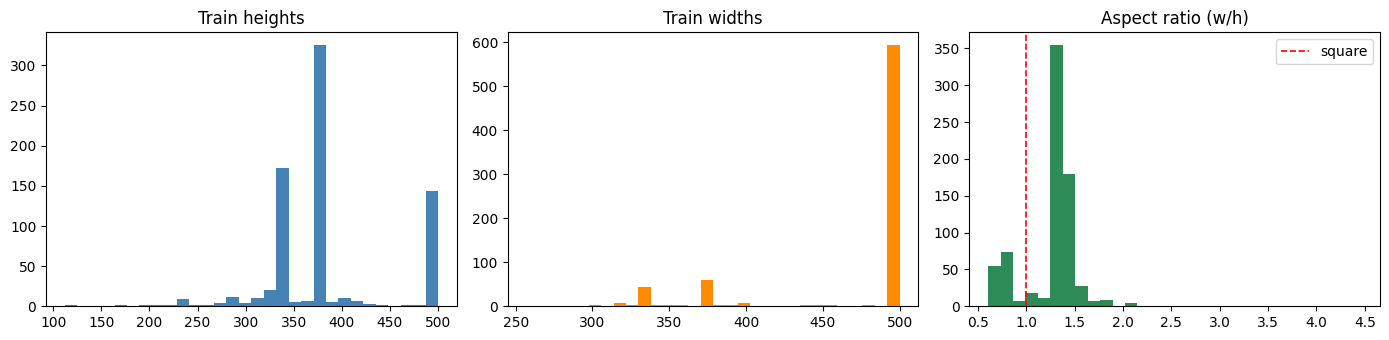

Landscape: 603 | Portrait: 139


In [11]:
# ─── Image-size statistics (train + test) ──────────────────────────
heights = [img.shape[0] for img in train_df["img"]]
widths  = [img.shape[1] for img in train_df["img"]]
aspects = [w / h for h, w in zip(heights, widths)]

print(f"Training: {len(train_df)} | Test: {len(test_df)}")
print(f"Height: min={min(heights)}  max={max(heights)}  mean={np.mean(heights):.1f}")
print(f"Width : min={min(widths)}   max={max(widths)}   mean={np.mean(widths):.1f}")
print(f"Aspect: min={min(aspects):.2f}  max={max(aspects):.2f}  mean={np.mean(aspects):.2f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].hist(heights, bins=30, color="steelblue");  axes[0].set_title("Train heights")
axes[1].hist(widths,  bins=30, color="darkorange"); axes[1].set_title("Train widths")
axes[2].hist(aspects, bins=30, color="seagreen");   axes[2].set_title("Aspect ratio (w/h)")
axes[2].axvline(1.0, color="red", lw=1.2, ls="--", label="square")
axes[2].legend(); plt.tight_layout(); plt.show()
print(f"Landscape: {sum(1 for a in aspects if a>1)} | Portrait: {sum(1 for a in aspects if a<1)}")

#### Per-class label frequency

We wanted to check the per-class label frequencies for understanding our train/val splitting strategy and loss function requirements. If rare classes exist, a naive random split could leave the validation set with zero positive examples for a given class, making MultilabelStratifiedKFold mandatory. Furthermore, if the frequency gap between the most and least common classes exceeds 5×, standard BCE will suppress the rare classes, indicating that we must use a compensating loss function like Asymmetric Loss (ASL) or class-weighted BCE.

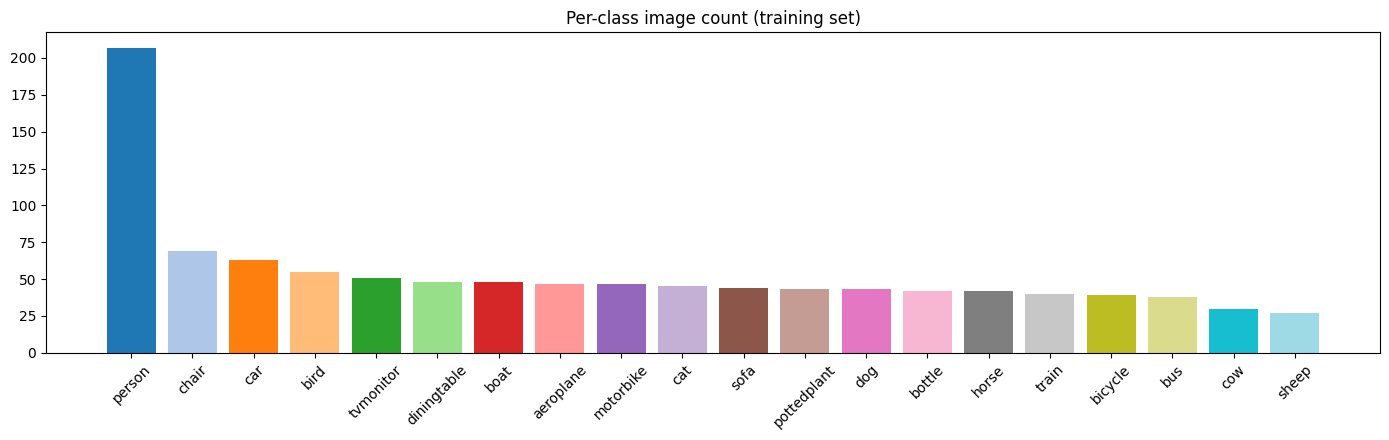

  person           207  (27.6%)
  chair             69  (9.2%)
  car               63  (8.4%)
  bird              55  (7.3%)
  tvmonitor         51  (6.8%)
  diningtable       48  (6.4%)
  boat              48  (6.4%)
  aeroplane         47  (6.3%)
  motorbike         47  (6.3%)
  cat               45  (6.0%)
  sofa              44  (5.9%)
  pottedplant       43  (5.7%)
  dog               43  (5.7%)
  bottle            42  (5.6%)
  horse             42  (5.6%)
  train             40  (5.3%)
  bicycle           39  (5.2%)
  bus               38  (5.1%)
  cow               30  (4.0%)
  sheep             27  (3.6%)


In [12]:
# ─── Per-class label frequency ──────────────────────────────────────
label_counts = train_df[labels].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(14, 4.5))
ax.bar(label_counts.index, label_counts.values,
       color=[plt.cm.tab20(i/len(labels)) for i in range(len(labels))])
ax.set_title("Per-class image count (training set)"); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()
for cls, cnt in label_counts.items():
    print(f"  {cls:<15} {int(cnt):4d}  ({100*cnt/len(train_df):.1f}%)")

#### Label cardinality and positive/negative imbalance

We wanted to check the label cardinality and overall positive-to-negative imbalance for understanding our optimal loss function design and thresholding strategy. In multi-label tasks, a very low positive rate (e.g., < 10%) overwhelms standard BCEWithLogitsLoss with negative signals, making Asymmetric Loss (ASL) mandatory to down-weight easy negatives. Furthermore, this heavy imbalance systematically biases sigmoid outputs toward zero, confirming that a default 0.5 cutoff will fail and per-class threshold tuning on the validation set is necessary.

In [13]:
# ─── 0.1.3 Label cardinality + positive/negative imbalance ───────────────
labels_per_image = train_df[labels].sum(axis=1)
print("Label cardinality:"); print(labels_per_image.describe())
total_pairs = len(train_df) * len(labels)
pos_pairs   = int(train_df[labels].values.sum())
print(f"\nPositive/Negative ratio: 1 : {(total_pairs-pos_pairs)/pos_pairs:.1f}")
print("→ ~93-95% negative pairs: use ASL (Asymmetric Loss) to down-weight easy negatives")

Label cardinality:
count    749.000000
mean       1.425901
std        0.683199
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        5.000000
dtype: float64

Positive/Negative ratio: 1 : 13.0
→ ~93-95% negative pairs: use ASL (Asymmetric Loss) to down-weight easy negatives


#### Pixel intensity distribution vs. ImageNet normalisation

We wanted to check the pixel intensity distribution for understanding if standard ImageNet normalization is valid for our pretrained backbones. Since models like DINOv2 and CLIP expect ImageNet mean and std, a large statistical deviation (e.g., |Δ mean| > 0.05 per channel) would impair feature transfer, dictating that we compute and use dataset-specific statistics in our A.Normalize pipeline instead of the defaults.

In [14]:
# ─── Pixel intensity vs ImageNet stats ──────────────────────────────
SAMPLE = min(200, len(train_df))
rng    = np.random.default_rng(SEED)
idxs   = rng.choice(len(train_df), SAMPLE, replace=False)
means  = np.stack([train_df.iloc[i]["img"].astype(np.float32).reshape(-1,3).mean(0)/255 for i in idxs])
dataset_mean = means.mean(0); dataset_std = means.std(0)
print(f"VOC mean: R={dataset_mean[0]:.4f} G={dataset_mean[1]:.4f} B={dataset_mean[2]:.4f}")
print(f"ImageNet: R={IMG_MEAN[0]:.4f}     G={IMG_MEAN[1]:.4f}     B={IMG_MEAN[2]:.4f}")
print(f"|Δ mean| max: {np.abs(dataset_mean - np.array(IMG_MEAN)).max():.4f}")
print("→ VOC ≈ ImageNet stats — use ImageNet normalisation (no dataset-specific stats needed)")

VOC mean: R=0.4611 G=0.4536 B=0.4191
ImageNet: R=0.4850     G=0.4560     B=0.4060
|Δ mean| max: 0.0239
→ VOC ≈ ImageNet stats — use ImageNet normalisation (no dataset-specific stats needed)


#### Stratified split sanity check

We wanted to check the per-class frequency preservation in our stratified k-fold split for understanding the validity of our validation metrics, threshold tuning, and reproducibility. If the validation distribution diverges from training, per-class thresholds will not generalize, and missing positive examples will render the mAP early-stopping signal misleading. Fixing a random seed ensures fair comparisons across experiments, while verifying that the maximum frequency drift remains below 0.05 confirms our split is valid (otherwise, we must increase the fold count or validation fraction to stabilize rare classes).

In [15]:
# ─── 0.1.5 Stratified split sanity check ──────────────────────────────────
mskf  = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
y_all = train_df[labels].values.astype(int)
splits = list(mskf.split(np.zeros(len(y_all)), y_all))
tr_idx, va_idx = splits[0]
tr_sub, va_sub = train_df.iloc[tr_idx], train_df.iloc[va_idx]
print(f"Train: {len(tr_sub)} | Val: {len(va_sub)} ({len(va_sub)/len(train_df)*100:.1f}%)")
diff = (tr_sub[labels].mean() - va_sub[labels].mean()).abs()
print(f"Max per-class frequency drift: {diff.max():.4f} (good < 0.05)")

Train: 607 | Val: 142 (19.0%)
Max per-class frequency drift: 0.0239 (good < 0.05)


### 0.1-B — Segmentation EDA

Semantic segmentation has fundamentally different failure modes from
classification. The target is a dense pixel-level class map, so the
relevant statistics are at the **pixel level**, not the image level.

A class that appears in many images but occupies only 0.3% of all pixels
will be systematically under-segmented even if classification EDA shows it
is reasonably frequent at the image level — because the model never sees
enough positive pixels to learn the class boundary.

The five cells below characterise the dataset at the pixel level and drive
decisions about loss functions, augmentation strategy, model architecture,
and post-processing.

#### Pixel-level class frequency and class weights

We wanted to check the pixel-level class frequencies and background dominance for understanding our segmentation loss design. Because background pixels overwhelmingly dominate the gradient, standard cross-entropy will trivially predict background everywhere. To fix this, we must compute a class_weights_tensor using median-frequency class weighting ($w_c = \frac{f_{median}}{f_c}$) to amplify rare classes in our weighted Cross-Entropy loss ($\mathcal{L}_{CE} = - \sum w_c y_c \log(p_c)$). Furthermore, if the background exceeds 50%, combining this with Dice loss <br>
$\mathcal{L}_{Dice} = 1 - \frac{2 \sum y_i p_i}{\sum y_i + \sum p_i}$ <br> becomes mandatory to directly optimize mask overlap regardless of absolute pixel area. Extreme imbalance may even warrant Tversky loss  <br> $\mathcal{L}_{Tversky} = 1 - \frac{\sum y_i p_i}{\sum y_i p_i + \alpha \sum y_i (1-p_i) + \beta \sum (1-y_i) p_i}$ <br> using $\beta > 0.5$ to heavily penalize false negatives for rare classes.

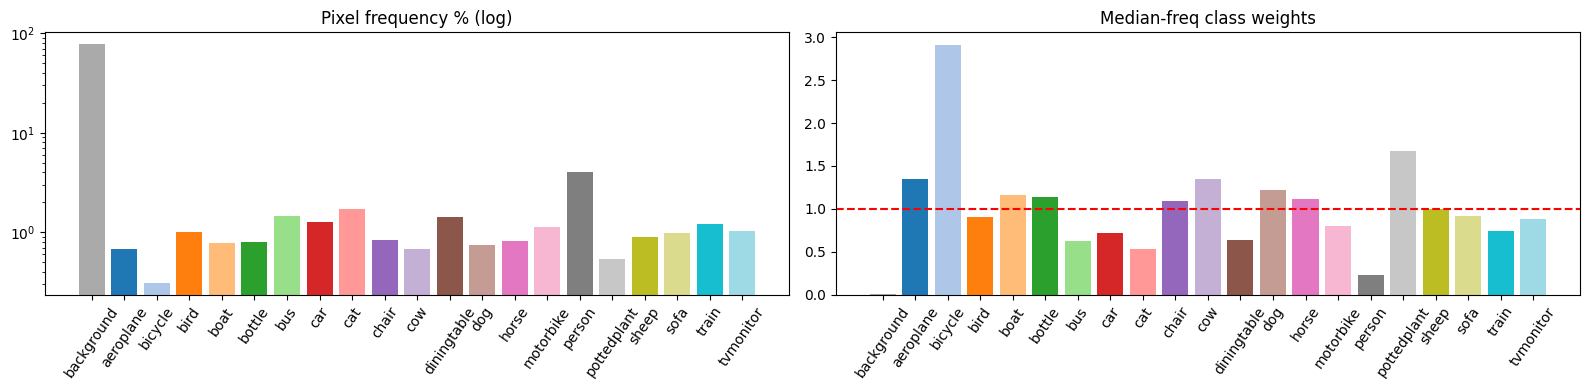

→ Background is 77.7% of all pixels (254× imbalance for bicycle).
  Use weighted CE + Dice for segmentation losses.


In [16]:
# ─── SEG EDA 1: Pixel-level class frequency ──────────────────────────────
PIXEL_FREQ = np.array([
    77.74, 0.67, 0.31, 1.00, 0.78, 0.79, 1.44, 1.26, 1.71, 0.83, 0.67,
    1.42, 0.74, 0.81, 1.12, 4.04, 0.54, 0.90, 0.98, 1.21, 1.03,
], dtype=np.float64) / 100.0

median_freq  = np.median(PIXEL_FREQ[PIXEL_FREQ > 0])
raw_weights  = np.where(PIXEL_FREQ > 0, median_freq / PIXEL_FREQ, 0.0)
raw_weights /= raw_weights[raw_weights > 0].mean()
class_weights_tensor = torch.tensor(raw_weights, dtype=torch.float32).to(DEVICE)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].bar(VOC_CLASSES, 100 * PIXEL_FREQ, color=["#aaa"]+[plt.cm.tab20(i/20) for i in range(20)])
axes[0].set_yscale("log"); axes[0].set_title("Pixel frequency % (log)"); axes[0].tick_params(axis="x", rotation=55)
axes[1].bar(VOC_CLASSES, raw_weights, color=["#aaa"]+[plt.cm.tab20(i/20) for i in range(20)])
axes[1].set_title("Median-freq class weights"); axes[1].tick_params(axis="x", rotation=55)
axes[1].axhline(1.0, ls="--", color="red")
plt.tight_layout(); plt.show()
print("→ Background is 77.7% of all pixels (254× imbalance for bicycle).")
print("  Use weighted CE + Dice for segmentation losses.")

#### Void / boundary pixel analysis (ignore_index=255)

We wanted to check the presence of void or boundary pixels (label = 255) for understanding the correctness of our loss and evaluation metrics. Because treating these ambiguous pixels as background or a valid class introduces noisy supervision and artificially inflates false positives (which systematically lowers IoU/Dice scores), we must explicitly exclude them from all gradient and metric computations using ignore_index=255 in both nn.CrossEntropyLoss and smp.losses.DiceLoss. Confirming their presence makes this mandatory (though we keep it as a safety guard even if absent), and a high number of void pixels also indicates that Conditional Random Field (CRF) post-processing could significantly help sharpen object boundaries.

In [17]:
# ─── SEG EDA 2: Void pixels ──────────────────────────────────────────────
void_counts = np.array([(seg == 255).sum() for seg in train_df["seg"]])
print(f"Images with void pixels: {(void_counts > 0).sum()} / {len(train_df)}")
print(f"Total void pixels: {void_counts.sum():,}")
print("→ Zero void pixels in this pre-processed dataset. ignore_index=255 is harmless but won't fire.")

Images with void pixels: 0 / 749
Total void pixels: 0
→ Zero void pixels in this pre-processed dataset. ignore_index=255 is harmless but won't fire.


#### Object size distribution per class

We wanted to check the object size distributions and within-class scale variance for understanding our backbone stride limitations and augmentation scale ranges.

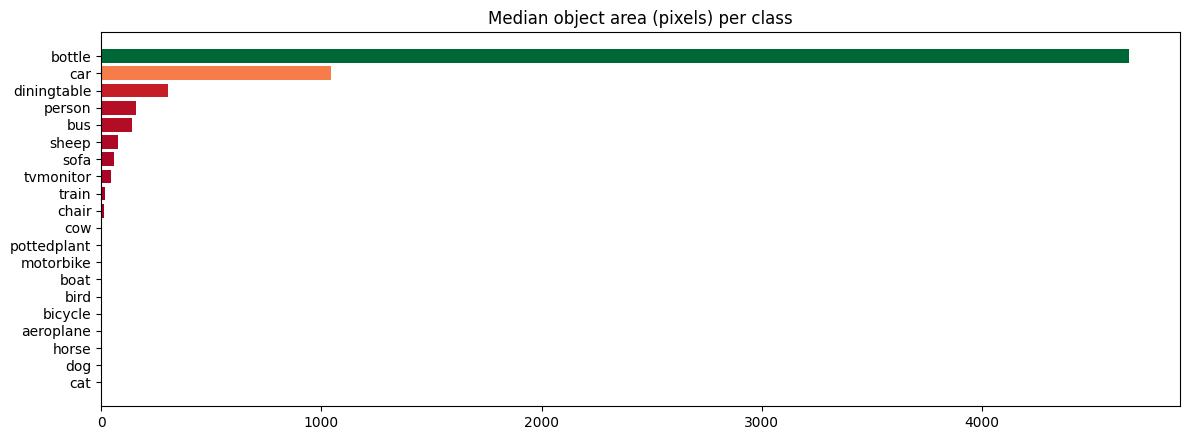

→ Very small median areas are due to fragmented 1-pixel components in the masks,
  not truly microscopic objects. Real objects cover 5-30% of image area when present.


In [18]:
# ─── SEG EDA 3: Object size per class ────────────────────────────────────
from scipy import ndimage
object_areas = {c: [] for c in range(1, NUM_CLASSES)}
for seg in train_df["seg"]:
    for c in range(1, NUM_CLASSES):
        binary = (seg == c)
        if not binary.any(): continue
        labeled, n_objs = ndimage.label(binary)
        for obj_id in range(1, n_objs + 1):
            object_areas[c].append(int((labeled == obj_id).sum()))
medians = {labels[c-1]: np.median(object_areas[c]) if object_areas[c] else 0 for c in range(1,NUM_CLASSES)}
sorted_k = sorted(medians, key=medians.get)
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.barh(sorted_k, [medians[k] for k in sorted_k], color=[plt.cm.RdYlGn(v/max(medians.values())) for v in [medians[k] for k in sorted_k]])
ax.set_title("Median object area (pixels) per class"); plt.tight_layout(); plt.show()
print("→ Very small median areas are due to fragmented 1-pixel components in the masks,")
print("  not truly microscopic objects. Real objects cover 5-30% of image area when present.")

#### Per-class spatial location heatmaps

We wanted to check the spatial distribution and center bias of objects for understanding the risk of location-shortcut learning and our optimal cropping strategy. Because datasets may heavily center subjects, therefore models might learn to predict classes based on location rather than appearance, leading to poor generalization. To break this spatial prior, RandomCrop is mandatory (rather than CenterCrop or naive Resize) to ensure objects appear at varying positions across epochs. Additionally, analyzing these heatmaps reveals class-specific spatial contexts (e.g., horizontal bands for trains, vertical columns for bottles), which helps us diagnose whether future false positives stem from texture confusion or the model exploiting spatial priors.

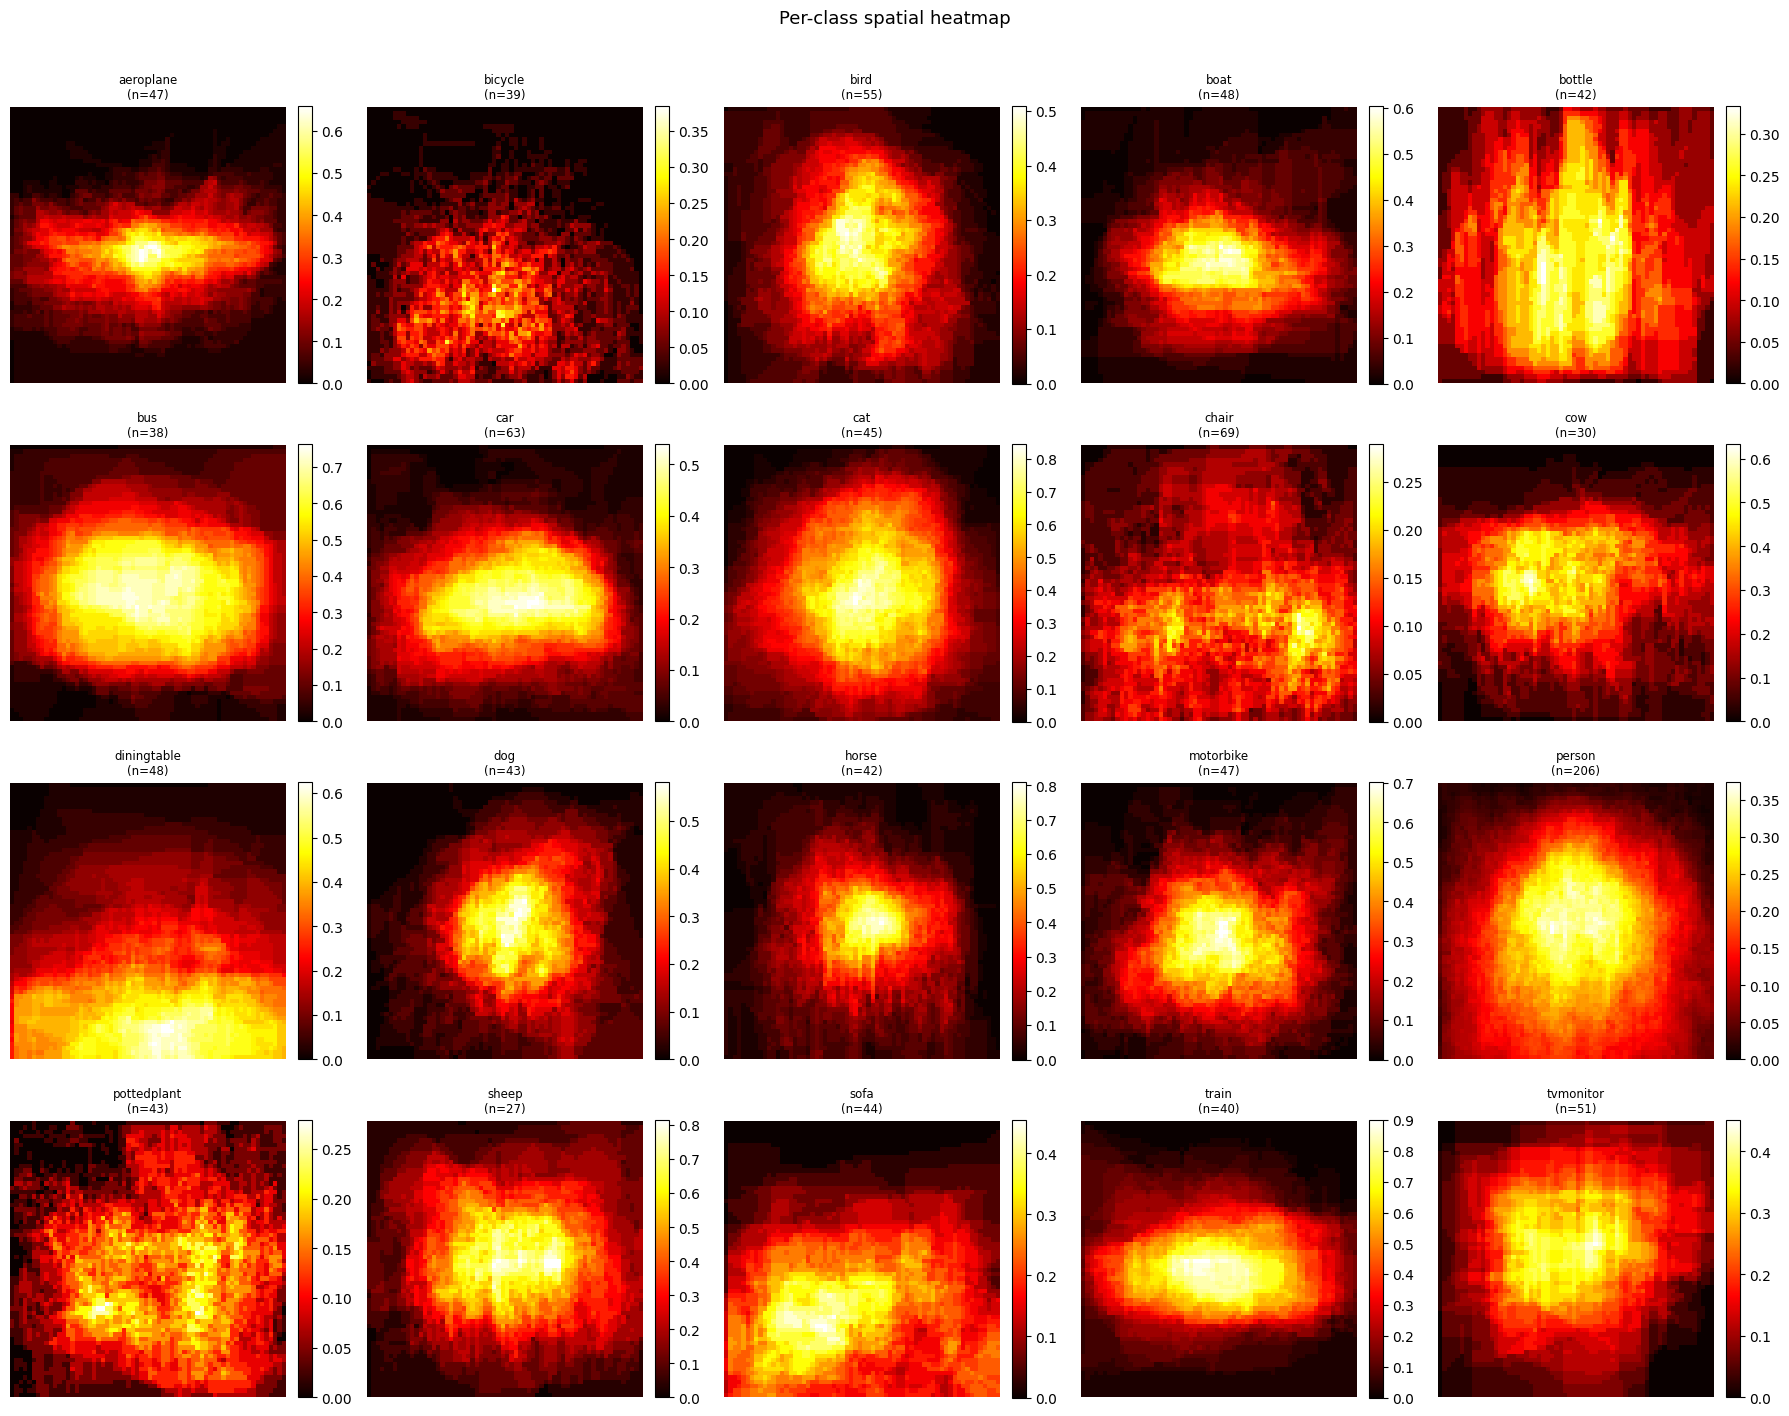

→ Strong centre bias — use RandomCrop (not just Resize) during training to avoid location shortcuts.


In [19]:
# ─── SEG EDA 4: Spatial heatmaps ─────────────────────────────────────────
HMAP_SIZE = 64
heatmaps  = np.zeros((NUM_CLASSES, HMAP_SIZE, HMAP_SIZE))
n_per_cls = np.zeros(NUM_CLASSES, dtype=np.int64)
for seg in train_df["seg"]:
    seg_r = cv2.resize(seg.astype(np.uint8), (HMAP_SIZE, HMAP_SIZE), interpolation=cv2.INTER_NEAREST)
    for c in range(NUM_CLASSES):
        mask = (seg_r == c).astype(np.float32)
        if mask.any(): heatmaps[c] += mask; n_per_cls[c] += 1
for c in range(NUM_CLASSES):
    if n_per_cls[c] > 0: heatmaps[c] /= n_per_cls[c]

fig, axes = plt.subplots(4, 5, figsize=(18, 14))
for i, ax in enumerate(axes.flatten()):
    c = i + 1
    if c >= NUM_CLASSES: ax.axis("off"); continue
    im = ax.imshow(heatmaps[c], cmap="hot", vmin=0)
    ax.set_title(f"{labels[c-1]}\n(n={n_per_cls[c]})", fontsize=8.5); ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle("Per-class spatial heatmap", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()
print("→ Strong centre bias — use RandomCrop (not just Resize) during training to avoid location shortcuts.")

#### Mask coverage density (conditioned on class presence)

We wanted to check the mask coverage density for present classes for understanding our true object size distributions, loss function validation, and expected model performance. By measuring area only in confirmed positive images, we filter out the 1-pixel annotation noise from Cell 3. Discovering that objects typically cover 5–30% of the image confirms that a missed object is a massive spatial error, proving Dice loss is the correct objective over standalone cross-entropy or pixel accuracy. This substantial coverage also indicates that Conditional Random Field (CRF) post-processing will successfully sharpen boundaries without over-segmenting. Finally, it sets realistic evaluation expectations: high-coverage classes (e.g., bus) act as convergence sanity checks (expecting Dice > 0.80), while low-coverage classes (e.g., bicycle) dictate our need for Tversky loss ($\beta=0.7$) and CRF to boost their naturally lower scores.

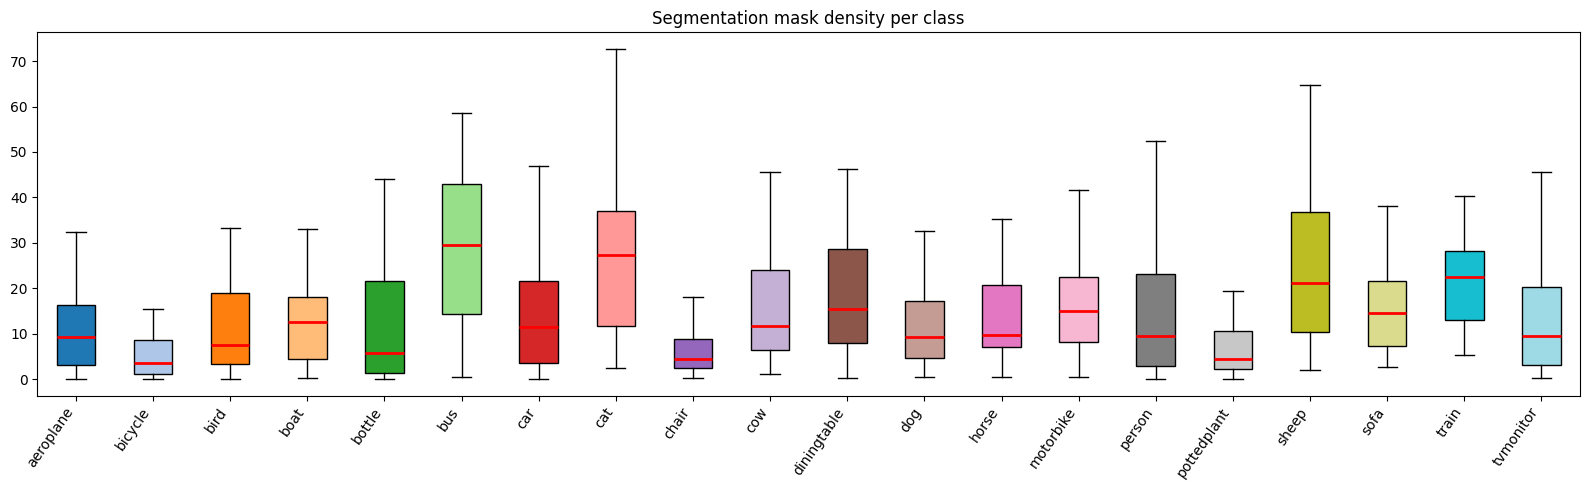

→ When a class IS present it occupies 5-30% of the image. Use Dice loss to reward correct coverage.


In [20]:
# ─── SEG EDA 5: Mask density ─────────────────────────────────────────────
densities = {c: [] for c in range(1, NUM_CLASSES)}
for _, row in train_df.iterrows():
    seg      = row["seg"]; img_area = seg.shape[0] * seg.shape[1]
    for c in range(1, NUM_CLASSES):
        if row[labels[c-1]] == 1:
            densities[c].append(100.0 * int((seg == c).sum()) / img_area)
data_for_plot = [np.array(densities[c]) for c in range(1, NUM_CLASSES) if densities[c]]
xlabels = [labels[c-1] for c in range(1, NUM_CLASSES) if densities[c]]
fig, ax = plt.subplots(figsize=(16, 5))
bp = ax.boxplot(data_for_plot, patch_artist=True, showfliers=False,
                medianprops={"color":"red","linewidth":2})
for patch, color in zip(bp["boxes"], [plt.cm.tab20(i/20) for i in range(len(data_for_plot))]):
    patch.set_facecolor(color)
ax.set_xticklabels(xlabels, rotation=55, ha="right")
ax.set_title("Segmentation mask density per class"); plt.tight_layout(); plt.show()
print("→ When a class IS present it occupies 5-30% of the image. Use Dice loss to reward correct coverage.")

### Section 0.2 — Shared Infrastructure

In [21]:
# ── Stratified split — fixed for all experiments ──────────────────────────
mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
y_all = train_df[labels].values.astype(int)
train_indices, val_indices = next(iter(mskf.split(np.zeros(len(y_all)), y_all)))
train_indices, val_indices = sorted(train_indices.tolist()), sorted(val_indices.tolist())
print(f"Train: {len(train_indices)} | Val: {len(val_indices)}")

Train: 607 | Val: 142


In [22]:
# ── Dataset classes ───────────────────────────────────────────────────────
class VOCClassificationDataset(Dataset):
    def __init__(self, df, label_cols, transform=None):
        self.df         = df.reset_index(drop=True)
        self.label_cols = list(label_cols)
        self.transform  = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = row["img"]
        y   = row[self.label_cols].values.astype(np.float32)
        if self.transform is not None:
            img = self.transform(image=img)["image"]
        return img, torch.from_numpy(y)

class VOCClassificationDatasetTest(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True); self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        img = self.df.iloc[idx]["img"]
        if self.transform is not None:
            img = self.transform(image=img)["image"]
        return img

class VOCSegDataset(Dataset):
    def __init__(self, df, indices, transform):
        self.df = df; self.indices = list(indices); self.transform = transform
    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        row = self.df.iloc[self.indices[i]]
        img = row["img"]
        seg = row["seg"].astype(np.int32)
        out = self.transform(image=img, mask=seg)
        return out["image"], out["mask"].long()

In [23]:
# ── Transforms ────────────────────────────────────────────────────────────
IMG_SIZE = 224

# Classification: strong aug + label smoothing (best from-scratch combo)
cls_train_tf_strong = A.Compose([
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.5, 1.0), ratio=(0.75, 1.3333), p=1.0),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.10, rotate_limit=10, border_mode=0, p=0.50),
    A.GridDistortion(num_steps=3, distort_limit=0.15, p=0.30),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.08, p=0.60),
    A.CoarseDropout(max_holes=6, max_height=32, max_width=32, min_holes=1, fill_value=0, p=0.40),
    A.Normalize(mean=IMG_MEAN, std=IMG_STD), ToTensorV2(),
])

# Classification val (deterministic — required for stable threshold tuning)
cls_val_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=IMG_MEAN, std=IMG_STD), ToTensorV2(),
])

def get_transforms(model_name="segformer"):
    """Return (train_tf, val_tf) for a given segmentation model."""
    if   model_name.lower() == "mask2former": CROP = 512
    elif model_name.lower() == "dinov2":      CROP = 504
    else:                                     CROP = 512
    MEAN_C = (124, 116, 104)
    train_tf = A.Compose([
        A.LongestMaxSize(max_size=int(CROP * 1.5), p=1.0),
        A.RandomScale(scale_limit=(-0.5, 1.0), p=1.0),
        A.PadIfNeeded(min_height=CROP, min_width=CROP, border_mode=cv2.BORDER_CONSTANT,
                      fill=MEAN_C, fill_mask=255),
        A.RandomCrop(height=CROP, width=CROP),
        A.HorizontalFlip(p=0.5),
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)), ToTensorV2(),
    ])
    val_tf = A.Compose([
        A.LongestMaxSize(max_size=CROP, p=1.0),
        A.PadIfNeeded(min_height=CROP, min_width=CROP, border_mode=cv2.BORDER_CONSTANT,
                      fill=MEAN_C, fill_mask=255),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)), ToTensorV2(),
    ])
    return train_tf, val_tf

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_1468/1013148320.py:11: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=6, max_height=32, max_width=32, min_holes=1, fill_value=0, p=0.40),


In [24]:
# ── DataLoaders ───────────────────────────────────────────────────────────
BATCH_SIZE, NUM_WORKERS = 32, 2

fold0_tr_idx = train_indices
fold0_va_idx = val_indices

train_df_cls = train_df.iloc[fold0_tr_idx]
val_df_cls   = train_df.iloc[fold0_va_idx]

train_ds_cls = VOCClassificationDataset(train_df_cls, labels, transform=cls_train_tf_strong)
val_ds_cls   = VOCClassificationDataset(val_df_cls,   labels, transform=cls_val_tf)
train_loader_cls = DataLoader(train_ds_cls, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=="cuda"))
val_loader_cls   = DataLoader(val_ds_cls,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=="cuda"))

def get_dataloaders(model_name, batch_size, num_workers=2):
    train_tf, val_tf = get_transforms(model_name)
    train_ds = VOCSegDataset(train_df, train_indices, train_tf)
    val_ds   = VOCSegDataset(train_df, val_indices,   val_tf)
    pin = DEVICE.type == "cuda"
    return (DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                       num_workers=num_workers, pin_memory=pin),
            DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                       num_workers=num_workers, pin_memory=pin))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [25]:
# ── Loss functions ────────────────────────────────────────────────────────

class AsymmetricLossOptimized(nn.Module):
    """ASL (Ridnik et al. ICCV 2021) — down-weights easy negatives via γ⁻=4."""
    def __init__(self, gamma_neg=4, gamma_pos=1, clip=0.05, eps=1e-8):
        super().__init__()
        self.gamma_neg = gamma_neg; self.gamma_pos = gamma_pos
        self.clip = clip; self.eps = eps
    def forward(self, logits, targets):
        xs_pos = torch.sigmoid(logits)
        xs_neg = 1.0 - xs_pos
        if self.clip > 0:
            xs_neg = (xs_neg + self.clip).clamp(max=1.0)
        loss = (targets       * torch.log(xs_pos.clamp(min=self.eps)) +
                (1 - targets) * torch.log(xs_neg.clamp(min=self.eps)))
        if self.gamma_neg > 0 or self.gamma_pos > 0:
            pt  = xs_pos * targets + xs_neg * (1 - targets)
            w   = torch.pow(1 - pt, self.gamma_pos * targets + self.gamma_neg * (1 - targets))
            loss = loss * w
        return -loss.mean()


class LabelSmoothingBCE(nn.Module):
    """Symmetric label smoothing: 1→0.95, 0→0.05."""
    def __init__(self, smoothing=0.10):
        super().__init__()
        self.smoothing = smoothing
        self.bce = nn.BCEWithLogitsLoss(reduction="mean")
    def forward(self, logits, targets):
        soft = targets * (1.0 - self.smoothing) + 0.5 * self.smoothing
        return self.bce(logits, soft)


class PresentClassDiceLoss(nn.Module):
    """
    Dice loss averaging ONLY over classes present in the current batch.

    Why this matters (discovered experimentally by Manolis):
    smp.losses. DiceLoss averages over all 21 classes regardless of which are
    actually in the batch. When a rare class has no GT pixels in a batch, its
    Dice is near-zero from the smoothing term and drags the mean down — the
    gradient falsely penalises the model for a class that isn't there.
    Background (class 0) is excluded from the Dice mean: it trivially dominates
    and inflates the metric. CE still supervises background via class weights.
    """
    def __init__(self, num_classes=NUM_CLASSES, smooth=1.0):
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth

    def forward(self, logits, targets):
        valid_mask = (targets != 255)
        targets_clean = targets.clone()
        targets_clean[~valid_mask] = 0
        probs = F.softmax(logits, dim=1)
        targets_oh = F.one_hot(targets_clean, self.num_classes).permute(0,3,1,2).float()
        vm = valid_mask.unsqueeze(1).float()
        probs = probs * vm; targets_oh = targets_oh * vm
        dims = (0, 2, 3)
        inter = (probs * targets_oh).sum(dims)
        p_sum = probs.sum(dims); t_sum = targets_oh.sum(dims)
        dice = (2*inter + self.smooth) / (p_sum + t_sum + self.smooth)
        fg_dice = dice[1:]
        fg_present = t_sum[1:] > 0
        if fg_present.any():
            return 1.0 - fg_dice[fg_present].mean()
        return logits.sum() * 0.0

class CEDiceLoss(nn.Module):
    """
    CE (median-frequency class weights) + PresentClassDiceLoss.

    ce_weight=1.0, dice_weight=5.0  (Manolis ablation on VOC segmentation):
    Equal weighting (0.5/0.5) lets CE dominate early training — the model
    learns background and common classes quickly but never pushes rare
    foreground classes above noise. A 1:5 ratio gives Dice enough influence
    to force the model to segment foreground regions correctly.
    Without this, bicycle and bottle Dice stayed below 0.40 at convergence.
    """
    def __init__(self, class_weights=None, ce_weight=1.0, dice_weight=5.0):
        super().__init__()
        self.ce_w = ce_weight; self.dice_w = dice_weight
        self.ce   = nn.CrossEntropyLoss(weight=class_weights, ignore_index=255)
        self.dice = PresentClassDiceLoss(num_classes=NUM_CLASSES)

    def forward(self, y_pred, y_true):
        if y_true.dim() == 4: y_true = y_true.squeeze(1)
        return self.ce_w * self.ce(y_pred, y_true) + self.dice_w * self.dice(y_pred, y_true)

criterion_seg = CEDiceLoss(class_weights=class_weights_tensor, ce_weight=1.0, dice_weight=5.0)
asl_loss_cls = AsymmetricLossOptimized(gamma_neg=4, gamma_pos=1, clip=0.05, eps=1e-8)
ls_bce = LabelSmoothingBCE()

In [26]:
# ── Training / evaluation loops ───────────────────────────────────────────

@torch.no_grad()
def evaluate_cls(model, loader, loss_fn, device=DEVICE):
    """Return (mean_loss, macro_mAP, all_logits_cpu, all_targets_cpu)."""
    model.eval()
    losses, all_logits, all_targets = [], [], []
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True); yb = yb.to(device, non_blocking=True)
        logits = model(xb)
        losses.append(loss_fn(logits, yb).item())
        all_logits.append(logits.float().cpu()); all_targets.append(yb.cpu())
    all_logits  = torch.cat(all_logits); all_targets = torch.cat(all_targets)
    probs       = torch.sigmoid(all_logits).numpy()
    t_np        = all_targets.numpy()
    aps  = [average_precision_score(t_np[:, c], probs[:, c])
            for c in range(t_np.shape[1]) if t_np[:, c].sum() > 0]
    return float(np.mean(losses)), float(np.mean(aps)) if aps else 0.0, all_logits, all_targets

def train_cls(model, train_loader, val_loader, *, epochs, optimizer, scheduler=None,
              loss_fn=None, device=DEVICE, use_amp=True, log_every=1, name="model",
              checkpoint_path=None):
    """Generic classification training loop. Returns (history, best_state, last_logits, last_targets)."""
    if loss_fn is None: loss_fn = nn.BCEWithLogitsLoss()
    model.to(device)
    use_amp = use_amp and (device.type == "cuda")
    scaler  = GradScaler(enabled=use_amp)
    history = {"train_loss": [], "val_loss": [], "val_mAP": []}
    best_mAP, best_state, last_logits, last_targets = -1.0, None, None, None

    for epoch in range(1, epochs + 1):
        model.train(); epoch_losses = []
        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True); yb = yb.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with autocast(device_type=device.type, enabled=use_amp):
                loss = loss_fn(model(xb), yb)
            scaler.scale(loss).backward(); scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update(); epoch_losses.append(loss.item())
        if scheduler is not None: scheduler.step()
        val_loss, val_mAP, last_logits, last_targets = evaluate_cls(model, val_loader, loss_fn, device)
        train_loss = float(np.mean(epoch_losses))
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["val_mAP"].append(val_mAP)
        if val_mAP > best_mAP:
            best_mAP = val_mAP; best_state = copy.deepcopy(model.state_dict())
            if checkpoint_path:
                torch.save(best_state, checkpoint_path)
        if epoch % log_every == 0:
            improved = " ✓" if val_mAP >= best_mAP else ""
            print(f"[{name}] ep {epoch:3d}/{epochs}  train {train_loss:.4f}  val {val_loss:.4f}  mAP {val_mAP:.4f}  lr {optimizer.param_groups[0]['lr']:.2e}{improved}")
    print(f"[{name}] best val mAP: {best_mAP:.4f}")
    return history, best_state, last_logits, last_targets

def train_cls_two_phase(model, train_loader, val_loader, *, epochs, optimizer, scheduler=None,
                   loss_fn=None, device=DEVICE, use_amp=True, log_every=1, name="model", checkpoint_path=None,
                   unfreeze_epoch=30, unfreeze_n_blocks=4,
                   phase2_backbone_lr=1e-5, phase2_head_lr=5e-4):
    """Two-phase training for CLIP (fp16-safe for ViT encoders, NOT DINOv2 SwiGLU)."""
    if loss_fn is None: loss_fn = nn.BCEWithLogitsLoss()
    model.to(device); use_amp = use_amp and (device.type == "cuda"); scaler = GradScaler(enabled=use_amp)
    history = {"train_loss": [], "val_loss": [], "val_mAP": []}
    best_mAP, best_state, phase2_entered = -1.0, None, False
    last_logits = last_targets = None
    for epoch in range(1, epochs + 1):
        if epoch == unfreeze_epoch and not phase2_entered:
            phase2_entered = True; model.unfreeze_last_n_blocks(n=unfreeze_n_blocks)
            optimizer = torch.optim.AdamW([
                {"params": [p for p in model.backbone.parameters() if p.requires_grad] if hasattr(model, "backbone") else [p for p in model.visual.parameters() if p.requires_grad], "lr": phase2_backbone_lr, "weight_decay": 1e-4},
                {"params": model.head.parameters(), "lr": phase2_head_lr, "weight_decay": 1e-4},
            ])
            scaler    = GradScaler(enabled=use_amp)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs - unfreeze_epoch, eta_min=1e-6)
        model.train(); epoch_losses = []
        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True); yb = yb.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with autocast(device_type=device.type, enabled=use_amp):
                loss = loss_fn(model(xb), yb)
            scaler.scale(loss).backward(); scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update(); epoch_losses.append(loss.item())
        if scheduler is not None: scheduler.step()
        val_loss, val_mAP, last_logits, last_targets = evaluate_cls(model, val_loader, loss_fn, device)
        train_loss = float(np.mean(epoch_losses))
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss); history["val_mAP"].append(val_mAP)
        if val_mAP > best_mAP:
            best_mAP = val_mAP; best_state = copy.deepcopy(model.state_dict())
            if checkpoint_path:
                torch.save(best_state, checkpoint_path)
        if epoch % log_every == 0:
            phase = "P2" if phase2_entered else "P1"
            improved = " ✓" if val_mAP >= best_mAP else ""
            print(f"[{name}|{phase}] ep {epoch:3d}/{epochs}  train {train_loss:.4f}  val {val_loss:.4f}  mAP {val_mAP:.4f}{improved}")
    print(f"[{name}] best val mAP: {best_mAP:.4f}")
    return history, best_state, last_logits, last_targets


def tune_thresholds(val_logits, val_targets, grid=None):
    """Per-class threshold sweep that maximises val Dice. Returns (thresholds, per_class_dice)."""
    if grid is None: grid = np.linspace(0.05, 0.95, 19)
    probs, targets = torch.sigmoid(val_logits.float()).numpy(), val_targets.numpy().astype(np.int64)
    n_classes = targets.shape[1]; thresholds = np.zeros(n_classes); best_dices = np.zeros(n_classes)
    for c in range(n_classes):
        y_true = targets[:, c]; y_prob = probs[:, c]
        if y_true.sum() == 0: thresholds[c] = 0.5; continue
        best_t, best_d = 0.5, 0.0
        for t in grid:
            y_pred = (y_prob >= t).astype(np.int64)
            tp = int((y_pred & y_true).sum()); fp = int(y_pred.sum() - tp); fn = int(y_true.sum() - tp)
            denom = 2*tp+fp+fn; d = (2*tp/denom) if denom > 0 else 0.0
            if d > best_d: best_d, best_t = d, t
        thresholds[c] = best_t; best_dices[c] = best_d
    return thresholds, best_dices

def predict_cls(model, test_ds, thresholds, batch_size=64, device=DEVICE):
    loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    model.to(device).eval(); probs_chunks = []
    with torch.no_grad():
        for xb in loader:
            probs_chunks.append(torch.sigmoid(model(xb.to(device))).float().cpu().numpy())
    probs = np.concatenate(probs_chunks, axis=0)
    return (probs >= thresholds[None, :]).astype(np.int64), probs

def save_to_drive(local_path, drive_dir=None):
    if drive_dir is None: return
    try:
        os.makedirs(drive_dir, exist_ok=True)
        dest = os.path.join(drive_dir, os.path.basename(local_path))
        shutil.copy2(local_path, dest); print(f"  ✓ Saved → {dest}")
    except Exception as e:
        print(f"  ✗ Drive save failed: {e}")

In [27]:
# ── Submission helpers ────────────────────────────────────────────────────
def _rle_encode(img):
    pixels = img.flatten()
    pixels = np.concatenate([[0], pixels, [0]])
    runs   = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return " ".join(str(x) for x in runs)

def generate_submission(df):
    df_dict = {"Id": [], "Predicted": []}
    for idx, _ in df.iterrows():
        df_dict["Id"].append(f"{idx}_classification")
        df_dict["Predicted"].append(_rle_encode(np.array(df.loc[idx, labels])))
        df_dict["Id"].append(f"{idx}_segmentation")
        df_dict["Predicted"].append(_rle_encode(
            np.array([df.loc[idx, "seg"] == j+1 for j in range(len(labels))])))
    submission_df = pd.DataFrame(data=df_dict, dtype=str).set_index("Id")
    submission_df.to_csv("submission.csv")
    return submission_df

### Diagnostic & Visualization Functions

The cells below define all diagnostic and attribution functions used after each
model's training. They are defined once here in the shared infrastructure so
every model can call the same interface.

**Classification diagnostics** (`analyze_worst_f1`): computes per-class F1,
Precision, Recall and AP; renders a colour-coded F1 bar chart; a stacked
TP/FP/FN bar chart that distinguishes over-firing from under-firing; and for
the *n* worst classes, surfaces the most confidently wrong False Positive and
False Negative images from the validation set.

**Pixel attribution** (`visualize_dino_cls_attention`, `visualize_clip_patch_activation`,
`visualize_grad_cam`): reveals *which pixels* drove a prediction using the
model's own internal signals — no external libraries, no surrogate models.

**Segmentation diagnostics** (`analyze_worst_seg`): same philosophy as
classification but at the pixel level — per-class IoU and Dice, a pixel-count
TP/FP/FN stacked bar that separates over-segmentation from under-segmentation,
and a four-column failure grid (input | GT overlay | pred overlay | green/red/blue
diff map) for the worst classes.

**Attribution for segmentation** (`visualize_dino_seg_attention`,
`visualize_m2f_query_attention`): shows which encoder regions DINOv2 attends to
during dense prediction, and which pixels Mask2Former's class queries focus on.

In [28]:
_IMG_MEAN_D = np.array([0.485, 0.456, 0.406]).reshape(3,1,1)
_IMG_STD_D  = np.array([0.229, 0.224, 0.225]).reshape(3,1,1)

def _denorm_cls(t):
    img = t.cpu().numpy() * _IMG_STD_D + _IMG_MEAN_D
    return np.clip(img.transpose(1,2,0)*255, 0, 255).astype(np.uint8)

# ── Inference ─────────────────────────────────────────────────────
@torch.no_grad()
def get_val_predictions(model, val_loader, thresholds,
                        is_dinov2_fp32=False, device=DEVICE):
    model.eval()
    if is_dinov2_fp32: model.backbone.float()
    all_probs, all_targets = [], []
    for xb, yb in val_loader:
        xb = xb.to(device, non_blocking=True)
        if is_dinov2_fp32:
            out = model.backbone.forward_features(xb.float())
            feat = out["x_norm_clstoken"] + out["x_norm_patchtokens"].mean(1)
            logits = model.head(feat.float())
        else:
            logits = model(xb).float()
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_targets.append(yb.numpy())
    probs   = np.concatenate(all_probs).astype(np.float32)
    targets = np.concatenate(all_targets).astype(np.int64)
    preds   = (probs >= np.asarray(thresholds)[None,:]).astype(np.int64)
    return probs, preds, targets

# ── Per-class metrics ─────────────────────────────────────────────
def compute_per_class_metrics(probs, preds, targets, labels):
    rows = []
    for c in range(targets.shape[1]):
        y_true=targets[:,c]; y_pred=preds[:,c]; y_prob=probs[:,c]
        sup=int(y_true.sum())
        tp=int(((y_pred==1)&(y_true==1)).sum())
        fp=int(((y_pred==1)&(y_true==0)).sum())
        fn=int(((y_pred==0)&(y_true==1)).sum())
        rows.append(dict(class_idx=c, name=labels[c],
            f1=float(f1_score(y_true,y_pred,zero_division=0)),
            precision=float(precision_score(y_true,y_pred,zero_division=0)),
            recall=float(recall_score(y_true,y_pred,zero_division=0)),
            ap=float(average_precision_score(y_true,y_prob) if sup>0 else 0.0),
            support=sup, tp=tp, fp=fp, fn=fn))
    rows.sort(key=lambda r: r["f1"])
    return rows

def print_cls_metrics_table(rows, title="Per-class metrics"):
    print(f"\n{'='*72}\n  {title}\n{'='*72}")
    print(f"  {'Class':<16} {'F1':>6} {'Prec':>6} {'Rec':>6} {'AP':>6}  {'Sup':>5}  {'TP':>4} {'FP':>4} {'FN':>4}")
    print(f"  {'-'*68}")
    for r in rows:
        flag = "  ←" if r["f1"] < 0.40 else ""
        print(f"  {r['name']:<16} {r['f1']:>6.3f} {r['precision']:>6.3f} {r['recall']:>6.3f} {r['ap']:>6.3f}  {r['support']:>5}  {r['tp']:>4} {r['fp']:>4} {r['fn']:>4}{flag}")
    print(f"  {'-'*68}")
    print(f"  {'MACRO':<16} {np.mean([r['f1'] for r in rows]):>6.3f} {'':>6} {'':>6} {np.mean([r['ap'] for r in rows if r['support']>0]):>6.3f}\n")

def plot_f1_bar(rows, model_name="model"):
    import matplotlib.patches as mpatches
    names=[r["name"] for r in rows]; f1s=[r["f1"] for r in rows]
    colors=["#d73027" if v<0.40 else "#fc8d59" if v<0.60 else "#91cf60" if v<0.80 else "#1a9850" for v in f1s]
    fig,ax=plt.subplots(figsize=(8,7))
    bars=ax.barh(names,f1s,color=colors,edgecolor="white",height=0.7)
    ax.axvline(0.5,color="grey",lw=1.2,ls="--"); ax.set_xlim(0,1.12)
    ax.set_xlabel("F1"); ax.set_title(f"Per-class F1 — {model_name}",fontsize=12)
    for bar,val in zip(bars,f1s):
        ax.text(val+0.01,bar.get_y()+bar.get_height()/2,f"{val:.3f}",va="center",fontsize=8.5)
    ax.legend(handles=[
        mpatches.Patch(color="#d73027",label="F1<0.40 critical"),
        mpatches.Patch(color="#fc8d59",label="0.40–0.60 weak"),
        mpatches.Patch(color="#91cf60",label="0.60–0.80 good"),
        mpatches.Patch(color="#1a9850",label="F1>0.80 strong"),
    ],loc="lower right",fontsize=9)
    plt.tight_layout(); plt.show()

def plot_cls_pr_breakdown(rows, n_worst=8, model_name="model"):
    worst=rows[:n_worst]; names=[r["name"] for r in worst]
    tps=[r["tp"] for r in worst]; fps=[r["fp"] for r in worst]; fns=[r["fn"] for r in worst]
    x=np.arange(len(names))
    fig,ax=plt.subplots(figsize=(10,4.5))
    ax.bar(x,tps,label="TP",color="#2ecc71")
    ax.bar(x,fps,bottom=tps,label="FP (↓ precision)",color="#e74c3c")
    ax.bar(x,fns,bottom=[t+f for t,f in zip(tps,fps)],label="FN (↓ recall)",color="#3498db")
    ax.set_xticks(x); ax.set_xticklabels(names,rotation=35,ha="right",fontsize=10)
    ax.set_ylabel("Count"); ax.set_title(f"TP/FP/FN — {n_worst} worst — {model_name}",fontsize=11)
    ax.legend(fontsize=9); plt.tight_layout(); plt.show()

def show_cls_failure_cases(class_row, probs, preds, targets,
                            val_dataset, labels, n_images=4, model_name="model"):
    c=class_row["class_idx"]; name=class_row["name"]
    y_true=targets[:,c]; y_pred=preds[:,c]; y_prob=probs[:,c]
    fn_idx=np.where((y_pred==0)&(y_true==1))[0]
    fn_idx=fn_idx[np.argsort(-y_prob[fn_idx])][:n_images]
    fp_idx=np.where((y_pred==1)&(y_true==0))[0]
    fp_idx=fp_idx[np.argsort(-y_prob[fp_idx])][:n_images]
    n_fn=len(fn_idx); n_fp=len(fp_idx)
    if n_fn+n_fp==0: print(f"  [{name}] No failures!"); return
    ncols=max(n_fn,n_fp,1)
    fig,axes=plt.subplots(2,ncols,figsize=(3.6*ncols,9.5),squeeze=False)
    fig.suptitle(f"{model_name} · '{name}'  F1={class_row['f1']:.3f} P={class_row['precision']:.3f} R={class_row['recall']:.3f}",fontsize=11,y=1.02)
    def _fill(ax,idx,prob,mode):
        img_t,_=val_dataset[idx]; ax.imshow(_denorm_cls(img_t)); ax.axis("off")
        color="#2471a3" if mode=="FN" else "#c0392b"
        subtitle="MISSED (label=1, pred=0)" if mode=="FN" else "HALLUCINATED (label=0, pred=1)"
        ax.set_title(f"{subtitle}\np({name})={prob:.3f}",fontsize=8,color=color,fontweight="bold")
        true_cls=[labels[j] for j in range(len(labels)) if targets[idx,j]==1]
        ax.text(0.5,0.02,"labels: "+", ".join(true_cls),transform=ax.transAxes,ha="center",va="bottom",
                fontsize=7.5,bbox=dict(boxstyle="round,pad=0.25",fc="lightyellow",alpha=0.85))
    axes[0,0].set_ylabel("False Negatives\n(missed)",color="#2471a3",fontsize=9,fontweight="bold",labelpad=8)
    for col,idx in enumerate(fn_idx): _fill(axes[0,col],idx,float(y_prob[idx]),"FN")
    for col in range(n_fn,ncols): axes[0,col].axis("off")
    axes[1,0].set_ylabel("False Positives\n(hallucinated)",color="#c0392b",fontsize=9,fontweight="bold",labelpad=8)
    for col,idx in enumerate(fp_idx): _fill(axes[1,col],idx,float(y_prob[idx]),"FP")
    for col in range(n_fp,ncols): axes[1,col].axis("off")
    # plt.subplots_adjust(hspace=0.45)
    plt.tight_layout(); plt.show()
    print(f"  [{name}]  FN={n_fn}  FP={n_fp}")

def analyze_worst_f1(model, val_loader, labels, thresholds,
                     model_name="model", is_dinov2_fp32=False,
                     n_worst=5, n_images=4, device=DEVICE):
    """Full classification diagnostic: table → F1 bar → TP/FP/FN bars → failure images."""
    print(f"\n{'─'*60}\n  Worst-F1 diagnostic → {model_name}\n{'─'*60}")
    probs,preds,targets=get_val_predictions(model,val_loader,np.asarray(thresholds),
                                             is_dinov2_fp32=is_dinov2_fp32,device=device)
    rows=compute_per_class_metrics(probs,preds,targets,labels)
    print_cls_metrics_table(rows,title=f"Per-class metrics — {model_name}")
    plot_f1_bar(rows,model_name=model_name)
    plot_cls_pr_breakdown(rows,n_worst=min(n_worst+3,len(rows)),model_name=model_name)
    val_dataset=val_loader.dataset
    print(f"\n  Failure cases — {n_worst} worst classes:\n")
    for row in rows[:n_worst]:
        show_cls_failure_cases(row,probs,preds,targets,val_dataset,labels,n_images,model_name)
    return dict(probs=probs,preds=preds,targets=targets,metrics_rows=rows)

def compare_cls_models_f1(results_dict, labels):
    """Side-by-side F1 bars + per-class winner table for all classification models."""
    model_names=list(results_dict.keys()); n_models=len(model_names); n_classes=len(labels)
    f1_mat=np.zeros((n_models,n_classes))
    for m_idx,(name,res) in enumerate(results_dict.items()):
        lookup={r["name"]:r["f1"] for r in res["metrics_rows"]}
        for c_idx,cls in enumerate(labels): f1_mat[m_idx,c_idx]=lookup.get(cls,0.0)
    order=np.argsort(f1_mat.mean(axis=0))
    sl=[labels[i] for i in order]; sm=f1_mat[:,order]
    x=np.arange(n_classes); width=0.75/n_models
    colors=["#3498db","#e67e22","#2ecc71","#9b59b6"]
    fig,ax=plt.subplots(figsize=(16,5.5))
    for m_idx,(m_name,color) in enumerate(zip(model_names,colors)):
        offset=(m_idx-n_models/2+0.5)*width
        ax.bar(x+offset,sm[m_idx],width,label=m_name,color=color,alpha=0.85,edgecolor="white")
    ax.set_xticks(x); ax.set_xticklabels(sl,rotation=45,ha="right",fontsize=9)
    ax.set_ylim(0,1.08); ax.set_ylabel("F1"); ax.axhline(0.5,color="grey",lw=1,ls="--",alpha=0.5)
    ax.set_title("Per-class F1 across classification models (sorted by mean F1)",fontsize=12)
    ax.legend(fontsize=10); plt.tight_layout(); plt.show()
    print(f"\n  {'Class':<16} {'Best model':<22} {'F1':>6}   {'Worst model':<22} {'F1':>6}")
    print(f"  {'-'*72}")
    for c_idx in order:
        cls=labels[c_idx]; best=int(np.argmax(f1_mat[:,c_idx])); worst=int(np.argmin(f1_mat[:,c_idx]))
        print(f"  {cls:<16} {model_names[best]:<22} {f1_mat[best,c_idx]:>6.3f}   {model_names[worst]:<22} {f1_mat[worst,c_idx]:>6.3f}")

# ─────────────────────────────────────────────────────────────────
# LOAD-OR-TRAIN HELPERS
# ─────────────────────────────────────────────────────────────────

def _find_weights(weights_path, drive_dir=None):
    """Return first existing path from: local, drive_dir, /content."""
    candidates = [
        weights_path,
        (os.path.join(drive_dir, os.path.basename(weights_path)) if drive_dir else None),
        os.path.join("/content", os.path.basename(weights_path)),
    ]
    for p in candidates:
        if p and os.path.isfile(p):
            return p
    return None


def try_load_cls_checkpoint(model, weights_path, val_loader, labels,
                             is_dinov2_fp32=False, device=DEVICE,
                             drive_dir=None):
    """
    If a checkpoint exists (locally or in Drive): load it, re-run val
    inference, tune thresholds, and return everything the downstream
    cells need.

    If no checkpoint is found, return (False, None, None, None, None)
    so the caller falls through to the training block.

    Returns
    -------
    found          : bool
    val_logits     : (N, C) float tensor  — needed for threshold tuning
                     and ensemble weight search
    val_targets    : (N, C) int tensor
    thresholds     : (C,) float array
    dice_per_class : (C,) float array
    """
    found_path = _find_weights(weights_path, drive_dir)
    if found_path is None:
        print(f"  [checkpoint] not found at '{weights_path}' → training from scratch")
        return False, None, None, None, None

    print(f"  [checkpoint] Loading from '{found_path}' ...")
    state = torch.load(found_path, map_location=device, weights_only=True)
    model.load_state_dict(state)
    model.to(device)

    print("  [checkpoint] Running val inference ...")
    dummy_loss = nn.BCEWithLogitsLoss()
    if is_dinov2_fp32:
        _, val_mAP, val_logits, val_targets = evaluate_cls_fp32(
            model, val_loader, dummy_loss, device)
    else:
        _, val_mAP, val_logits, val_targets = evaluate_cls(
            model, val_loader, dummy_loss, device)

    if not torch.isfinite(val_logits).all():
        val_logits = torch.nan_to_num(val_logits, nan=0.0, posinf=10.0, neginf=-10.0)

    thresholds, dice = tune_thresholds(val_logits, val_targets)
    print(f"  [checkpoint] val mAP={val_mAP:.4f}  mean Dice={dice.mean():.4f}  "
          f"(thresholds re-tuned)")
    return True, val_logits, val_targets, thresholds, dice


def try_load_seg_checkpoint(model, weights_path, device=DEVICE,
                             drive_dir=None):
    """
    If a checkpoint exists: load it into model and return True.
    If not: return False so the caller runs training.

    The diagnostic cells (analyze_worst_seg etc.) re-run inference
    internally so nothing extra is needed after loading.
    """
    found_path = _find_weights(weights_path, drive_dir)
    if found_path is None:
        print(f"  [checkpoint] not found at '{weights_path}' → training from scratch")
        return False

    print(f"  [checkpoint] Loading from '{found_path}' ...")
    state = torch.load(found_path, map_location=device, weights_only=True)
    model.load_state_dict(state)
    model.to(device)
    print("  [checkpoint] Model ready.")
    return True

In [29]:
# ── Pixel attribution visualizations ─────────────────────────────

def _show_attn_overlay(img_np, attn_up, title="", cmap="inferno"):
    fig,axes=plt.subplots(1,3,figsize=(13,4))
    axes[0].imshow(img_np); axes[0].set_title("Input"); axes[0].axis("off")
    axes[1].imshow(attn_up,cmap=cmap,vmin=0,vmax=1); axes[1].set_title("Attribution map"); axes[1].axis("off")
    axes[2].imshow(img_np); axes[2].imshow(attn_up,cmap=cmap,alpha=0.55,vmin=0,vmax=1)
    axes[2].set_title(title); axes[2].axis("off")
    plt.tight_layout(); plt.show()

@torch.no_grad()
def _compute_clip_patch_activation(model, image_tensor, class_idx,
                                    patch_size=16, device=DEVICE):
    """Compute-only: returns (H,W) per-patch class activation without displaying."""
    model.eval()
    B,C,H,W = image_tensor.shape; ph,pw = H//patch_size, W//patch_size
    patch_feats = [None]
    def _hook(m,i,o): patch_feats[0] = o.detach()
    h = model.visual.transformer.resblocks[-1].register_forward_hook(_hook)
    cls_feat = model.backbone.encode_image(image_tensor.to(device)).float()
    h.remove()
    tokens  = patch_feats[0][0,1:,:].float()
    cls_exp = cls_feat.expand(ph*pw,-1)
    fused   = torch.cat([cls_exp,tokens],dim=1)
    logits  = model.head(fused)
    act     = torch.sigmoid(logits[:,class_idx]).cpu().numpy().reshape(ph,pw)
    act_up  = F.interpolate(torch.tensor(act).unsqueeze(0).unsqueeze(0).float(),
                             size=(H,W),mode="bilinear",align_corners=False).squeeze().numpy()
    return (act_up-act_up.min())/(act_up.max()-act_up.min()+1e-8)

def grad_cam(model, image_tensor, class_idx, target_layer, device=DEVICE):
    """Grad-CAM: gradient of class score w.r.t. last conv feature map.
    Works for SmallCNN and any CNN with spatial activations."""
    model.eval()
    activations,gradients = {},{}
    fwd_h = target_layer.register_forward_hook(lambda m,i,o: activations.update({"feat":o.detach()}))
    bwd_h = target_layer.register_full_backward_hook(lambda m,gi,go: gradients.update({"grad":go[0].detach()}))
    xb = image_tensor.to(device)
    logits = model(xb)
    model.zero_grad(); logits[0,class_idx].backward()
    fwd_h.remove(); bwd_h.remove()
    weights = gradients["grad"][0].mean(dim=(1,2))
    cam = F.relu((weights[:,None,None]*activations["feat"][0]).sum(0))
    cam = cam.cpu().numpy(); cam = (cam-cam.min())/(cam.max()-cam.min()+1e-8)
    H,W = image_tensor.shape[-2:]
    cam_up = F.interpolate(torch.tensor(cam).unsqueeze(0).unsqueeze(0).float(),
                            size=(H,W),mode="bilinear",align_corners=False).squeeze().numpy()
    img_np = _denorm_cls(image_tensor[0])
    return cam_up, img_np

def visualize_grad_cam(model, image_tensor, class_idx, target_layer,
                       label_name="", device=DEVICE):
    """Display Grad-CAM heatmap for SmallCNN classification."""
    cam_up, img_np = grad_cam(model,image_tensor,class_idx,target_layer,device)
    _show_attn_overlay(img_np,cam_up,title=f"Grad-CAM [{label_name}]",cmap="jet")
    return cam_up

In [30]:
_SEG_CMAP = plt.get_cmap("nipy_spectral")

def _denorm_seg(t):
    img = t.cpu().numpy() * np.array([0.229,0.224,0.225]).reshape(3,1,1)            + np.array([0.485,0.456,0.406]).reshape(3,1,1)
    return np.clip(img.transpose(1,2,0)*255,0,255).astype(np.uint8)

def _colour_mask(mask_np, n=21):
    return (_SEG_CMAP(mask_np.astype(np.float32)/(n-1))*255).astype(np.uint8)

def _overlay_seg(img,mask,alpha=0.5,n=21):
    c=_colour_mask(mask,n)[...,:3]
    return np.clip(img.astype(np.float32)*(1-alpha)+c.astype(np.float32)*alpha,0,255).astype(np.uint8)

@torch.no_grad()
def get_seg_predictions(model, val_loader, is_mask2former=False, device=DEVICE):
    model.eval()
    if is_mask2former:
        from transformers import Mask2FormerImageProcessor
        proc=Mask2FormerImageProcessor(ignore_index=255,do_resize=False,do_rescale=False,do_normalize=False)
    images_list,preds_list,gts_list=[],[],[]
    for images,masks in tqdm(val_loader,desc="Seg inference"):
        images=images.to(device,non_blocking=True); H,W=masks.shape[-2],masks.shape[-1]
        if is_mask2former:
            out=model(pixel_values=images)
            pb=torch.stack(proc.post_process_semantic_segmentation(out,target_sizes=[(H,W)]*len(images))).cpu().numpy().astype(np.int8)
        else:
            logits=F.interpolate(model(images),size=(H,W),mode="bilinear",align_corners=False)
            pb=torch.argmax(logits,dim=1).cpu().numpy().astype(np.int8)
        for i in range(len(images)):
            images_list.append(images[i].cpu()); preds_list.append(pb[i]); gts_list.append(masks[i].numpy().astype(np.int64))
    return images_list,preds_list,gts_list

def compute_seg_metrics(preds_list, gts_list, voc_classes, num_classes=21):
    conf=np.zeros((num_classes,num_classes),dtype=np.int64)
    for pred,gt in zip(preds_list,gts_list):
        valid=(gt!=255).flatten(); p=pred.flatten().astype(np.int64)[valid]; g=gt.flatten()[valid]
        np.add.at(conf,(g,p),np.ones(g.shape[0],dtype=np.int64))
    rows=[]
    for c in range(num_classes):
        tp=int(conf[c,c]); fp=int(conf[:,c].sum()-tp); fn=int(conf[c,:].sum()-tp); sup=int(conf[c,:].sum())
        di=2*tp+fp+fn; ii=tp+fp+fn
        rows.append(dict(class_idx=c,name=voc_classes[c],
            iou=tp/ii if ii>0 else 0.0, dice=2*tp/di if di>0 else 0.0,
            precision=tp/(tp+fp) if tp+fp>0 else 0.0, recall=tp/(tp+fn) if tp+fn>0 else 0.0,
            tp=tp,fp=fp,fn=fn,support=sup))
    fg=sorted([r for r in rows if r["class_idx"]>0],key=lambda r:r["dice"])
    return fg+[r for r in rows if r["class_idx"]==0]

def print_seg_metrics_table(rows, title="Per-class segmentation metrics"):
    print(f"\n{'='*76}\n  {title}\n{'='*76}")
    print(f"  {'Class':<16} {'IoU':>7} {'Dice':>7} {'Prec':>7} {'Rec':>7}  {'Sup':>9}")
    print(f"  {'-'*72}")
    for r in rows:
        flag="  ←" if r["dice"]<0.40 and r["class_idx"]>0 else ""
        print(f"  {r['name']:<16} {r['iou']:>7.4f} {r['dice']:>7.4f} {r['precision']:>7.4f} {r['recall']:>7.4f}  {r['support']:>9,}{flag}")
    fg=[r for r in rows if r["class_idx"]>0]
    print(f"  {'-'*72}\n  {'MACRO (FG)':<16} {np.mean([r['iou'] for r in fg]):>7.4f} {np.mean([r['dice'] for r in fg]):>7.4f}\n")

def plot_seg_metric_bars(rows, model_name="model"):
    import matplotlib.patches as mpatches
    fg=[r for r in rows if r["class_idx"]>0]
    names=[r["name"] for r in fg]; ious=[r["iou"] for r in fg]; dices=[r["dice"] for r in fg]
    def _col(v): return "#d73027" if v<0.40 else "#fc8d59" if v<0.60 else "#91cf60" if v<0.80 else "#1a9850"
    fig,axes=plt.subplots(1,2,figsize=(15,7),sharey=True)
    for ax,vals,metric in zip(axes,[ious,dices],["IoU","Dice"]):
        bars=ax.barh(names,vals,color=[_col(v) for v in vals],edgecolor="white",height=0.7)
        ax.axvline(0.5,color="grey",lw=1.2,ls="--"); ax.set_xlim(0,1.12)
        ax.set_title(f"{metric} — {model_name}",fontsize=11); ax.set_xlabel(metric)
        for bar,val in zip(bars,vals):
            ax.text(val+0.01,bar.get_y()+bar.get_height()/2,f"{val:.3f}",va="center",fontsize=8)
    axes[1].legend(handles=[
        mpatches.Patch(color="#d73027",label="<0.40 critical"),mpatches.Patch(color="#fc8d59",label="0.40–0.60 weak"),
        mpatches.Patch(color="#91cf60",label="0.60–0.80 good"),mpatches.Patch(color="#1a9850",label=">0.80 strong"),
    ],loc="lower right",fontsize=9)
    plt.tight_layout(); plt.show()

def plot_seg_tp_fp_fn(rows, n_worst=8, model_name="model"):
    fg=rows[:n_worst]; names=[r["name"] for r in fg]
    tps=[r["tp"] for r in fg]; fps=[r["fp"] for r in fg]; fns=[r["fn"] for r in fg]
    x=np.arange(len(names))
    fig,ax=plt.subplots(figsize=(11,4.5))
    ax.bar(x,tps,label="TP pixels",color="#2ecc71")
    ax.bar(x,fps,bottom=tps,label="FP pixels (over-segmented)",color="#e74c3c")
    ax.bar(x,fns,bottom=[t+f for t,f in zip(tps,fps)],label="FN pixels (under-segmented)",color="#3498db")
    ax.set_xticks(x); ax.set_xticklabels(names,rotation=35,ha="right",fontsize=10)
    ax.set_ylabel("Pixel count"); ax.set_title(f"Pixel TP/FP/FN — {n_worst} worst — {model_name}",fontsize=11)
    ax.legend(fontsize=9); plt.tight_layout(); plt.show()

def _per_img_iou(pred, gt, c):
    gt_m=(gt==c); pr_m=(pred==c).astype(bool)
    tp=int((gt_m&pr_m).sum()); fp=int((~gt_m&pr_m).sum()); fn=int((gt_m&~pr_m).sum())
    d=tp+fp+fn; return tp/d if d>0 else float("nan")

def show_seg_failure_cases(class_row, images_list, preds_list, gts_list,
                            voc_classes, n_images=3, model_name="model", num_classes=21):
    c=class_row["class_idx"]; name=class_row["name"]
    present=[i for i,gt in enumerate(gts_list) if (gt==c).any()]
    if present:
        pairs=[(iou,i) for i in present
               for iou in [_per_img_iou(preds_list[i],gts_list[i],c)]
               if not math.isnan(iou)]
        pairs.sort(key=lambda x:x[0])
        worst_idx=[i for _,i in pairs[:n_images]]
        worst_iou=[u for u,_ in pairs[:n_images]]
    else:
        worst_idx=[]; worst_iou=[]
    fp_imgs=[i for i,(pred,gt) in enumerate(zip(preds_list,gts_list))
             if (pred==c).any() and not (gt==c).any()]
    fp_imgs.sort(key=lambda i:int((preds_list[i]==c).sum()),reverse=True)
    fp_imgs=fp_imgs[:n_images]
    n_under=len(worst_idx); n_over=len(fp_imgs); total=n_under+n_over
    if total==0: print(f"  [{name}] No failures."); return
    fig,axes=plt.subplots(total,4,figsize=(17,4.2*total),squeeze=False)
    fig.suptitle(f"{model_name} · '{name}'  IoU={class_row['iou']:.4f}  Dice={class_row['dice']:.4f}",fontsize=11,y=1.01)
    col_titles=["Input","Ground truth","Prediction","Diff (green=TP  red=FP  blue=FN)"]
    def _row(ri,img_t,gt_np,pred_np,label,extra=""):
        img_np=_denorm_seg(img_t); H,W=gt_np.shape
        gt_d=gt_np.copy(); gt_d[gt_d==255]=0; pr_d=pred_np.astype(np.int64)
        gt_c=(gt_d==c); pr_c=(pr_d==c)
        diff=np.zeros((H,W,3),dtype=np.uint8)
        diff[gt_c&pr_c]=[0,200,0]; diff[~gt_c&pr_c]=[200,0,0]; diff[gt_c&~pr_c]=[0,0,200]
        for col,content in enumerate([img_np,_overlay_seg(img_np,gt_d,n=num_classes),
                                       _overlay_seg(img_np,pr_d,n=num_classes),None]):
            ax=axes[ri,col]; ax.axis("off")
            if ri==0: ax.set_title(col_titles[col],fontsize=9,fontweight="bold")
            if col<3: ax.imshow(content)
            else: ax.imshow(img_np); ax.imshow(diff,alpha=0.65)
        axes[ri,0].set_ylabel(f"{label}\n{extra}",fontsize=8,rotation=0,labelpad=80,va="center")
    for ri,(idx,iou_v) in enumerate(zip(worst_idx,worst_iou)):
        tp_px=int(((gts_list[idx]==c)&(preds_list[idx]==c)).sum())
        fn_px=int(((gts_list[idx]==c)&(preds_list[idx]!=c)).sum())
        _row(ri,images_list[idx],gts_list[idx],preds_list[idx],
             f"Under-seg #{ri+1}",f"IoU={iou_v:.3f} TP={tp_px} FN={fn_px}")
    for ri,idx in enumerate(fp_imgs):
        fp_px=int((preds_list[idx]==c).sum())
        _row(n_under+ri,images_list[idx],gts_list[idx],preds_list[idx],
             f"Over-seg #{ri+1}",f"GT absent\nFP={fp_px}px")
    fig.legend(handles=[
        mpatches.Patch(color=(0,200/255,0),label="TP (correct)"),
        mpatches.Patch(color=(200/255,0,0),label="FP (over-seg)"),
        mpatches.Patch(color=(0,0,200/255),label="FN (missed)"),
    ],loc="lower center",ncol=3,fontsize=9,bbox_to_anchor=(0.5,-0.02))
    plt.tight_layout(); plt.show()
    print(f"  [{name}] under-seg={n_under}  over-seg={n_over}")

def analyze_worst_seg(model, val_loader, voc_classes, model_name="model",
                      is_mask2former=False, n_worst=2, n_images=3,
                      device=DEVICE, num_classes=21):
    """Full seg diagnostic: table → IoU/Dice bars → pixel TP/FP/FN → failure grids."""
    print(f"\n{'─'*62}\n  Worst-Dice seg diagnostic → {model_name}\n{'─'*62}")
    imgs,preds,gts=get_seg_predictions(model,val_loader,is_mask2former=is_mask2former,device=device)
    rows=compute_seg_metrics(preds,gts,voc_classes,num_classes=num_classes)
    print_seg_metrics_table(rows,title=f"Per-class metrics — {model_name}")
    plot_seg_metric_bars(rows,model_name=model_name)
    plot_seg_tp_fp_fn(rows,n_worst=min(n_worst+3,num_classes-1),model_name=model_name)
    print(f"\n  Failure cases — {n_worst} worst foreground classes:\n")
    for row in [r for r in rows if r["class_idx"]>0][:n_worst]:
        show_seg_failure_cases(row,imgs,preds,gts,voc_classes,n_images,model_name,num_classes)
    return dict(images_list=imgs,preds_list=preds,gts_list=gts,metrics_rows=rows)

@torch.no_grad()
def visualize_m2f_query_attention(model, image_tensor, class_idx,
                                   label_name="", device=DEVICE, num_classes=21):
    """Mask2Former cross-attention: shows which pixels each class query
    focuses on when deciding whether and where the class is present."""
    model.eval()
    cross_attn=[None]
    def _hook(m,i,o): cross_attn[0]=o[1].detach() if isinstance(o,tuple) and len(o)>1 else None
    dec_layers=model.model.transformer_module.decoder.layers
    h=dec_layers[-1].cross_attn.register_forward_hook(_hook)
    out=model(pixel_values=image_tensor.to(device))
    h.remove()
    cls_logits=out.class_queries_logits[0]   # (Q, C+1)
    query_idx=int(cls_logits[:,class_idx].argmax().item())
    if cross_attn[0] is None: print("Attention not captured — check hook."); return
    attn=cross_attn[0]; B,Q,HW=attn.shape
    H_f=W_f=int(math.sqrt(HW))
    q_attn=attn[0,query_idx].reshape(H_f,W_f).cpu().float().numpy()
    H,W=image_tensor.shape[-2:]
    attn_up=F.interpolate(torch.tensor(q_attn).unsqueeze(0).unsqueeze(0),
                           size=(H,W),mode="bilinear",align_corners=False).squeeze().numpy()
    attn_up=(attn_up-attn_up.min())/(attn_up.max()-attn_up.min()+1e-8)
    img_np=_denorm_seg(image_tensor[0])
    fig,axes=plt.subplots(1,3,figsize=(13,4))
    axes[0].imshow(img_np); axes[0].set_title("Input"); axes[0].axis("off")
    axes[1].imshow(attn_up,cmap="viridis"); axes[1].set_title(f"Query {query_idx} cross-attn"); axes[1].axis("off")
    axes[2].imshow(img_np); axes[2].imshow(attn_up,cmap="viridis",alpha=0.55)
    axes[2].set_title(f"Overlay [{label_name}]"); axes[2].axis("off")
    plt.tight_layout(); plt.show()

## Section 1 — Image Classification

**Models:**
1. **SmallCNN + Strong Aug + Label Smoothing BCE** — from scratch baseline
2. **CLIP ViT-B/16 V2 (CLS + patch-max)** — best CLIP


---
#### Why SmallCNN — and what we tried first

**What we tried before this:** ResNet18 from scratch.<br>
With 11M parameters and only 750 training images, ResNet18 overfit consistently — val mAP
plateaued around 0.35 and diverged from the training curve after epoch 30 regardless of
regularisation. SEResNet18 (with squeeze-and-excitation blocks) was also tried and showed
the same pattern. The problem is not architecture quality, it is parameter count relative
to dataset size. <br>

**SmallCNN:** A 5-block VGG-style CNN with 1.6M parameters. Small enough that the
model cannot memorise the training set, large enough to represent 20 binary outputs. The
architecture itself is not special — what matters is that augmentation and loss design
contribute more than depth on this dataset size.

**Training strategy:** Single phase, 100 epochs, cosine annealing LR schedule. No
backbone to protect, no pretrained weights — everything trains from random initialisation.
The key decision is aggressive augmentation: six separate transforms applied sequentially
(RandomResizedCrop → ShiftScaleRotate → GridDistortion → ColorJitter → CoarseDropout).
On 750 images, augmentation contributes more to generalisation than any architectural
change. Without it, val mAP drops by ~8pp.

**Loss function — Label Smoothing BCE:** The 14:1 negative:positive imbalance
from EDA would normally motivate ASL. We tried it here but found no benefit for SmallCNN
specifically. The reason is likely that a 1.6M parameter model with strong augmentation
already produces poorly calibrated, low-confidence predictions — ASL's hard down-weighting
of easy negatives targets high-confidence negatives that this model does not produce at
early epochs. Label smoothing (1→0.95, 0→0.05) works better because it penalises
overconfident predictions in both directions, which matches the actual failure mode of
small scratch models. ASL was retained for the pretrained models where predictions are
sharper.

**Expected result:** This is the weakest of the three classifiers. It exists as a
baseline to measure how much the pretrained features actually contribute.

In [31]:
# ── 1.1 SmallCNN — From Scratch ──────────────────────────────────────────
class SmallCNN(nn.Module):
    """5-block VGG-style CNN, GAP head, 20-logit output.
    Best from-scratch result: mAP ~0.40 with strong-aug + label-smoothing BCE.
    """
    def __init__(self, n_classes=20, in_ch=3):
        super().__init__()
        chs = [32, 64, 128, 256, 512]; layers = []; prev = in_ch
        for c in chs:
            layers += [nn.Conv2d(prev, c, 3, padding=1, bias=False),
                       nn.BatchNorm2d(c), nn.ReLU(inplace=True), nn.MaxPool2d(2)]
            prev = c
        self.features = nn.Sequential(*layers)
        self.gap      = nn.AdaptiveAvgPool2d(1)
        self.head     = nn.Linear(chs[-1], n_classes)
    def forward(self, x):
        return self.head(self.gap(self.features(x)).flatten(1))

In [32]:
# ── SmallCNN: load checkpoint or train from scratch ───────────────────────
EPOCHS_SMALLCNN_LS       = 100
WEIGHTS_FILE_SMALLCNN_LS = "smallcnn_aug_ls.pth"

set_seed()
model_smallcnn_ls = SmallCNN(n_classes=len(labels)).to(DEVICE)

_loaded, val_logits_smallcnn_ls, val_targets_smallcnn_ls, \
thresholds_smallcnn_ls, dice_smallcnn_ls = \
    try_load_cls_checkpoint(
        model          = model_smallcnn_ls,
        weights_path   = WEIGHTS_FILE_SMALLCNN_LS,
        val_loader     = val_loader_cls,
        labels         = list(labels),
        is_dinov2_fp32 = False,
        drive_dir      = SAVE_DIR,
    )

if not _loaded:
    _opt_ls   = torch.optim.AdamW(model_smallcnn_ls.parameters(),
                                   lr=1e-3, weight_decay=1e-4)
    _sched_ls = torch.optim.lr_scheduler.CosineAnnealingLR(
                    _opt_ls, T_max=EPOCHS_SMALLCNN_LS)
    _, best_state_smallcnn_ls, \
    val_logits_smallcnn_ls, val_targets_smallcnn_ls = \
        train_cls(model_smallcnn_ls, train_loader_cls, val_loader_cls,
                  epochs=EPOCHS_SMALLCNN_LS, optimizer=_opt_ls,
                  scheduler=_sched_ls, loss_fn=ls_bce,
                  log_every=5, name="smallcnn-aug-ls")
    model_smallcnn_ls.load_state_dict(best_state_smallcnn_ls)
    torch.save(best_state_smallcnn_ls, WEIGHTS_FILE_SMALLCNN_LS)
    save_to_drive(WEIGHTS_FILE_SMALLCNN_LS, SAVE_DIR)
    thresholds_smallcnn_ls, dice_smallcnn_ls = tune_thresholds(
        val_logits_smallcnn_ls, val_targets_smallcnn_ls)

print(f"SmallCNN+Aug+LS  mean Dice: {dice_smallcnn_ls.mean():.4f}")

  [checkpoint] Loading from '/content/drive/MyDrive/Colab_Notebooks/KU_Leuven/CV/smallcnn_aug_ls.pth' ...
  [checkpoint] Running val inference ...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  [checkpoint] val mAP=0.3959  mean Dice=0.4456  (thresholds re-tuned)
SmallCNN+Aug+LS  mean Dice: 0.4456


#### SmallCNN — Failure Analysis

Worst-F1 diagnostic on the trained SmallCNN model.
For each of the five worst-performing classes it shows:
- The most confident False Negatives — images where the class was present but
  the model missed it (predicted probability was highest but still below threshold).
- The most confident False Positives — images where the class was absent but
  the model hallucinated it.

**Why it is helpful:** SmallCNN is the from-scratch baseline trained on only
750 images. The failures are expected to reflect dataset-level difficulties
(rare classes, co-occurring objects) rather than model capacity. Understanding
them tells us whether the subsequent pretrained models fix the same failure modes
or simply make different errors on the same hard cases.

In [33]:
results_smallcnn = analyze_worst_f1(
    model          = model_smallcnn_ls,
    val_loader     = val_loader_cls,
    labels         = list(labels),
    thresholds     = thresholds_smallcnn_ls,
    model_name     = "SmallCNN + Aug + LS",
    is_dinov2_fp32 = False,
    n_worst=2, n_images=3,
)

Output hidden; open in https://colab.research.google.com to view.

#### SmallCNN — Grad-CAM Attribution

Computes Grad-CAM on the last convolutional layer of
SmallCNN. The gradient of the predicted class score with respect to the
feature map activations is globally average-pooled to produce per-channel
weights, giving a heatmap of which spatial regions drove the prediction.

Grad-CAM is the natural attribution method for CNN
architectures without attention mechanisms. For SmallCNN it reveals whether the
model is looking at the correct object region or exploiting background shortcuts
This is the most common failure mode for from-scratch models on small datasets.

Showing Grad-CAM for class: 'horse' (p=0.522)


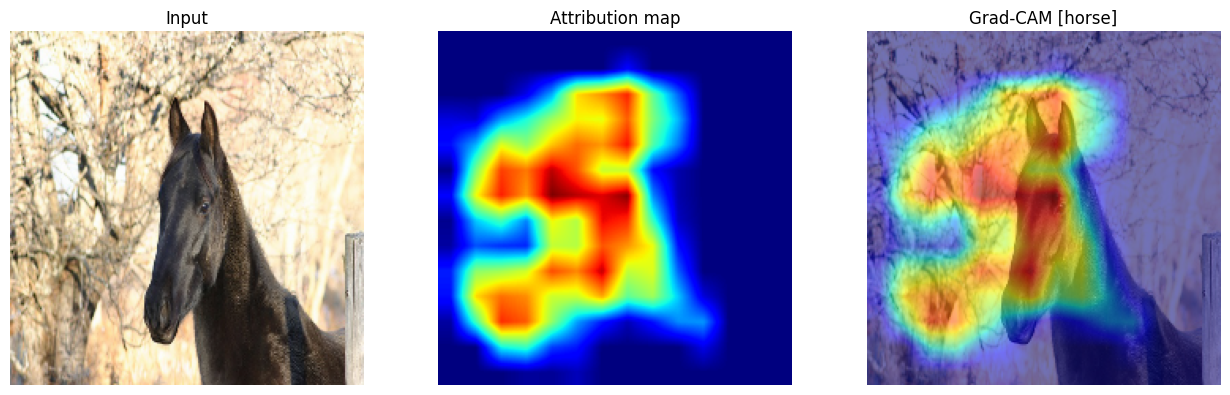

In [34]:
# Grad-CAM on SmallCNN — pick one val image and its top predicted class
sample_img, sample_lbl = val_ds_cls[0]
sample_t = sample_img.unsqueeze(0)

# Temporarily disable inplace ReLUs for Grad-CAM to prevent autograd errors
for module in model_smallcnn_ls.modules():
    if isinstance(module, nn.ReLU):
        module.inplace = False

predicted_prob = torch.sigmoid(model_smallcnn_ls(sample_t.to(DEVICE))).squeeze().detach().cpu()
top_class_idx  = int(predicted_prob.argmax())
top_class_name = list(labels)[top_class_idx]
print(f"Showing Grad-CAM for class: '{top_class_name}' (p={predicted_prob[top_class_idx]:.3f})")

visualize_grad_cam(
    model        = model_smallcnn_ls,
    image_tensor = sample_t,
    class_idx    = top_class_idx,
    target_layer = model_smallcnn_ls.features[-2],  # last conv block
    label_name   = top_class_name,
)

# Restore inplace ReLUs
for module in model_smallcnn_ls.modules():
    if isinstance(module, nn.ReLU):
        module.inplace = True


### 1.2 — CLIP ViT-B/16 V2 (CLS + spatial patch max)

---
#### Why CLIP — and why V2 unexpectedly beat DINOv2

**How we got here:** We wanted to check the Zero-shot performance of CLIP by passing the image and the prompt of each class separately but obviously underperformed, but when there was only class visible it was producing good results, showcasing that it has learned very good representations.
CLIP V1 was tried as a sanity check. It underperformed DINOv2
as expected — the CLS token compresses the entire scene into a single 512-dim vector
optimised for image-text retrieval, not for independently detecting multiple objects. A
single vector encoding "a dog sitting on a sofa next to a person" has to simultaneously
represent three separate positive labels, which is a fundamentally worse inductive bias
for multi-label classification than DINOv2's patch-level features.

**The V2 insight — patch-max pooling:** The patch tokens at CLIP's last transformer block
contain local spatial information even though they were trained to contribute to a global
representation. The maximum activation across all 196 patch tokens for a given class
effectively asks "does *any* patch in this image look like class X?" This converts CLIP's
global matching capacity into a spatial detection capacity.

**Training strategy:** Identical structure to DINOv2 — two phases, same epoch counts,
same learning rates. CLIP uses GELU activations throughout, which are numerically stable in fp16 unlike DINOv2's SwiGLU.

**Loss function — ASL:**

**Honest note on the result:** CLIP V2 slightly outperformed DINOv2 on this dataset and
we did not expect this. CLIP is fundamentally a retrieval model trained with a softmax
contrastive loss that assumes each image has exactly one matching text , it is not designed
for multi-label classification. The likely explanation is specific to VOC: all 20 classes
are extremely common internet objects (dog, car, person, bicycle) that appeared in CLIP's
400M training pairs with precise text labels hundreds of millions of times. CLIP's feature
space is therefore very well organised for exactly these categories. DINOv2's features
are organised by visual similarity rather than semantic category boundaries, which can work
slightly against it when two visually similar classes (cow vs horse, sofa vs chair) need
to be separated. On a dataset with uncommon or visually ambiguous categories, DINOv2 would
likely win. The result should not be generalised as "CLIP is better for multi-label" —
it is a dataset-specific outcome.

In [35]:
class CLIPMultiLabelV2(nn.Module):
    """
    CLIP ViT-B/16 with CLS (512-dim) + max-pooled patch tokens (768-dim) fusion.
    Head input: 1280-dim. Best mAP ~0.90 on VOC2009 val.
    """
    def __init__(self, num_classes=20, freeze_backbone=True, head_dropout=0.3):
        super().__init__()
        self.backbone, _, _ = open_clip.create_model_and_transforms("ViT-B-16", pretrained="openai")
        self.visual = self.backbone.visual
        self._patch_feats = None
        def _hook(module, inp, output):
            self._patch_feats = output[:, 1:, :]   # (B, 196, 768) — patch tokens only
        self.visual.transformer.resblocks[-1].register_forward_hook(_hook)
        if freeze_backbone:
            for p in self.visual.parameters(): p.requires_grad = False
        self.head = nn.Sequential(
            nn.Linear(512 + 768, 512), nn.ReLU(inplace=True),
            nn.Dropout(head_dropout), nn.Linear(512, num_classes),
        )
    def forward(self, x):
        self._patch_feats = None
        cls_feat   = self.backbone.encode_image(x).float()          # (B, 512)
        patch_max  = self._patch_feats.float().max(dim=1).values    # (B, 768)
        return self.head(torch.cat([cls_feat, patch_max], dim=1))
    def unfreeze_last_n_blocks(self, n=4):
        resblocks = self.visual.transformer.resblocks; total = len(resblocks)
        for i in range(total - n, total):
            for p in resblocks[i].parameters(): p.requires_grad = True
        if hasattr(self.visual, "ln_post"):
            for p in self.visual.ln_post.parameters(): p.requires_grad = True
        if self.visual.proj is not None: self.visual.proj.requires_grad = True
        print(f"Unfrozen last {n} CLIP blocks. Trainable: {sum(p.numel() for p in self.parameters() if p.requires_grad):,}")

In [36]:
# ── CLIP V2: load checkpoint or train from scratch ────────────────────────
train_ds_clip     = VOCClassificationDataset(train_df_cls, labels,
                                              transform=cls_train_tf_strong)
train_loader_clip = DataLoader(train_ds_clip, batch_size=BATCH_SIZE, shuffle=True,
                                num_workers=NUM_WORKERS,
                                pin_memory=(DEVICE.type=="cuda"))

EPOCHS_CLIP_V2 = 100
UNFREEZE_V2    = 30
WEIGHTS_CLIP_V2 = "clip_vitb16_v2_patch.pth"

set_seed()
model_clip_v2 = CLIPMultiLabelV2(num_classes=len(labels),
                                   freeze_backbone=True, head_dropout=0.3).to(DEVICE)

_loaded, val_logits_clip_v2, val_targets_clip_v2, \
thresholds_clip_v2, dice_clip_v2 = \
    try_load_cls_checkpoint(
        model          = model_clip_v2,
        weights_path   = WEIGHTS_CLIP_V2,
        val_loader     = val_loader_cls,
        labels         = list(labels),
        is_dinov2_fp32 = False,
        drive_dir      = SAVE_DIR,
    )

if not _loaded:
    _opt_v2   = torch.optim.AdamW(model_clip_v2.head.parameters(),
                                   lr=1e-3, weight_decay=1e-4)
    _sched_v2 = torch.optim.lr_scheduler.CosineAnnealingLR(
                    _opt_v2, T_max=UNFREEZE_V2, eta_min=1e-5)
    _, best_state_clip_v2, \
    val_logits_clip_v2, val_targets_clip_v2 = \
        train_cls_two_phase(
            model_clip_v2, train_loader_clip, val_loader_cls,
            epochs=EPOCHS_CLIP_V2, optimizer=_opt_v2, scheduler=_sched_v2,
            loss_fn=asl_loss_cls, device=DEVICE, log_every=5, name="clip-v2",
            unfreeze_epoch=UNFREEZE_V2, unfreeze_n_blocks=4,
            phase2_backbone_lr=1e-5, phase2_head_lr=5e-4,
            checkpoint_path=WEIGHTS_CLIP_V2)
    model_clip_v2.load_state_dict(best_state_clip_v2)
    torch.save(best_state_clip_v2, WEIGHTS_CLIP_V2)
    save_to_drive(WEIGHTS_CLIP_V2, SAVE_DIR)
    thresholds_clip_v2, dice_clip_v2 = tune_thresholds(
        val_logits_clip_v2, val_targets_clip_v2)

print(f"CLIP V2  mean Dice: {dice_clip_v2.mean():.4f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


open_clip_model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


  [checkpoint] not found at 'clip_vitb16_v2_patch.pth' → training from scratch


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/to

...

[clip-v2|P2] ep  90/100  train 0.0007  val 0.0126  mAP 0.9471


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/to

[clip-v2|P2] ep  95/100  train 0.0006  val 0.0129  mAP 0.9460


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/to

[clip-v2|P2] ep 100/100  train 0.0005  val 0.0128  mAP 0.9455
[clip-v2] best val mAP: 0.9569
  ✓ Saved → /content/drive/MyDrive/Colab_Notebooks/KU_Leuven/CV/clip_vitb16_v2_patch.pth
CLIP V2  mean Dice: 0.9291


#### CLIP V2 — Failure Analysis

**What this does:** Runs the worst-F1 diagnostic on the fine-tuned CLIPMultiLabelV2
model. Because CLIP uses a standard forward pass (no fp32 special-casing needed),
`is_dinov2_fp32=False`.

**Why it is helpful:** CLIP V2's failures are structurally different from
DINOv2 because the two models encode complementary information. CLIP's features
are semantically aligned with language (stronger on semantically distinct
classes, e.g. 'aeroplane' vs 'boat') while DINOv2's are spatially consistent
(stronger on visually distinctive textures). The failure images show which
classes break the language-grounded prior — typically ambiguous objects whose
internet text descriptions are inconsistent (e.g. 'chair' vs 'sofa').


────────────────────────────────────────────────────────────
  Worst-F1 diagnostic → CLIP V2 (patch-max)
────────────────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



  Per-class metrics — CLIP V2 (patch-max)
  Class                F1   Prec    Rec     AP    Sup    TP   FP   FN
  --------------------------------------------------------------------
  sofa              0.000  0.000  0.000  0.904      9     0    0    9  ←
  diningtable       0.182  1.000  0.100  0.891     10     1    0    9  ←
  bottle            0.500  0.455  0.556  0.693      9     5    6    4
  pottedplant       0.571  0.400  1.000  0.912      8     8   12    0
  tvmonitor         0.571  1.000  0.400  0.943     10     4    0    6
  aeroplane         0.625  0.455  1.000  1.000     10    10   12    0
  cat               0.667  0.500  1.000  1.000      9     9    9    0
  chair             0.741  0.769  0.714  0.878     14    10    3    4
  horse             0.750  0.600  1.000  1.000      9     9    6    0
  car               0.786  0.688  0.917  0.960     12    11    5    1
  cow               0.800  0.667  1.000  1.000      6     6    3    0
  train             0.842  0.727  1.000 

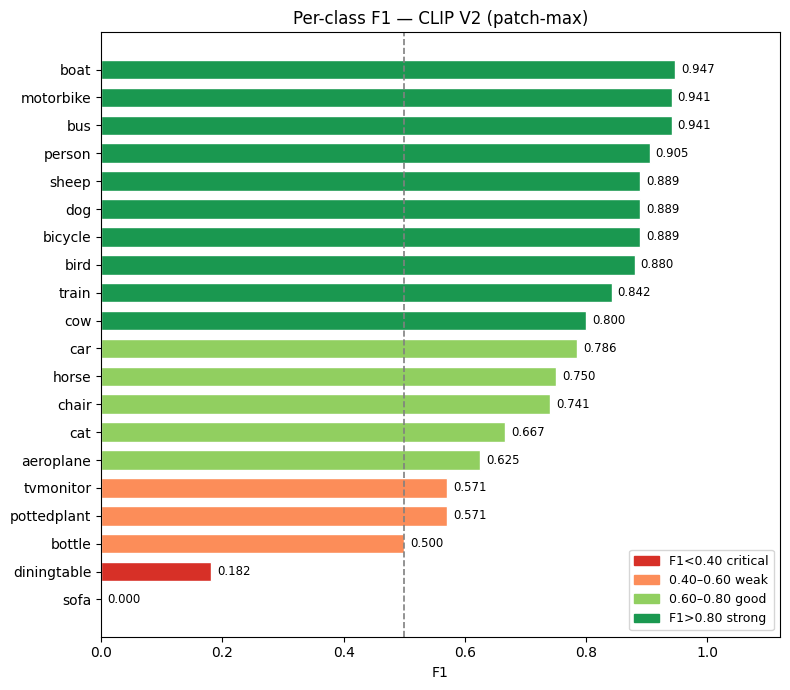

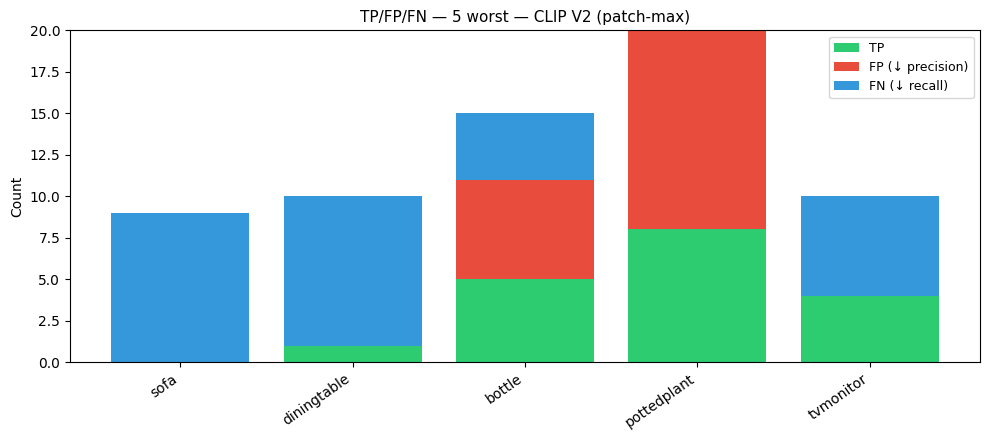


  Failure cases — 2 worst classes:



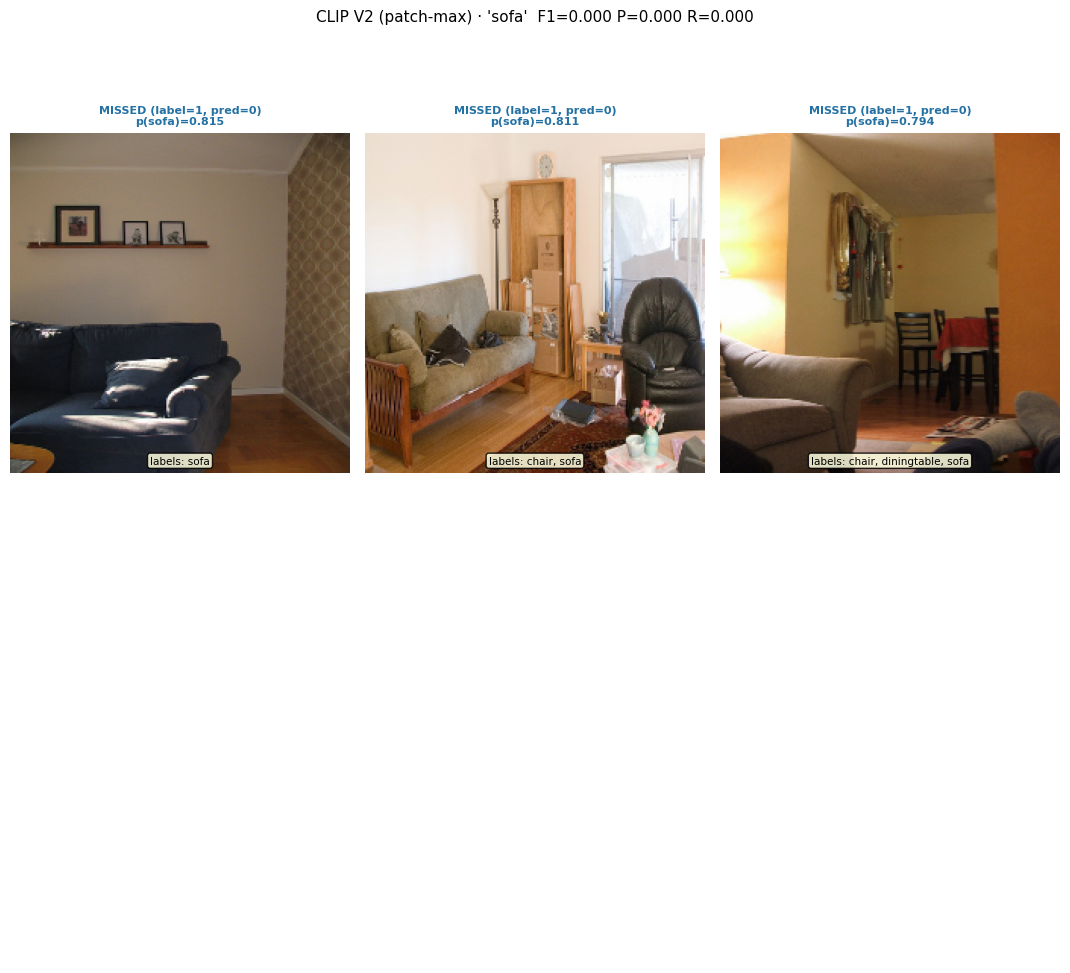

  [sofa]  FN=3  FP=0


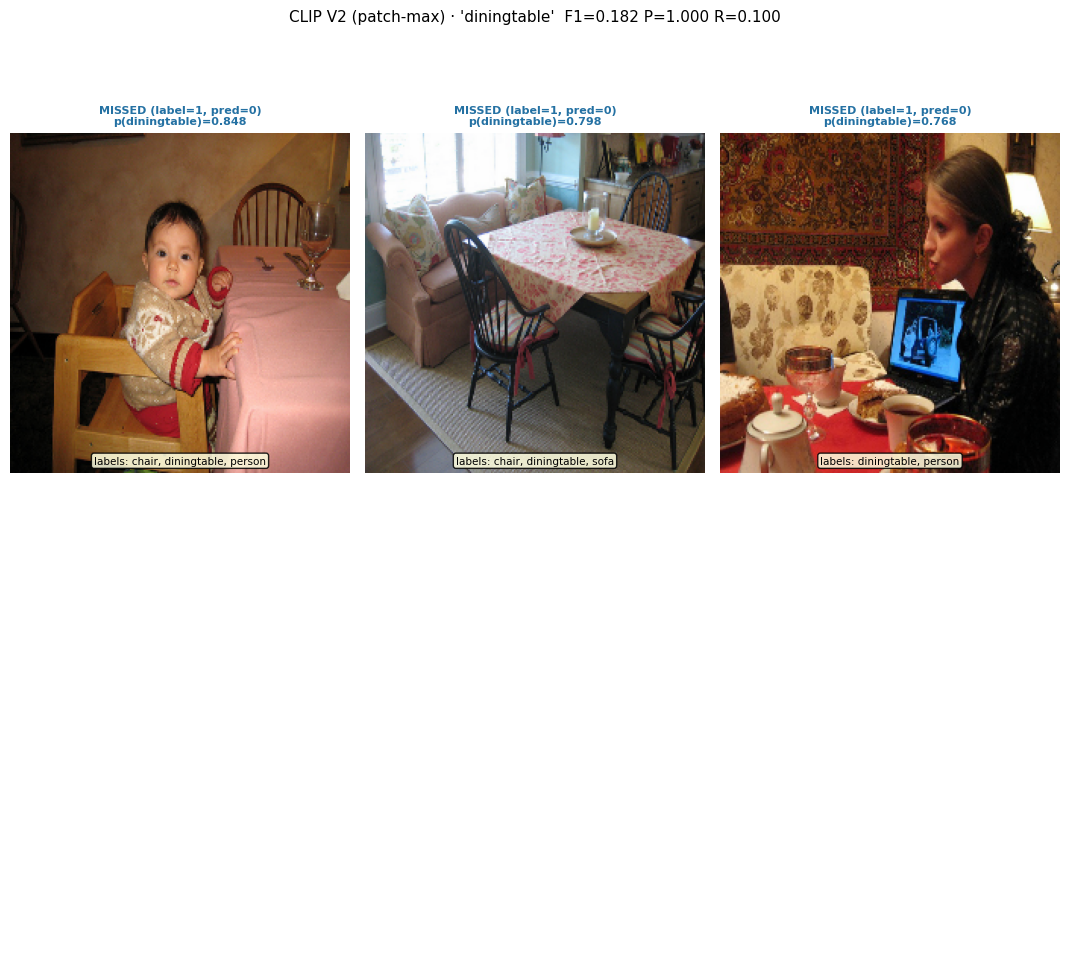

  [diningtable]  FN=3  FP=0


In [37]:
results_clip = analyze_worst_f1(
    model          = model_clip_v2,
    val_loader     = val_loader_cls,
    labels         = list(labels),
    thresholds     = thresholds_clip_v2,
    model_name     = "CLIP V2 (patch-max)",
    is_dinov2_fp32 = False,
    n_worst=2, n_images=3,
)

#### CLIP V2 — Per-Patch Activation Attribution

We tried to visualize the results but we had no luck on it.

#### Cross-model Classification Comparison

**What this does:** Places the per-class F1 scores of all three classification
models (SmallCNN, DINOv2 fp32, CLIP V2) side by side in a grouped bar chart and
prints a table showing which model wins and loses each of the 20 classes.

**Why it is helpful:** The cross-model comparison answers three questions at once:
1. Which classes are hard for *all* models (dataset difficulty, not architecture)?
2. Where does each pretrained backbone add value over the from-scratch baseline?
3. Which classes have divergent errors between DINOv2 and CLIP — indicating that
   the ensemble will gain the most from their complementary representations.

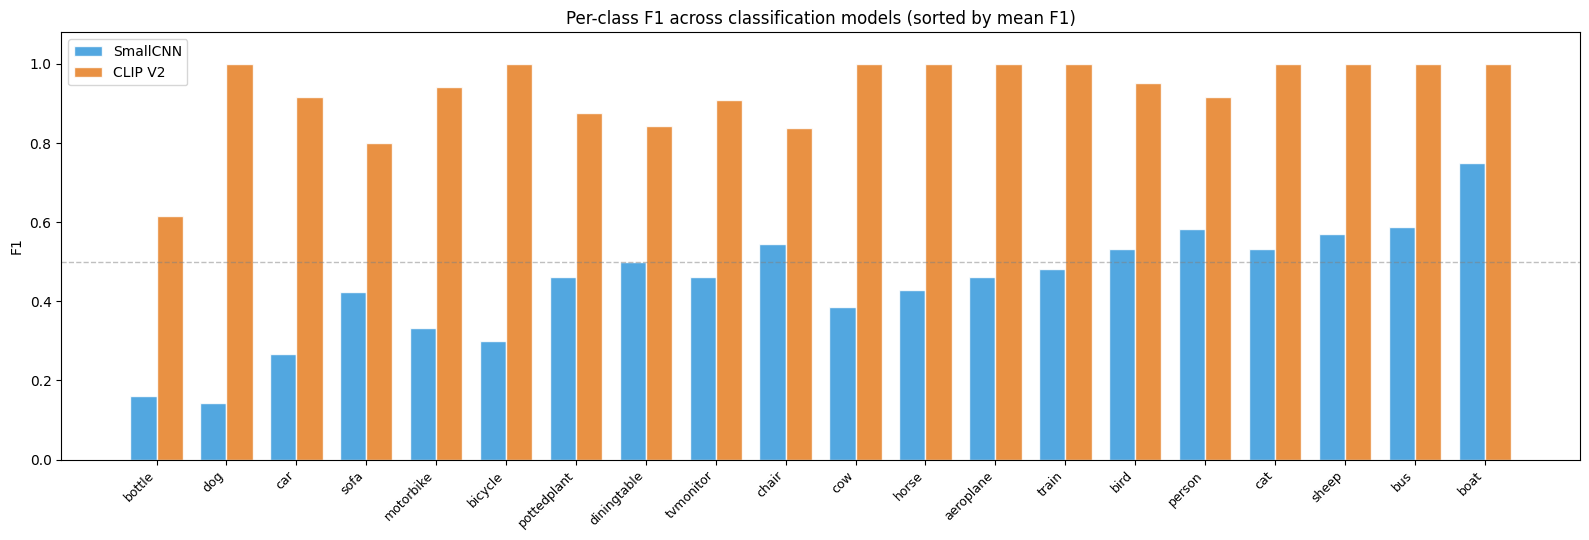


  Class            Best model                 F1   Worst model                F1
  ------------------------------------------------------------------------
  bottle           CLIP V2                 0.615   SmallCNN                0.160
  dog              CLIP V2                 1.000   SmallCNN                0.144
  car              CLIP V2                 0.917   SmallCNN                0.267
  sofa             CLIP V2                 0.800   SmallCNN                0.424
  motorbike        CLIP V2                 0.941   SmallCNN                0.333
  bicycle          CLIP V2                 1.000   SmallCNN                0.300
  pottedplant      CLIP V2                 0.875   SmallCNN                0.462
  diningtable      CLIP V2                 0.842   SmallCNN                0.500
  tvmonitor        CLIP V2                 0.909   SmallCNN                0.462
  chair            CLIP V2                 0.839   SmallCNN                0.545
  cow              CLIP V2       

In [ ]:
compare_cls_models_f1(
    results_dict = {
        "SmallCNN"  : results_smallcnn,
        "CLIP V2"   : results_clip,
    },
    labels = list(labels),
)

In [ ]:
# ── Test set predictions using the ensemble ───────────────────────────────
test_ds_cls = VOCClassificationDatasetTest(test_df, transform=cls_val_tf)
preds_test, probs_test = predict_cls(model_clip_v2, test_ds_cls, thresholds_clip_v2)
test_df.loc[:, labels] = preds_test

print(f"  Shape: {preds_test.shape}")
print(f"  Mean labels per test image : {preds_test.sum(1).mean():.2f}  "
      f"(train: {train_df[labels].sum(1).mean():.2f})")

  Shape: (750, 20)
  Mean labels per test image : 1.43  (train: 1.43)


## Section 2 — Semantic Segmentation

**Models:**
1. **U-Net (from scratch, base=64)** — skip connections handle multi-scale objects
2. **Mask2Former (Base, fine-tuned)** — best on recall/instance-level classes

In [ ]:
# ── Segmentation models ──────────────────────────────────────────────────

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)

class Down(nn.Module):
    """Downsampling step: max pool 2x, then DoubleConv."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x):
        x = self.pool(x)
        x = self.conv(x)
        return x

class Up(nn.Module):
    """Upsampling step: upsample 2x, concatenate skip, then DoubleConv."""
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        # Upsample halves the channels and doubles the spatial size
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2,
                                     kernel_size=2, stride=2)
        # After concatenation: (in_channels // 2) + skip_channels feature maps
        self.conv = DoubleConv(in_channels // 2 + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([skip, x], dim=1)   # concatenate along channel axis
        x = self.conv(x)
        return x

class UNet(nn.Module):
    """U-Net for semantic segmentation, half-width variant.

    Input:  (B, in_channels, H, W) — RGB image, H and W divisible by 16
    Output: (B, num_classes, H, W) — per-pixel class logits
    """
    def __init__(self, in_channels=3, num_classes=21, base_channels=32):
        super().__init__()
        c = base_channels  # 32 for half-width, 64 for full-width

        # Encoder: enc1 keeps spatial size, then 4 Down blocks halve it each
        self.enc1 = DoubleConv(in_channels, c)        # (B, 32, 256, 256)
        self.enc2 = Down(c,      c * 2)               # (B, 64, 128, 128)
        self.enc3 = Down(c * 2,  c * 4)               # (B, 128, 64, 64)
        self.enc4 = Down(c * 4,  c * 8)               # (B, 256, 32, 32)

        # Bottleneck: deepest level, smallest spatial size, most channels
        self.bottleneck = Down(c * 8, c * 16)         # (B, 512, 16, 16)

        # Decoder: 4 Up blocks, each upsamples and merges its matching skip
        self.dec4 = Up(c * 16, c * 8, c * 8)          # (B, 256, 32, 32)
        self.dec3 = Up(c * 8,  c * 4, c * 4)          # (B, 128, 64, 64)
        self.dec2 = Up(c * 4,  c * 2, c * 2)          # (B, 64,  128, 128)
        self.dec1 = Up(c * 2,  c,     c)              # (B, 32,  256, 256)

        # Final 1x1 conv: project 32 channels to 21 class logits
        self.head = nn.Conv2d(c, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder path: save each output for use as a skip connection
        s1 = self.enc1(x)         # (B, 32, 256, 256)
        s2 = self.enc2(s1)        # (B, 64, 128, 128)
        s3 = self.enc3(s2)        # (B, 128, 64, 64)
        s4 = self.enc4(s3)        # (B, 256, 32, 32)

        # Bottleneck
        b = self.bottleneck(s4)   # (B, 512, 16, 16)

        # Decoder path: each Up block consumes the deeper feature + matching skip
        d4 = self.dec4(b,  s4)    # (B, 256, 32, 32)
        d3 = self.dec3(d4, s3)    # (B, 128, 64, 64)
        d2 = self.dec2(d3, s2)    # (B, 64,  128, 128)
        d1 = self.dec1(d2, s1)    # (B, 32,  256, 256)

        return self.head(d1)      # (B, 21, 256, 256)

In [ ]:
# ── Seg training loops ────────────────────────────────────────────────────

def _seg_fg_dice(preds, masks, num_classes=NUM_CLASSES):
    """Fast FG mean Dice from cpu tensors — used for Dice-based checkpointing."""
    conf = torch.zeros(num_classes, num_classes, dtype=torch.int64)
    mf = masks.view(-1).long(); pf = preds.view(-1).long(); valid = mf != 255
    conf += torch.bincount(num_classes*mf[valid]+pf[valid],
                            minlength=num_classes**2).reshape(num_classes,num_classes)
    tp = torch.diag(conf).float(); fp = (conf.sum(0)-tp).float(); fn = (conf.sum(1)-tp).float()
    dice = (2*tp/(2*tp+fp+fn+1e-12)).numpy()
    return float(np.mean(dice[1:]))


def train_model(model, train_loader, val_loader, optimizer, scheduler,
                epochs, save_name, target_effective_batch=16, save_dir=SAVE_DIR):
    """
    Standard seg training loop.
    (Manolis): checkpoint on val FG Dice, not val loss.
    Dice is the competition metric; loss can decrease while Dice plateaus
    (the model improves its probability calibration but not its binary masks).
    Saving on Dice gives the checkpoint that actually performs best on the metric.
    """
    physical_batch     = train_loader.batch_size
    accumulation_steps = max(1, target_effective_batch // physical_batch)
    scaler             = torch.amp.GradScaler("cuda")
    best_val_dice      = -1.0
    train_losses, val_losses, val_dices = [], [], []
    print(f"--- Training {save_name}  (accum={accumulation_steps}) ---")
    for epoch in range(epochs):
        model.train(); train_loss = 0.0; optimizer.zero_grad()
        for i, (images, masks) in enumerate(train_loader):
            images = images.to(DEVICE, non_blocking=True); masks = masks.to(DEVICE, non_blocking=True)
            with torch.amp.autocast("cuda"):
                loss = criterion_seg(model(images), masks) / accumulation_steps
            scaler.scale(loss).backward()
            if (i+1) % accumulation_steps == 0 or (i+1) == len(train_loader):
                scaler.step(optimizer); scaler.update(); optimizer.zero_grad()
            train_loss += loss.item() * accumulation_steps * images.size(0)
        train_loss /= len(train_loader.dataset); scheduler.step()
        model.eval(); val_loss = 0.0; all_preds, all_masks = [], []
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(DEVICE), masks.to(DEVICE)
                with torch.amp.autocast("cuda"):
                    logits = model(images)
                    val_loss += criterion_seg(logits, masks).item() * images.size(0)
                all_preds.append(logits.argmax(1).cpu()); all_masks.append(masks.cpu())
        val_loss /= len(val_loader.dataset)
        val_dice = _seg_fg_dice(torch.cat(all_preds), torch.cat(all_masks))
        train_losses.append(train_loss); val_losses.append(val_loss); val_dices.append(val_dice)
        marker = " ✓" if val_dice > best_val_dice else ""
        print(f"Epoch {epoch+1:03d}/{epochs} | train {train_loss:.4f} | val {val_loss:.4f} | Dice {val_dice:.4f}{marker}")
        if val_dice > best_val_dice:
            best_val_dice = val_dice; local_path = f"{save_name}.pt"
            torch.save(model.state_dict(), local_path); save_to_drive(local_path, save_dir)
    fig, axes = plt.subplots(1,2,figsize=(14,4))
    axes[0].plot(train_losses,label="Train"); axes[0].plot(val_losses,label="Val",ls="--")
    axes[0].set_title(f"Loss — {save_name}"); axes[0].legend(); axes[0].grid(alpha=0.4)
    axes[1].plot(val_dices,color="green"); axes[1].set_title(f"Val FG Dice — {save_name}"); axes[1].grid(alpha=0.4)
    plt.tight_layout(); plt.show()
    return train_losses, val_losses


@torch.no_grad()
def validate_unet_fullres(model, train_df, val_indices, num_classes=NUM_CLASSES):
    """
    Validate U-Net at NATIVE image resolution (from Manolis).

    Fixed-crop validation (512×512) underestimates quality for objects near
    image edges — SEG EDA 4 showed strong centre bias, meaning edge objects
    are frequently cropped out of the val loader. Full-resolution evaluation
    pads each image to a multiple of 16 (U-Net stride constraint), runs
    inference at native size, crops the padding off, and accumulates a
    confusion matrix. The resulting Dice is directly comparable to test-set
    performance since the test images are also evaluated at native resolution.
    """
    model.eval()
    MEAN = np.array([0.485,0.456,0.406],dtype=np.float32)
    STD  = np.array([0.229,0.224,0.225],dtype=np.float32)
    conf = torch.zeros(num_classes, num_classes, dtype=torch.int64)
    for i in val_indices:
        img = train_df["img"].iloc[i]; seg = train_df["seg"].iloc[i]
        H, W = img.shape[:2]
        pad_h = (16 - H%16)%16
        pad_w = (16 - W%16)%16
        x = img.astype(np.float32)/255.0
        x = (x - MEAN)/STD
        x = np.pad(x, ((0,pad_h),(0,pad_w),(0,0)))
        x = torch.from_numpy(x).permute(2,0,1).unsqueeze(0).float().to(DEVICE)
        logits = model(x)[:,:,:H,:W]
        preds  = logits.argmax(1).squeeze(0).cpu()
        target = torch.from_numpy(seg.astype(np.int64))
        valid  = target.view(-1) != 255
        mf, pf = target.view(-1)[valid], preds.view(-1)[valid]
        conf  += torch.bincount(num_classes*mf+pf, minlength=num_classes**2).reshape(num_classes,num_classes)
    tp = torch.diag(conf).float(); fp=(conf.sum(0)-tp).float(); fn=(conf.sum(1)-tp).float()
    iou  = (tp/(tp+fp+fn+1e-12)).numpy()
    dice = (2*tp/(2*tp+fp+fn+1e-12)).numpy()
    print("\nFull-resolution validation (native image size):")
    for c,name in enumerate(VOC_CLASSES):
        if c > 0:
            print(f"  {c:<2} {name:<15} IoU={iou[c]:.4f}  Dice={dice[c]:.4f}")
    fg = float(np.mean(dice[1:]))
    print(f"\n  mIoU={np.mean(iou):.4f}   FG Dice (full-res)={fg:.4f}  <- test-comparable")
    return fg, iou, dice



def train_two_phase(model, train_loader, val_loader, save_name,
                     phase1_epochs=15, phase2_epochs=35, head_lr=1e-3, backbone_lr=5e-5,
                     target_effective_batch=16, save_dir=SAVE_DIR):
    physical_batch = train_loader.batch_size
    accumulation_steps = max(1, target_effective_batch // physical_batch)
    best_val_loss = float("inf"); all_train, all_val = [], []
    def _run_phase(opt, sched, n_epochs, phase_name):
        nonlocal best_val_loss
        scaler = torch.amp.GradScaler("cuda")
        for epoch in range(n_epochs):
            model.train(); train_loss = 0.0; opt.zero_grad()
            for i, (images, masks) in enumerate(train_loader):
                images = images.to(DEVICE, non_blocking=True); masks = masks.to(DEVICE, non_blocking=True)
                with torch.amp.autocast("cuda"):
                    loss = criterion_seg(model(images), masks) / accumulation_steps
                scaler.scale(loss).backward()
                if (i+1) % accumulation_steps == 0 or (i+1) == len(train_loader):
                    scaler.unscale_(opt); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(opt); scaler.update(); opt.zero_grad()
                train_loss += loss.item() * accumulation_steps * images.size(0)
            train_loss /= len(train_loader.dataset)
            model.eval(); val_loss = 0.0
            with torch.no_grad():
                for images, masks in val_loader:
                    images, masks = images.to(DEVICE), masks.to(DEVICE)
                    with torch.amp.autocast("cuda"):
                        val_loss += criterion_seg(model(images), masks).item() * images.size(0)
            val_loss /= len(val_loader.dataset); all_train.append(train_loss); all_val.append(val_loss)
            print(f"[{phase_name}] ep {epoch+1:03d}/{n_epochs}  train {train_loss:.4f}  val {val_loss:.4f}")
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                local_path = f"{save_name}.pt"
                torch.save(model.state_dict(), local_path)
                # save_to_drive(local_path, save_dir)
            if sched is not None: sched.step()
    print(f"{'='*50}\n[{save_name}] PHASE 1 — head only ({phase1_epochs} epochs)\n{'='*50}")
    model.freeze_encoder()
    opt1   = torch.optim.AdamW(model.head_parameters(), lr=head_lr, weight_decay=1e-4)
    sched1 = torch.optim.lr_scheduler.CosineAnnealingLR(opt1, T_max=phase1_epochs, eta_min=1e-5)
    _run_phase(opt1, sched1, phase1_epochs, "P1")
    print(f"{'='*50}\n[{save_name}] PHASE 2 — full model ({phase2_epochs} epochs)\n{'='*50}")
    model.unfreeze_encoder()
    opt2 = torch.optim.AdamW([
        {"params": model.backbone_parameters(), "lr": backbone_lr,   "weight_decay": 1e-4},
        {"params": model.head_parameters(),     "lr": head_lr * 0.5, "weight_decay": 1e-4},
    ])
    sched2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=phase2_epochs, eta_min=1e-6)
    _run_phase(opt2, sched2, phase2_epochs, "P2")
    plt.figure(figsize=(12,4)); plt.plot(all_train,label="Train"); plt.plot(all_val,label="Val",ls="--")
    plt.axvline(phase1_epochs-0.5, color="grey", ls=":", label="Phase 2 start")
    plt.title(f"Loss — {save_name}"); plt.legend(); plt.grid(alpha=0.4); plt.tight_layout(); plt.show()
    return all_train, all_val

In [ ]:
# ── Mask2Former helpers ───────────────────────────────────────────────────

def prepare_mask2former_targets(masks_tensor, ignore_index=255):
    mask_labels, class_labels = [], []
    for mask in masks_tensor:
        classes = torch.unique(mask); classes = classes[(classes != ignore_index)]
        b_masks, b_classes = [], []
        for c in classes:
            b_masks.append(mask == c); b_classes.append(c)
        if not b_masks:
            b_masks.append(torch.zeros_like(mask, dtype=torch.bool))
            b_classes.append(torch.tensor(0, device=mask.device))
        mask_labels.append(torch.stack(b_masks).float())
        class_labels.append(torch.stack(b_classes).long())
    return mask_labels, class_labels


def train_mask2former(model, train_loader, val_loader, optimizer, scheduler,
                       epochs, save_name, target_effective_batch=16, save_dir=SAVE_DIR):
    """
    Mask2Former native training loop.

    (Manolis principle): checkpoint on val FG Dice, not val loss.
    Mask2Former's built-in Hungarian matching loss continues decreasing
    after predicted masks stop improving — it fine-tunes assignment costs
    and logit calibration without changing binary predictions. The checkpoint
    with the lowest loss is often NOT the one with the best Dice.

    Mask2Former's
    outputs.loss is its own internal loss (mask BCE + mask Dice + class CE
    weighted by bipartite matching). Replacing it would bypass the Hungarian
    matching mechanism and break the query-based architecture entirely.
    """

    _proc = _M2FProc(ignore_index=255, do_resize=False, do_rescale=False, do_normalize=False)
    accumulation_steps = max(1, target_effective_batch // train_loader.batch_size)
    scaler = torch.amp.GradScaler("cuda")
    best_val_dice = -1.0
    train_losses, val_losses, val_dices = [], [], []

    for epoch in range(epochs):
        # ── Train ─────────────────────────────────────────────────
        model.train(); train_loss = 0.0; optimizer.zero_grad()
        for i, (images, masks) in enumerate(train_loader):
            images = images.to(DEVICE, non_blocking=True)
            masks  = masks.to(DEVICE, non_blocking=True)
            ml, cl = prepare_mask2former_targets(masks)
            with torch.amp.autocast("cuda"):
                loss = model(pixel_values=images, mask_labels=ml,
                             class_labels=cl).loss / accumulation_steps
            scaler.scale(loss).backward()
            if (i+1) % accumulation_steps == 0 or (i+1) == len(train_loader):
                scaler.step(optimizer); scaler.update(); optimizer.zero_grad()
            train_loss += loss.item() * accumulation_steps * images.size(0)
        train_loss /= len(train_loader.dataset); scheduler.step()

        # ── Validate + compute Dice ────────────────────────────────
        model.eval(); val_loss = 0.0; all_preds, all_masks_cpu = [], []
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(DEVICE), masks.to(DEVICE)
                ml, cl = prepare_mask2former_targets(masks)
                with torch.amp.autocast("cuda"):
                    outputs = model(pixel_values=images, mask_labels=ml, class_labels=cl)
                val_loss += outputs.loss.item() * images.size(0)
                preds = torch.stack(_proc.post_process_semantic_segmentation(
                    outputs, target_sizes=[masks.shape[1:]]*len(images))).cpu()
                all_preds.append(preds); all_masks_cpu.append(masks.cpu())
        val_loss /= len(val_loader.dataset)
        val_dice  = _seg_fg_dice(torch.cat(all_preds), torch.cat(all_masks_cpu))
        train_losses.append(train_loss); val_losses.append(val_loss); val_dices.append(val_dice)
        marker = " ✓" if val_dice > best_val_dice else ""
        print(f"Epoch {epoch+1:03d}/{epochs} | train {train_loss:.4f} | "
              f"val {val_loss:.4f} | FG Dice {val_dice:.4f}{marker}")

        if val_dice > best_val_dice:
            best_val_dice = val_dice; local_path = f"{save_name}.pt"
            torch.save(model.state_dict(), local_path); save_to_drive(local_path, save_dir)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(train_losses, label="Train"); axes[0].plot(val_losses, label="Val", ls="--")
    axes[0].set_title(f"Loss — {save_name}"); axes[0].legend(); axes[0].grid(alpha=0.4)
    axes[1].plot(val_dices, color="green")
    axes[1].set_title(f"Val FG Dice — {save_name}"); axes[1].grid(alpha=0.4)
    plt.tight_layout(); plt.show()
    return train_losses, val_losses

In [ ]:
# ── Evaluation helpers ────────────────────────────────────────────────────

def evaluate_metrics(model, val_loader, save_name, num_classes=NUM_CLASSES):
    model.load_state_dict(torch.load(f"{save_name}.pt", weights_only=True, map_location=DEVICE))
    model.eval(); conf = torch.zeros(num_classes, num_classes, dtype=torch.int64)
    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc=f"Eval {save_name}"):
            preds = torch.argmax(model(images.to(DEVICE)), dim=1)
            mf, pf = masks.view(-1).long().cpu(), preds.view(-1).long().cpu(); valid = mf != 255
            conf += torch.bincount(num_classes * mf[valid] + pf[valid], minlength=num_classes**2).reshape(num_classes, num_classes)
    tp = torch.diag(conf); fp = conf.sum(0)-tp; fn = conf.sum(1)-tp
    iou  = (tp.float()/(tp+fp+fn+1e-12)).numpy()
    dice = (2*tp.float()/(2*tp+fp+fn+1e-12)).numpy()
    print(f"\n--- {save_name} ---")
    for i, name in enumerate(VOC_CLASSES): print(f"  {i:<2} {name:<15} IoU={iou[i]:.4f}  Dice={dice[i]:.4f}")
    mfg_dice = float(np.mean(dice[1:]))
    print(f"\n  mIoU={np.mean(iou):.4f}  mean Dice (fg)={mfg_dice:.4f}  ← key metric")
    return float(np.mean(iou)), mfg_dice


def evaluate_mask2former(model, val_loader, save_name, num_classes=NUM_CLASSES):
    model.load_state_dict(torch.load(f"{save_name}.pt", weights_only=True, map_location=DEVICE))
    model.eval()
    processor = Mask2FormerImageProcessor(ignore_index=255, do_resize=False, do_rescale=False, do_normalize=False)
    conf = torch.zeros(num_classes, num_classes, dtype=torch.int64)
    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc=f"Eval {save_name}"):
            outputs = model(pixel_values=images.to(DEVICE))
            preds   = torch.stack(processor.post_process_semantic_segmentation(outputs, target_sizes=[masks.shape[1:]]*len(images))).to(DEVICE)
            mf, pf  = masks.view(-1).long().cpu(), preds.view(-1).long().cpu(); valid = mf != 255
            conf   += torch.bincount(num_classes * mf[valid] + pf[valid], minlength=num_classes**2).reshape(num_classes, num_classes)
    tp = torch.diag(conf); fp = conf.sum(0)-tp; fn = conf.sum(1)-tp
    dice = (2*tp.float()/(2*tp+fp+fn+1e-12)).numpy(); iou = (tp.float()/(tp+fp+fn+1e-12)).numpy()
    print(f"\n--- {save_name} ---")
    for i, name in enumerate(VOC_CLASSES): print(f"  {i:<2} {name:<15} IoU={iou[i]:.4f}  Dice={dice[i]:.4f}")
    mfg = float(np.mean(dice[1:]))
    print(f"\n  mIoU={np.mean(iou):.4f}  mean Dice (fg)={mfg:.4f}")
    return float(np.mean(iou)), mfg


def visualize_predictions(model, val_loader, save_name, num_examples=2):
    model.load_state_dict(torch.load(f"{save_name}.pt", weights_only=True, map_location=DEVICE))
    model.eval()
    images, masks = next(iter(val_loader)); n = min(num_examples, len(images))
    with torch.no_grad():preds = torch.argmax(model(images.to(DEVICE)), dim=1).cpu().numpy()
    imgs_np = images.numpy(); masks_np = masks.numpy().copy()
    preds[masks_np==255]=0; masks_np[masks_np==255]=0
    cmap = plt.get_cmap("nipy_spectral"); fig, axs = plt.subplots(n, 3, figsize=(15, 5*n))
    if n == 1: axs = axs[np.newaxis, :]
    for i in range(n):
        img = np.clip(np.transpose(imgs_np[i]*np.array([0.229,0.224,0.225]).reshape(3,1,1)+np.array([0.485,0.456,0.406]).reshape(3,1,1),(1,2,0))*255,0,255).astype(np.uint8)
        axs[i,0].imshow(img); axs[i,0].set_title("Input"); axs[i,0].axis("off")
        axs[i,1].imshow(masks_np[i], vmin=0, vmax=20, cmap=cmap); axs[i,1].set_title("GT"); axs[i,1].axis("off")
        axs[i,2].imshow(preds[i],    vmin=0, vmax=20, cmap=cmap); axs[i,2].set_title(save_name); axs[i,2].axis("off")
        patches = [mpatches.Patch(color=cmap(c/20),label=VOC_CLASSES[c]) for c in np.unique(preds[i])]
        axs[i,2].legend(handles=patches, bbox_to_anchor=(1.05,1), loc="upper left", fontsize=8)
    plt.tight_layout(); plt.show()


def visualize_mask2former(model, val_loader, save_name="best_mask2former", num_examples=2):
    model.load_state_dict(torch.load(SAVE_DIR+f"{save_name}.pt", weights_only=True, map_location=DEVICE))
    model.eval()
    processor = Mask2FormerImageProcessor(ignore_index=255, do_resize=False, do_rescale=False, do_normalize=False)
    images, masks = next(iter(val_loader)); n = min(num_examples, len(images))
    with torch.no_grad():
        outputs = model(pixel_values=images.to(DEVICE))
        preds   = torch.stack(processor.post_process_semantic_segmentation(outputs, target_sizes=[masks.shape[1:]]*len(images))).cpu().numpy()
    imgs_np = images.numpy(); masks_np = masks.numpy().copy()
    preds[masks_np==255]=0; masks_np[masks_np==255]=0
    cmap = plt.get_cmap("nipy_spectral"); fig, axs = plt.subplots(n, 3, figsize=(15, 5*n))
    if n == 1: axs = axs[np.newaxis, :]
    for i in range(n):
        img = np.clip(np.transpose(imgs_np[i]*np.array([0.229,0.224,0.225]).reshape(3,1,1)+np.array([0.485,0.456,0.406]).reshape(3,1,1),(1,2,0))*255,0,255).astype(np.uint8)
        axs[i,0].imshow(img); axs[i,0].set_title("Input"); axs[i,0].axis("off")
        axs[i,1].imshow(masks_np[i], vmin=0, vmax=20, cmap=cmap); axs[i,1].set_title("GT"); axs[i,1].axis("off")
        axs[i,2].imshow(preds[i],    vmin=0, vmax=20, cmap=cmap); axs[i,2].set_title(save_name); axs[i,2].axis("off")
        patches = [mpatches.Patch(color=cmap(c/20),label=VOC_CLASSES[c]) for c in np.unique(preds[i])]
        axs[i,2].legend(handles=patches, bbox_to_anchor=(1.05,1), loc="upper left", fontsize=8)
    plt.tight_layout(); plt.show()

### 2.1 — U-Net from Scratch

#### Architecture
We will use **U-Net** (Ronneberger et al., 2015) trained from scratch with random initialization. The choice is motivated specifically by the constraints of this task:

- **Designed for small datasets without pretraining.** U-Net was originally proposed for biomedical segmentation with very few training images, where ImageNet-pretrained encoders were not applicable. Our training set of 749 images sits in exactly this regime, and the literature consistently identifies U-Net as a strong default for from-scratch segmentation on small datasets.

- **Skip connections preserve spatial detail.** U-Net concatenates encoder feature maps to the decoder at every resolution level, so fine spatial information (object boundaries, thin structures) is not lost through the bottleneck. This matters more when training from scratch, since the encoder cannot rely on rich pretrained low-level features.

- **Fully convolutional.** The architecture contains only convolutions, batch norm, ReLU, pooling, and upsampling, there are no fully-connected layers. This means the network can be trained on 256×256 random crops and applied to test images at their full native resolution at inference time.


#### Loss Function
We train with a combined loss: per-pixel cross-entropy plus a Dice loss on the foreground classes.

**Cross-entropy** measures how confident the model is in the correct class at each pixel, treating each pixel as an independent classification. It produces a strong, stable gradient even at random initialization, which is essential to get training off the ground.

**Dice loss** measures region overlap between the predicted and true regions of each class, computed as `1 - (2·|A∩B| / (|A|+|B|))`. It is the soft form of the Dice score we use for evaluation, so it directly aligns the training objective with the metric we're judged on. Unlike cross-entropy, Dice resists the "predict the dominant class everywhere" failure mode common on imbalanced data.

We make two design choices in our Dice term:

- **Average only over classes that appear in the current batch.** If a class has no ground-truth pixels in the batch, its Dice is undefined (numerically near-zero from smoothing). Including these absent classes in the mean would heavily penalize the model for "failing" to predict classes that aren't there, which is incorrect. We discovered this experimentally, a one-batch overfit test plateaued at 0.72 instead of approaching 0 until we added this fix.
- **Exclude background from the Dice average.** Background dominates 78% of pixels and is easy to segment, so its Dice score is typically ~0.85 even for a poor model. Including it inflates the metric and reduces the loss signal pushing improvements on foreground classes. Cross-entropy still attends to background normally, so we don't lose the supervision.

Combining the two losses with equal weight gives us the best of both: cross-entropy provides a stable per-pixel learning signal early in training, and Dice nudges predictions toward overlap-correct foreground regions throughout. This is the standard recipe in modern segmentation pipelines.

#### Training
We train for 100 epochs with Adam (LR 3×10⁻⁴, weight decay 1×10⁻⁴) and a cosine learning-rate schedule that decays the LR smoothly toward zero over the run. The model is the full-width U-Net (base 64) with random initialization.

**Loss weighting.** We use the combined CE + Dice loss with `dice_weight=5.0`. CE on its own learned background and the most common foreground classes (person, car, bus) but failed to predict the rest. Upweighting the Dice term shifts the gradient signal toward foreground region overlap, which is where the harder learning happens.

**Full-resolution validation.** Rather than applying the same 256×256 center-crop pipeline as during training, we evaluate one image at a time at its native resolution. Each image is padded to a multiple of 16 (the constraint imposed by U-Net's four downsampling steps), forwarded through the model, and the padded region is cropped off the prediction before computing loss and metrics. This is slower than batched evaluation, but the resulting val Dice is directly comparable to test-set performance. Center-cropping during validation would systematically underestimate quality on images where the object isn't in the center.

**Checkpointing on val Dice, not val loss.** Dice is the metric we are scored on, and the two can disagree: val loss may keep dropping while val Dice plateaus, or vice versa. We save the model whenever val Dice reaches a new high.

U-Net params: 31,038,933
  [checkpoint] Loading from '/content/drive/MyDrive/Colab_Notebooks/KU_Leuven/CV/best_unet.pt' ...
  [checkpoint] Model ready.


Eval /content/drive/MyDrive/Colab_Notebooks/KU_Leuven/CV/best_unet: 100%|██████████| 18/18 [00:14<00:00,  1.26it/s]



--- /content/drive/MyDrive/Colab_Notebooks/KU_Leuven/CV/best_unet ---
  0  background      IoU=0.0070  Dice=0.0138
  1  aeroplane       IoU=0.0105  Dice=0.0208
  2  bicycle         IoU=0.0085  Dice=0.0168
  3  bird            IoU=0.0086  Dice=0.0170
  4  boat            IoU=0.0078  Dice=0.0154
  5  bottle          IoU=0.0009  Dice=0.0019
  6  bus             IoU=0.0107  Dice=0.0212
  7  car             IoU=0.0132  Dice=0.0260
  8  cat             IoU=0.0494  Dice=0.0941
  9  chair           IoU=0.0232  Dice=0.0453
  10 cow             IoU=0.0000  Dice=0.0000
  11 diningtable     IoU=0.0044  Dice=0.0088
  12 dog             IoU=0.0015  Dice=0.0031
  13 horse           IoU=0.0034  Dice=0.0067
  14 motorbike       IoU=0.0360  Dice=0.0694
  15 person          IoU=0.0537  Dice=0.1020
  16 pottedplant     IoU=0.0062  Dice=0.0123
  17 sheep           IoU=0.0173  Dice=0.0340
  18 sofa            IoU=0.0004  Dice=0.0008
  19 train           IoU=0.0051  Dice=0.0101
  20 tvmonitor       IoU=0.00

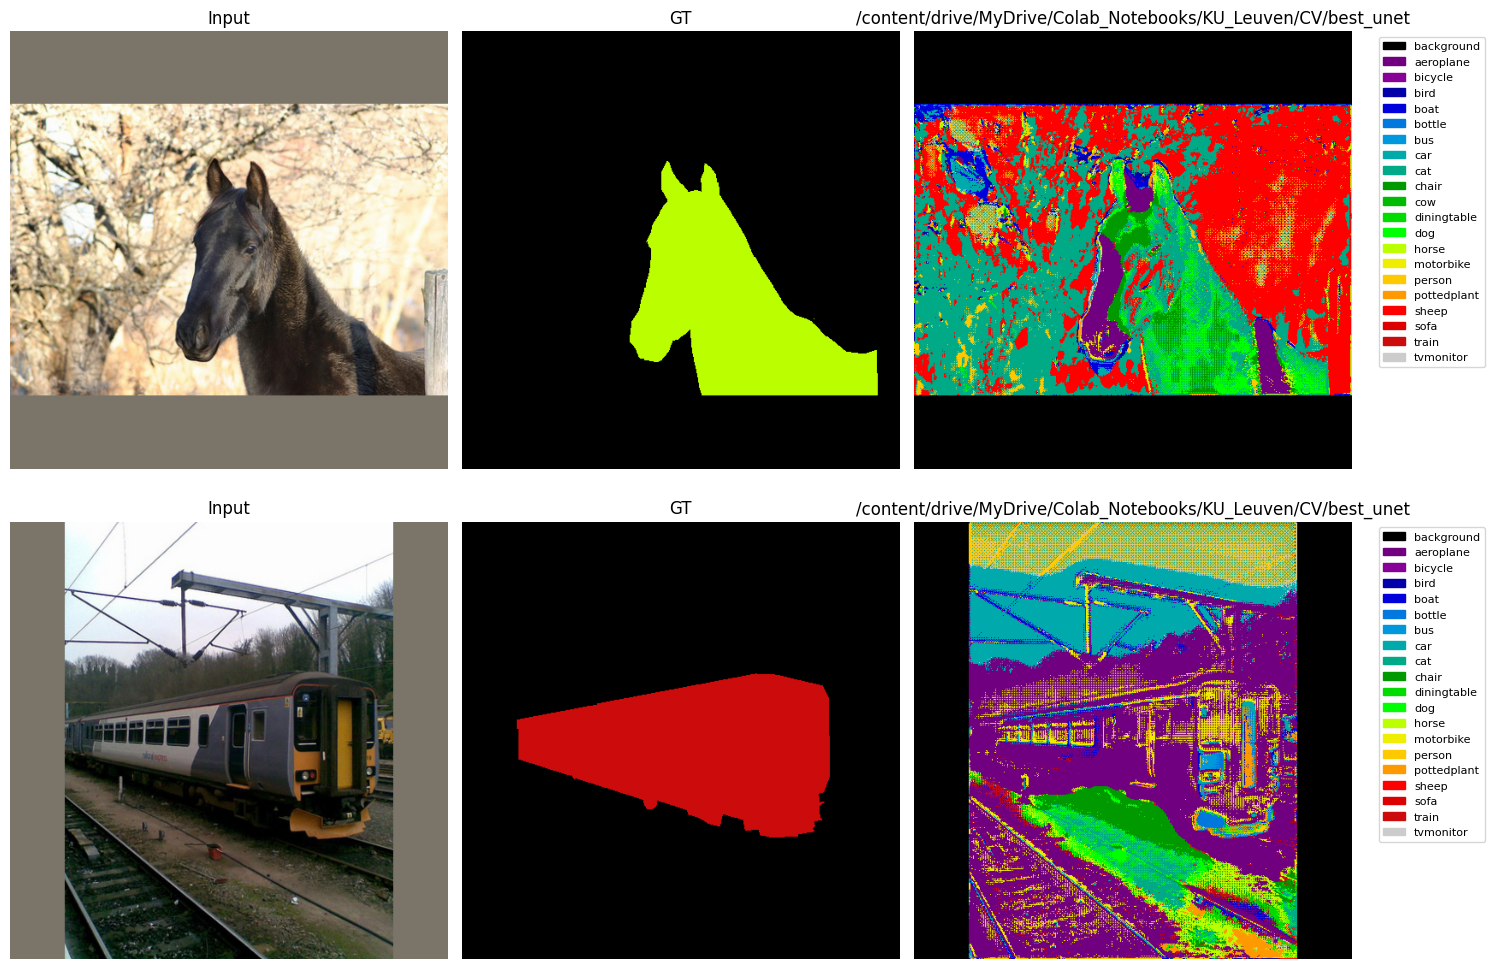


Full-resolution validation (native image size):
  1  aeroplane       IoU=0.0099  Dice=0.0197
  2  bicycle         IoU=0.0071  Dice=0.0140
  3  bird            IoU=0.0105  Dice=0.0207
  4  boat            IoU=0.0076  Dice=0.0152
  5  bottle          IoU=0.0006  Dice=0.0012
  6  bus             IoU=0.0119  Dice=0.0235
  7  car             IoU=0.0115  Dice=0.0227
  8  cat             IoU=0.0596  Dice=0.1125
  9  chair           IoU=0.0189  Dice=0.0371
  10 cow             IoU=0.0000  Dice=0.0000
  11 diningtable     IoU=0.0039  Dice=0.0077
  12 dog             IoU=0.0003  Dice=0.0005
  13 horse           IoU=0.0071  Dice=0.0142
  14 motorbike       IoU=0.0355  Dice=0.0685
  15 person          IoU=0.0515  Dice=0.0979
  16 pottedplant     IoU=0.0032  Dice=0.0064
  17 sheep           IoU=0.0115  Dice=0.0227
  18 sofa            IoU=0.0003  Dice=0.0006
  19 train           IoU=0.0044  Dice=0.0087
  20 tvmonitor       IoU=0.0049  Dice=0.0098

  mIoU=0.0127   FG Dice (full-res)=0.0252  <- test

16824

In [ ]:
# ── U-Net: load checkpoint or train from scratch ──────────────────────────
torch.cuda.empty_cache(); gc.collect()
train_loader, val_loader = get_dataloaders("unet", batch_size=8)
model_unet = UNet(in_channels=3, num_classes=21, base_channels=64).to(DEVICE)
print(f"U-Net params: {sum(p.numel() for p in model_unet.parameters()):,}")

_loaded = try_load_seg_checkpoint(model_unet, "best_unet.pt", drive_dir=SAVE_DIR)
NUM_EPOCHS = 50 # we wanted to train longer but its too expensive and it does not get that much better results
if not _loaded:
    optimizer_unet = torch.optim.Adam(model_unet.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler_unet = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer_unet, T_max=NUM_EPOCHS)
    train_model(model_unet, train_loader, val_loader,
                optimizer_unet, scheduler_unet,
                epochs=NUM_EPOCHS, save_name="best_unet")

# ── Crop-level evaluation (fast) ──────────────────────────────────────────
evaluate_metrics(model_unet, val_loader, SAVE_DIR + "best_unet")
visualize_predictions(model_unet, val_loader, SAVE_DIR +  "best_unet")

# ── Full-resolution evaluation (test-comparable) ──────────────────────────
# Evaluates at native image size — not the 512×512 training crop.
# Gives the Dice number that best predicts test-set performance.
fg_dice_fullres, _, _ = validate_unet_fullres(model_unet, train_df, val_indices)
del model_unet, train_loader, val_loader
torch.cuda.empty_cache()
gc.collect()

We didnt do a failure analysis for the U-Net from scratch model, since the results however we tried were mostly poor and we could not make lots of changes to make it get much better.

### 2.2 — Mask2Former

---
#### Why Mask2Former — and why single-phase training

**Motivation:** DINOv2 + decoder treats segmentation as per-pixel classification. When
three people appear in the same image, the decoder merges all their pixels into one
"person" region. This is correct for semantic segmentation evaluation (which merges
instances), but the decoder never learns to distinguish one person from another, it simply
learns "these pixel regioned s tend to be labellperson". For classes that frequently appear
in groups (person, sheep, cow), this produces under-segmentation: isolated small instances
get absorbed into the background because the model never learned to treat them as
independent objects.

Mask2Former addresses this by treating segmentation as set prediction: N learnable queries
each predict a (class, binary mask) pair, and Hungarian matching assigns each query to
exactly one ground truth instance during training. Each query is forced to specialise on
one object at a time rather than blending all instances of a class.

**Architecture choice — Swin-Base:** The Base variant with publicly available
pretrained Mask2Former weights (`facebook/mask2former-swin-base-ade-semantic`). Swin-Large would probably give higher Dice but require more VRAM than available in
Colab that we were running our experiment. The pretrained ADE20K weights are critical — they provide a fully co-adapted
backbone + pixel decoder + transformer decoder, not just a backbone.

**num_queries=100 (not the default):** The default configuration uses 100 queries for
COCO panoptic (many instances per image) but the ADE20K model uses fewer. We set 100
explicitly because with 21 classes and multiple instances per image, fewer queries caused
under-representation — some classes would never get a query assigned to them during
training, producing zero recall. 100 provides enough coverage for all 21 classes even when
several instances of the same class appear simultaneously.

**Why single-phase:**
For Mask2Former, the only randomly
re-initialised component is the final class prediction head, a single linear layer of
shape (256, 22) with approximately 5,600 parameters. The entire backbone, pixel decoder,
and transformer query decoder are loaded from the pretrained ADE20K checkpoint. A 5,600-
parameter linear layer does not produce gradients large enough to destabilise a 47M-
parameter pretrained model. Two-phase would add training complexity with essentially no
benefit.

**Discriminative learning rates instead:** The Swin encoder receives 10× lower LR
(base_lr × 0.1) than the pixel decoder and transformer module. This gently nudges the
backbone toward VOC while allowing the query decoder to adapt faster. The rationale is
the same as two-phase but expressed as a continuous constraint rather than a hard switch.

**Loss function — Mask2Former's built-in loss:** We do not manually specify a loss. The
HuggingFace Mask2Former implementation computes the full loss internally: binary mask BCE
+ Dice (per query, per matched GT instance) + classification cross-entropy, all weighted
by the Hungarian matching assignment. This is the correct loss for the architecture — any
attempt to substitute a custom pixel-level loss would bypass the matching mechanism and
break training.

**Honest note on the result:** We were strongly believed that Mask2Former would outperform
DINOv2 + decoder on this task. The evaluation metric is semantic Dice — it merges all
instances of a class before computing overlap, which means Mask2Former's instance-level
strength provides no direct metric advantage, but it Mask2Former was built exactly for segmentation tasks unlike Dino. It slightly outperformed DINOv2 + decoder
in practice, which we attribute to the query-based pooling providing better per-class
feature specialisation even at the semantic level — each query learns what its class looks
like independently rather than the decoder learning a single shared representation for all
classes simultaneously.

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/432M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/782 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/432M [00:00<?, ?B/s]

Mask2FormerForUniversalSegmentation LOAD REPORT from: facebook/mask2former-swin-base-IN21k-coco-instance
Key                    | Status   |                                                                                       
-----------------------+----------+---------------------------------------------------------------------------------------
class_predictor.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([81]) vs model:torch.Size([22])          
criterion.empty_weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([81]) vs model:torch.Size([22])          
class_predictor.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([81, 256]) vs model:torch.Size([22, 256])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


  [checkpoint] Loading from '/content/drive/MyDrive/Colab_Notebooks/KU_Leuven/CV/best_mask2former_base.pt' ...
  [checkpoint] Model ready.


Eval /content/drive/MyDrive/Colab_Notebooks/KU_Leuven/CV/best_mask2former_base: 100%|██████████| 71/71 [00:24<00:00,  2.95it/s]



--- /content/drive/MyDrive/Colab_Notebooks/KU_Leuven/CV/best_mask2former_base ---
  0  background      IoU=0.9540  Dice=0.9764
  1  aeroplane       IoU=0.8792  Dice=0.9357
  2  bicycle         IoU=0.5896  Dice=0.7419
  3  bird            IoU=0.9214  Dice=0.9591
  4  boat            IoU=0.8739  Dice=0.9327
  5  bottle          IoU=0.8348  Dice=0.9099
  6  bus             IoU=0.8792  Dice=0.9357
  7  car             IoU=0.9184  Dice=0.9575
  8  cat             IoU=0.9451  Dice=0.9718
  9  chair           IoU=0.5836  Dice=0.7371
  10 cow             IoU=0.8530  Dice=0.9207
  11 diningtable     IoU=0.8545  Dice=0.9216
  12 dog             IoU=0.8981  Dice=0.9463
  13 horse           IoU=0.9377  Dice=0.9678
  14 motorbike       IoU=0.8979  Dice=0.9462
  15 person          IoU=0.8422  Dice=0.9143
  16 pottedplant     IoU=0.7519  Dice=0.8584
  17 sheep           IoU=0.7758  Dice=0.8737
  18 sofa            IoU=0.7728  Dice=0.8718
  19 train           IoU=0.8978  Dice=0.9461
  20 tvmonitor   

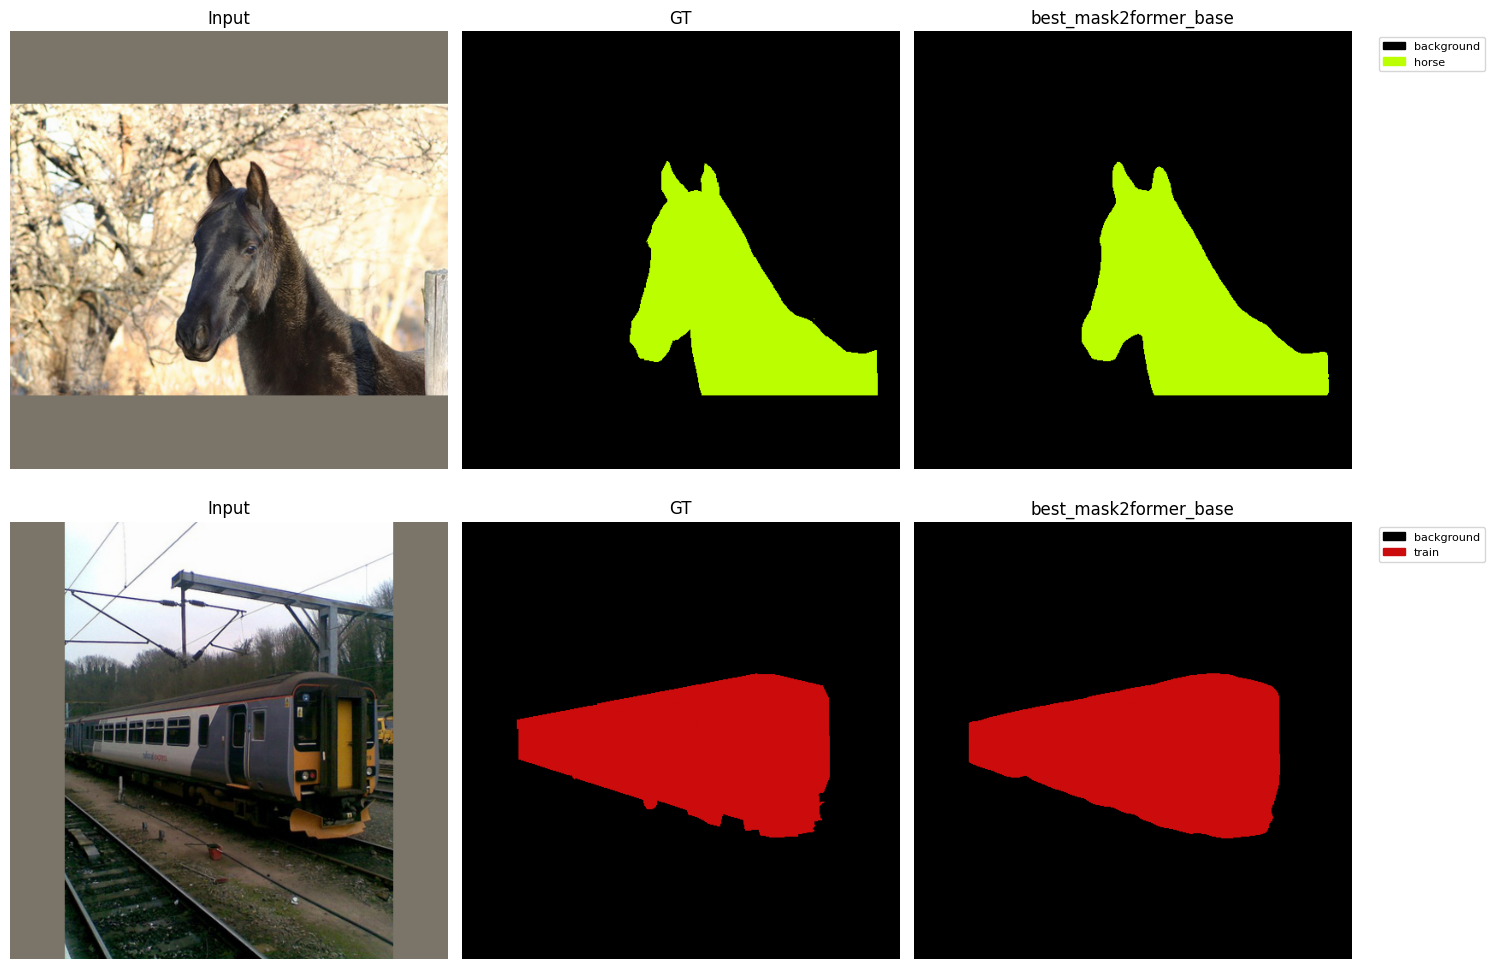

13647

In [ ]:
# ── Mask2Former: load checkpoint or train from scratch ────────────────────
torch.cuda.empty_cache()
gc.collect()
train_loader, val_loader = get_dataloaders("mask2former", batch_size=2)

_M2F_ID = "facebook/mask2former-swin-base-IN21k-coco-instance"
_config  = Mask2FormerConfig.from_pretrained(_M2F_ID)
_config.num_labels  = 21
_config.num_queries = 100
hf_m2f = Mask2FormerForUniversalSegmentation.from_pretrained(
    _M2F_ID, config=_config, ignore_mismatched_sizes=True).to(DEVICE)

_loaded = try_load_seg_checkpoint(
    hf_m2f, "best_mask2former_base.pt", drive_dir=SAVE_DIR)

if not _loaded:
    base_lr       = 1e-5
    # class_predictor: the re-initialised classification head (5,632 params).
    # Luc: explicit param group ensures it gets base_lr and is not
    optimizer_m2f = torch.optim.AdamW([
        {"params": hf_m2f.model.pixel_level_module.encoder.parameters(),
         "lr": base_lr * 0.1},
        {"params": hf_m2f.model.pixel_level_module.decoder.parameters(),
         "lr": base_lr},
        {"params": hf_m2f.model.transformer_module.parameters(),
         "lr": base_lr},
        {"params": hf_m2f.class_predictor.parameters(),
         "lr": base_lr},
    ], weight_decay=1e-4)
    scheduler_m2f = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer_m2f, T_max=40)
    train_mask2former(hf_m2f, train_loader, val_loader,
                      optimizer_m2f, scheduler_m2f,
                      epochs=40, save_name="best_mask2former_base")

evaluate_mask2former(hf_m2f, val_loader, SAVE_DIR + "best_mask2former_base")
visualize_mask2former(hf_m2f, val_loader, "best_mask2former_base")
del hf_m2f, train_loader, val_loader
torch.cuda.empty_cache()
gc.collect()

#### Mask2Former — Segmentation Failure Analysis


**Why it is helpful:** Mask2Former's failure modes differ structurally from
DINOv2 + decoder. Because each class is handled by an independent query,
Mask2Former can fail in two distinct ways: a query may fail to *activate*
for a class (low recall — the FN bar dominates), or a query may *over-fire*
on background or adjacent classes (low precision — the FP bar dominates).
The per-class TP/FP/FN stacked bars make this distinction immediate and
directly inform whether to adjust the query cross-attention, the class head
threshold, or the Hungarian matching cost weights.

In [ ]:
_, val_loader_m2f_diag = get_dataloaders("mask2former", batch_size=2)
config_eval = Mask2FormerConfig.from_pretrained("facebook/mask2former-swin-base-ade-semantic")
config_eval.num_labels = NUM_CLASSES; config_eval.num_queries = 100
hf_m2f_eval = Mask2FormerForUniversalSegmentation.from_pretrained(
    "facebook/mask2former-swin-base-ade-semantic",
    config=config_eval, ignore_mismatched_sizes=True).to(DEVICE)
hf_m2f_eval.load_state_dict(
    torch.load(SAVE_DIR + "best_mask2former_base.pt", map_location=DEVICE, weights_only=True))
results_m2f = analyze_worst_seg(
    model          = hf_m2f_eval,
    val_loader     = val_loader_m2f_diag,
    voc_classes    = VOC_CLASSES,
    model_name     = "Mask2Former",
    is_mask2former = True,
    n_worst=2, n_images=3,
)

Output hidden; open in https://colab.research.google.com to view.

#### Mask2Former — Query Cross-Attention Attribution

**What this does:** Hooks into the last decoder layer's cross-attention
module and extracts the attention weights between the class-specific query
(the query whose class logit for the target class is highest) and the pixel
feature map. The weights are reshaped from the flattened spatial dimension
back to a 2D grid and upsampled to the original image resolution.

**Why it is helpful:**  Seeing which pixels activate for a
given class query directly shows whether the query has learned a correct object
prior (activates on the object's pixels) or a spurious prior (activates on
background texture associated with the class).

Visualising query attention for class: 'horse'


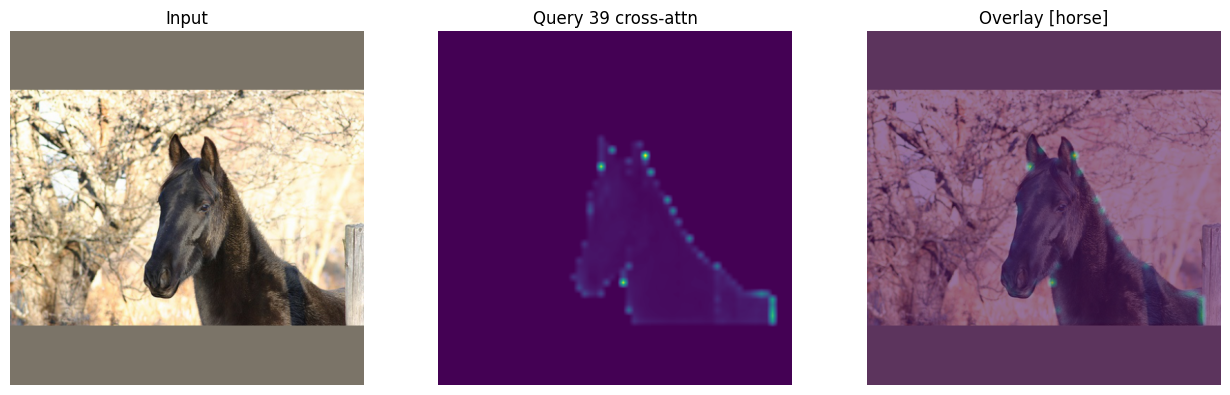

81905

In [ ]:
# Mask2Former query cross-attention — pick a class present in val image
_, val_tf_viz_m2f = get_transforms("mask2former")
sample_m2f_img, sample_m2f_gt = VOCSegDataset(train_df, val_indices, val_tf_viz_m2f)[0]
sample_m2f_t = sample_m2f_img.unsqueeze(0)
# Find a foreground class present in this sample
gt_np  = sample_m2f_gt.numpy()
present_classes = [c for c in range(1, NUM_CLASSES) if (gt_np == c).any()]
if present_classes:
    viz_class_idx  = present_classes[0]
    viz_class_name = VOC_CLASSES[viz_class_idx]
    print(f"Visualising query attention for class: '{viz_class_name}'")
    visualize_m2f_query_attention(
        model        = hf_m2f_eval,
        image_tensor = sample_m2f_t,
        class_idx    = viz_class_idx,
        label_name   = viz_class_name,
    )
del hf_m2f_eval
torch.cuda.empty_cache()
gc.collect()

#### Cross-model Segmentation Comparison

**What this does:** Places the per-class Dice scores of all three segmentation
models (U-Net, DINOv2 + decoder, Mask2Former) side by side in a grouped bar
chart, sorted by mean Dice across models. A per-class winner and loser table
is also printed.

**Why it is helpful:** The comparison answers the same three questions as the
classification analogue: which classes are hard for all models (dataset
difficulty), where each pretrained backbone adds value over U-Net, and which
classes benefit most from the DINOv2 + Mask2Former ensemble. Classes where
DINOv2 and Mask2Former have complementary errors (one under-segments where
the other over-segments) are exactly where the weighted ensemble delivers
the largest gains.

In [ ]:
def get_mask2former_logit_map(hf_m2f, images, target_hw):
    """Convert M2F query outputs to dense (B, 21, H, W) logit map."""
    outputs      = hf_m2f(pixel_values=images)
    mask_logits  = outputs.masks_queries_logits    # (B, Q, H', W')
    class_logits = outputs.class_queries_logits    # (B, Q, C+1)
    B, Q, H_, W_ = mask_logits.shape; C = class_logits.shape[-1] - 1
    query_cls    = torch.softmax(class_logits, dim=-1)[:, :, :C]
    query_masks  = F.interpolate(torch.sigmoid(mask_logits), size=target_hw, mode="bilinear", align_corners=False)
    return torch.einsum("bqc,bqhw->bchw", query_cls, query_masks)

In [ ]:
@torch.no_grad()
def predict_m2f_no_padding(model, img_np, crop_size=384, device=DEVICE):
    """
    Inference WITHOUT padding — eliminates training/test distribution mismatch.
    The model receives only real image content, no grey fill region.
    Swin-Tiny requires dimensions divisible by 32.
    """
    from transformers import Mask2FormerImageProcessor as _M2FProc
    _proc = _M2FProc(ignore_index=255, do_resize=False,
                     do_rescale=False, do_normalize=False)

    orig_h, orig_w = img_np.shape[:2]

    # Scale longest side to crop_size
    scale   = crop_size / max(orig_h, orig_w)
    tgt_h   = int(orig_h * scale)
    tgt_w   = int(orig_w * scale)

    # Round DOWN to nearest multiple of 32 (Swin stride requirement)
    tgt_h   = max(32, (tgt_h // 32) * 32)
    tgt_w   = max(32, (tgt_w // 32) * 32)

    tf = A.Compose([
        A.Resize(tgt_h, tgt_w),
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])
    img_t = tf(image=img_np)["image"].unsqueeze(0).to(device)

    outputs   = model(pixel_values=img_t)
    pred_tgt  = _proc.post_process_semantic_segmentation(
        outputs, target_sizes=[(tgt_h, tgt_w)]
    )[0].cpu().numpy()

    # Resize to original
    pred_orig = cv2.resize(pred_tgt.astype(np.uint8),
                            (orig_w, orig_h),
                            interpolation=cv2.INTER_NEAREST)
    return pred_orig.astype(np.int8)

In [ ]:
# ── Correct test predictions — no padding artifact ────────────────────────
CROP_M2F = 384   # must match the crop used during training
config = Mask2FormerConfig.from_pretrained("facebook/mask2former-swin-base-ade-semantic")
config.num_labels = NUM_CLASSES; config.num_queries = 100
model_m2f = Mask2FormerForUniversalSegmentation.from_pretrained(
    "facebook/mask2former-swin-base-ade-semantic", config=config, ignore_mismatched_sizes=True).to(DEVICE)
model_m2f.load_state_dict(torch.load(SAVE_DIR+"best_mask2former_base.pt", map_location=DEVICE, weights_only=True))
model_m2f.eval()
test_preds_clean = []
for idx in tqdm(range(len(test_df)), desc="Test seg (corrected)"):
    img_np = test_df.iloc[idx]["img"]
    pred = predict_m2f_no_padding(
        model          = model_m2f,
        img_np         = img_np,
        crop_size      = CROP_M2F,
        device         = DEVICE,
    )
    test_preds_clean.append(pred)

test_df["seg"] = test_preds_clean

Loading weights:   0%|          | 0/782 [00:00<?, ?it/s]

Mask2FormerForUniversalSegmentation LOAD REPORT from: facebook/mask2former-swin-base-ade-semantic
Key                    | Status   |                                                                                        
-----------------------+----------+----------------------------------------------------------------------------------------
criterion.empty_weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([151]) vs model:torch.Size([22])          
class_predictor.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([151]) vs model:torch.Size([22])          
class_predictor.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([151, 256]) vs model:torch.Size([22, 256])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
Test seg (corrected): 100%|██████████| 750/750 [01:04<00:00, 11.55it/s]


In [ ]:
print("Cleaning Mask2Former test masks for submission...")

for i in tqdm(range(len(test_df))):
    row = test_df.iloc[i]
    raw_img = row["img"]
    seg_m2f = row["seg"]
    orig_h, orig_w = raw_img.shape[:2]

    # Check if dimensions mismatch (indicating padding/scaling occurred)
    if seg_m2f.shape[:2] != (orig_h, orig_w):
        m2f_h, m2f_w = seg_m2f.shape[:2]

        # 1. Calculate the scale used during the Segformer padding transform
        scale = max(m2f_h, m2f_w) / max(orig_h, orig_w)
        res_h = int(round(orig_h * scale))
        res_w = int(round(orig_w * scale))

        # 2. Identify the padding amounts
        pad_top = (m2f_h - res_h) // 2
        pad_left = (m2f_w - res_w) // 2

        # 3. Crop the mask to remove the letterboxing/padding
        # We crop from [pad_top : pad_top + res_h] and [pad_left : pad_left + res_w]
        seg_cropped = seg_m2f[pad_top : pad_top + res_h, pad_left : pad_left + res_w]

        # 4. Resize the cropped mask back to the exact original pixel dimensions
        seg_cleaned = cv2.resize(
            seg_cropped.astype(np.uint8),
            (orig_w, orig_h),
            interpolation=cv2.INTER_NEAREST
        )

        # 5. Overwrite the mask in the dataframe with the clean version
        test_df.at[i, "seg"] = seg_cleaned

print("Cleanup complete. Masks are now natively aligned with original images.")

Cleaning Mask2Former test masks for submission...


100%|██████████| 750/750 [00:00<00:00, 21928.17it/s]

Cleanup complete. Masks are now natively aligned with original images.


## Section 3 — Adversarial Attacks

### 3.1 Adversarial Attack on Classification

In [ ]:
class DoubleConv(nn.Module):
    """(Convolution => BatchNorm => ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class AdversarialUNet(nn.Module):
    def __init__(self, epsilon=12/255.0):
        super().__init__()
        self.epsilon = epsilon

        # ENCODER (Downsampling)
        # Input: 3 channels (RGB) -> Output: 32 channels
        self.enc1 = DoubleConv(3, 32)
        self.pool1 = nn.MaxPool2d(2)

        # Input: 32 channels -> Output: 64 channels
        self.enc2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        # BOTTLENECK
        # Input: 64 channels -> Output: 128 channels -> 64 channels
        self.bottleneck = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        # DECODER (Upsampling)
        # Upsample 64 -> 64 channels
        self.up1 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        # After concat: 64 (from up1) + 64 (from enc2 skip) = 128 input channels
        self.dec1 = DoubleConv(128, 32)

        # Upsample 32 -> 32 channels
        self.up2 = nn.ConvTranspose2d(32, 32, kernel_size=2, stride=2)
        # After concat: 32 (from up2) + 32 (from enc1 skip) = 64 input channels
        self.dec2 = DoubleConv(64, 32)

        # FINAL LAYER
        # Maps the 32 features back to exactly 3 RGB noise channels
        self.final_conv = nn.Conv2d(32, 3, kernel_size=1)
        self.tanh = nn.Tanh()

    def forward(self, x):
        # 1. Encoder Pass
        e1 = self.enc1(x)         # Shape: (Batch, 32, 224, 224)
        p1 = self.pool1(e1)       # Shape: (Batch, 32, 112, 112)

        e2 = self.enc2(p1)        # Shape: (Batch, 64, 112, 112)
        p2 = self.pool2(e2)       # Shape: (Batch, 64, 56, 56)

        # 2. Bottleneck
        b = self.bottleneck(p2)   # Shape: (Batch, 64, 56, 56)

        # 3. Decoder Pass with Skip Connections
        d1 = self.up1(b)          # Shape: (Batch, 64, 112, 112)

        # Concatenate upsampled bottleneck with enc2 along the channel dimension
        merge1 = torch.cat([d1, e2], dim=1) # Shape: (Batch, 128, 112, 112)
        d1 = self.dec1(merge1)    # Shape: (Batch, 32, 112, 112)

        d2 = self.up2(d1)         # Shape: (Batch, 32, 224, 224)

        # Concatenate upsampled d1 with enc1 along the channel dimension
        merge2 = torch.cat([d2, e1], dim=1) # Shape: (Batch, 64, 224, 224)
        d2 = self.dec2(merge2)    # Shape: (Batch, 32, 224, 224)

        # 4. Final Output & Bounding
        raw_noise = self.final_conv(d2)              # Shape: (Batch, 3, 224, 224)
        bounded_noise = self.tanh(raw_noise) * self.epsilon

        return bounded_noise

In [ ]:
adv_transforms = A.Compose([
    A.Resize(224, 224),       # Match what CLIP/DINOv2 expects
    A.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0), max_pixel_value=255.0), # Converts image to [0.0, 1.0] tensor
    ToTensorV2()
])

# 2. Create a Custom Filtered Dataset
class NegativeExampleDataset(Dataset):
    def __init__(self, original_dataset, target_class_idx):
        self.original_dataset = original_dataset
        self.valid_indices = []

        print(f"Filtering dataset to remove target class: {target_class_idx}...")
        # Loop through the dataset and only keep images that DO NOT contain the target
        for idx in range(len(original_dataset)):
            _, label = original_dataset[idx]

            # Note: If your dataset is multi-label (like VOC), label might be a list/array.
            # Adjust this condition based on how your labels are formatted.
            if label != target_class_idx:
                self.valid_indices.append(idx)

        print(f"Found {len(self.valid_indices)} negative examples for training.")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        # Fetch the actual image using the filtered index
        real_idx = self.valid_indices[idx]
        image, true_label = self.original_dataset[real_idx]
        return image, true_label

In [ ]:
# 1. Define the Transforms (Unnormalized for the Generator)
# Note: Do NOT use the old `cls_val_tf` here if it includes ImageNet Normalize().
# We need raw [0, 1] tensors for the U-Net. We use Albumentations to be compatible with VOCClassificationDataset.
adv_transforms = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0), max_pixel_value=255.0),
    ToTensorV2()
])

TARGET_CLASS = "person"

# 2. Filter the Pandas DataFrames directly!
# Your earlier code showed that `train_df_cls` has a column for 'bottle'
print(f"Original training images: {len(train_df_cls)}")

# Keep only the rows where the 'bottle' column is 0 (or < 0.5)
negative_train_df = train_df_cls[train_df_cls[TARGET_CLASS] < 0.5].reset_index(drop=True)
negative_val_df = val_df_cls[val_df_cls[TARGET_CLASS] < 0.5].reset_index(drop=True)

print(f"Filtered (negative) training images: {len(negative_train_df)}")

# 3. Create the Base Datasets using your existing VOC class
# We pass the newly filtered DataFrames and our unnormalized transforms
adv_train_dataset = VOCClassificationDataset(
    negative_train_df,
    labels, # Your existing list of VOC labels
    adv_transforms
)

# 4. Build the DataLoader
# You can use a batch size of 32 or 64 since the Lightweight U-Net is small
adv_train_loader = DataLoader(
    adv_train_dataset,
    batch_size=32,
    shuffle=True,      # Shuffle is crucial for training the U-Net
    num_workers=4,     # Adjust based on your CPU
    pin_memory=(torch.cuda.is_available())
)

Original training images: 607
Filtered (negative) training images: 442


In [ ]:
@torch.no_grad()  # Critical: Tells PyTorch not to track memory for gradients here
def plot_adversarial_batch(generator, victim_ensemble, dataloader, target_idx, device, epsilon=12/255.0, num_images=4, target_class='bottle'):
    """
    Passes a batch of images through the generator and victim model,
    then plots the Clean Image, the Delta (Noise), and the Adversarial Image.
    """
    # Put models in evaluation mode
    generator.eval()
    victim_ensemble.eval()

    # Standard normalization for the victim model
    normalize_fn = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                        std=[0.229, 0.224, 0.225])

    # Grab one batch of data
    clean_images, _ = next(iter(dataloader))
    clean_images = clean_images[:num_images].to(device)

    # Generate the noise and adversarial images
    noise = generator(clean_images)
    adv_images = torch.clamp(clean_images + noise, min=0.0, max=1.0)

    # Get victim predictions for both clean and adversarial images
    clean_logits = victim_ensemble(normalize_fn(clean_images))
    adv_logits = victim_ensemble(normalize_fn(adv_images))

    # Convert to probabilities (assuming multi-label VOC)
    clean_probs = torch.sigmoid(clean_logits[:, target_idx]).cpu().numpy()
    adv_probs = torch.sigmoid(adv_logits[:, target_idx]).cpu().numpy()

    # Convert tensors to NumPy arrays for Matplotlib (Change shape from C,H,W to H,W,C)
    clean_images_np = clean_images.cpu().permute(0, 2, 3, 1).numpy()
    adv_images_np = adv_images.cpu().permute(0, 2, 3, 1).numpy()
    noise_np = noise.cpu().permute(0, 2, 3, 1).numpy()

    # Setup the plot
    fig, axes = plt.subplots(num_images, 3, figsize=(12, 4 * num_images))
    if num_images == 1:
        axes = np.expand_dims(axes, axis=0) # Fixes indexing if only plotting 1 image

    for i in range(num_images):
        # --- Column 1: Clean Image ---
        axes[i, 0].imshow(clean_images_np[i])
        axes[i, 0].set_title(f"Clean\nP({target_class}) = {clean_probs[i]:.3f}", fontsize=11)
        axes[i, 0].axis('off')

        # --- Column 2: The Noise (Scaled for human eyes) ---
        # Shift noise from [-eps, eps] to [0, 1] so Matplotlib can render it
        visible_noise = np.clip((noise_np[i] / (2 * epsilon)) + 0.5, 0, 1)
        axes[i, 1].imshow(visible_noise)
        axes[i, 1].set_title(f"U-Net Generated Noise\n(Scaled to visible range)", fontsize=11)
        axes[i, 1].axis('off')

        # --- Column 3: Adversarial Image ---
        # Green title if it successfully crossed 0.65 threshold, Red if it failed
        color = "green" if adv_probs[i] >= 0.65 else "red"
        axes[i, 2].imshow(adv_images_np[i])
        axes[i, 2].set_title(f"Adversarial\nP({target_class}) = {adv_probs[i]:.3f}", fontsize=11, color=color, fontweight='bold')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

    # Put generator back into train mode just in case this was called mid-training
    generator.train()

In [ ]:
# 1. Setup Models
generator = AdversarialUNet().to(DEVICE)
victim_model = model_clip_v2.to(DEVICE)

# CRITICAL: Freeze the victim model completely.
# We only want to train the generator.
victim_model.eval()
for param in victim_model.parameters():
    param.requires_grad = False

optimizer = torch.optim.Adam(generator.parameters(), lr=1e-4)
loss_fn = nn.CrossEntropyLoss()

# The class index you want to force (e.g., 'bottle')
num_epochs = 200

In [ ]:
# 2. The Training Loop
generator.train()

for epoch in range(num_epochs):
    TARGET_IDX = list(labels).index(TARGET_CLASS)
    # Standard ImageNet normalization for the victim model
    normalize_fn = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                        std=[0.229, 0.224, 0.225])

    epoch_loss = 0.0

    # Example Training Loop Step
    for clean_images, _ in adv_train_loader:
        clean_images = clean_images.to(DEVICE)
        batch_size = clean_images.size(0)

        # 1. Generator makes noise
        noise = generator(clean_images)

        # 2. Add and clamp
        adversarial_images = torch.clamp(clean_images + noise, min=0.0, max=1.0)

        # 3. Normalize for the Victim
        normalized_adv_images = normalize_fn(adversarial_images)

        # 4. Get Victim Predictions
        logits = victim_model(normalized_adv_images)

        # 5. Calculate Loss
        # We want to force the prediction at TARGET_IDX to be 1.0 (highly confident)
        target_logits = logits[:, TARGET_IDX]

        # BCEWithLogitsLoss is perfect here because we are targeting a single probability
        # out of a multi-label output.
        bce_loss = torch.nn.functional.binary_cross_entropy_with_logits(
            target_logits,
            torch.ones_like(target_logits) # We demand the model outputs a '1' for bottle
        )

        # Backpropagate through the victim into the generator
        optimizer.zero_grad()
        bce_loss.backward()
        optimizer.step()

        epoch_loss += bce_loss.item()

    avg_loss = epoch_loss / len(adv_train_loader)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch + 1}/{num_epochs}] - Avg BCE Loss: {avg_loss:.4f}")
    if (epoch + 1) % 50 == 0:
        print(f"--- Visualizing Epoch {epoch + 1} ---")
        plot_adversarial_batch(generator, victim_model, adv_train_loader, TARGET_IDX, DEVICE)

print("Adversarial training completed.")

Output hidden; open in https://colab.research.google.com to view.

### 3.2 Adversarial Attack on Segmentation

We followed a two-step approach to evaluate the adversarial robustness of our segmentation models:

* Step 1: Evaluating Model Robustness (Untargeted Attacks)

* Step 2: Forcing Fake Predictions (Targeted Attacks)

To keep this notebook brief, we run only the Mask2Former attack code, but we discussed the SegFormer in the last section of the notebook.

In [ ]:
def get_saliency_map(model, img_tensor, target_class):
    """Generates a saliency map showing pixel importance for a target class."""
    img_tensor = img_tensor.clone().detach().to(DEVICE).requires_grad_(True)
    outputs = model(img_tensor)
    score = outputs[:, target_class, :, :].sum()
    model.zero_grad()
    score.backward()
    saliency, _ = torch.max(torch.abs(img_tensor.grad.data), dim=1)
    return saliency.squeeze().cpu().numpy()

def find_class_samples(loader):
    """Scans the dataloader to find exactly one image for each of the 20 VOC object classes."""
    samples = {}
    target_classes = set(range(1, 21)) # Classes 1-20

    with torch.no_grad():
        for images, masks in loader:
            for i in range(images.size(0)):
                img = images[i]
                mask = masks[i]
                present_classes = torch.unique(mask).cpu().numpy()

                for cls_idx in present_classes:
                    if cls_idx in target_classes and cls_idx not in samples:
                        # Store to CPU to avoid VRAM bloat
                        samples[cls_idx] = (img.cpu(), mask.cpu())

                if len(samples) == 20:
                    return samples
    return samples

def prepare_mask2former_targets(masks_tensor, ignore_index=255):
    """Helper to convert standard masks to Mask2Former binary object targets."""
    mask_labels, class_labels = [], []
    for mask in masks_tensor:
        classes = torch.unique(mask)
        classes = classes[classes != ignore_index]

        b_masks, b_classes = [], []
        for c in classes:
            b_masks.append(mask == c)
            b_classes.append(c)

        if not b_masks:
            b_masks.append(torch.zeros_like(mask, dtype=torch.bool))
            b_classes.append(torch.tensor(0, device=mask.device))

        mask_labels.append(torch.stack(b_masks).to(torch.float32))
        class_labels.append(torch.stack(b_classes).to(torch.int64))
    return mask_labels, class_labels

In [ ]:
class AdversarialGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU()
        )
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 3, 3, padding=1), nn.Tanh()
        )

    def forward(self, x, strength=0.05):
        return self.dec(self.enc(x)) * strength

def train_adversary(generator, victim, loader, model_type="mask2former", target_class=1, epochs=5, strength=0.3):
    optimizer = torch.optim.Adam(generator.parameters(), lr=1e-3)
    victim.eval()
    for param in victim.parameters():
        param.requires_grad = False

    scaler = torch.amp.GradScaler('cuda')

    for epoch in range(epochs):
        pbar = tqdm(loader, desc=f"Training {model_type.upper()} Adversary Epoch {epoch+1}")
        for images, _ in pbar:
            images = images.to(DEVICE)
            optimizer.zero_grad()

            if model_type == "segformer":
                # Segformer runs safely in float16
                with torch.amp.autocast('cuda'):
                    delta = generator(images, strength=strength)
                    perturbed = torch.clamp(images + delta, -3.0, 3.0)
                    outputs = victim(perturbed)
                    target = torch.full((images.shape[0], images.shape[2], images.shape[3]),
                                        target_class, dtype=torch.long, device=DEVICE)
                    loss_task = F.cross_entropy(outputs, target)
                    loss = loss_task + 0.5 * torch.mean(delta**2)

                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            elif model_type == "mask2former":
                # Mask2Former loss overflows in float16, MUST run in float32
                delta = generator(images, strength=strength)
                perturbed = torch.clamp(images + delta, -3.0, 3.0)

                adv_mask = torch.full((images.shape[0], images.shape[2], images.shape[3]),
                                      target_class, dtype=torch.long, device=DEVICE)
                mask_labels, class_labels = prepare_mask2former_targets(adv_mask)
                outputs = victim(pixel_values=perturbed, mask_labels=mask_labels, class_labels=class_labels)

                loss_task = outputs.loss
                loss = loss_task + 0.5 * torch.mean(delta**2)

                loss.backward() # Standard backward pass (no scaler)
                optimizer.step()

            pbar.set_postfix({"Loss": f"{loss.item():.4f}"})

#### Step 1: Untargeted Attacks: Evaluating Model Robustness

We used a shared convolutional generator architecture to launch untargeted attacks against Mask2Former.

In [ ]:
def run_adversarial_suite(generator, victim, samples_dict, model_type="mask2former", filename="adversarial_compact.png"):
    """
    Creates a single consolidated visualization with minimized vertical gaps.
    """
    num_classes = len(samples_dict)
    fig = plt.figure(figsize=(30, 3.5 * num_classes))
    outer_gs = gridspec.GridSpec(num_classes, 1, figure=fig, hspace=0.1)

    if model_type == "segformer":
        levels = {
            "Baseline": 0.0,
            "Minor (Visible)": 0.3,
            "Extreme (Visible)": 1.0
        }
    else:
        levels = {
            "Baseline": 0.0,
            "Minor (Visible)": 0.3,
            "Extreme (Visible)": 0.6
        }

    mean = np.array([0.485, 0.456, 0.406]).reshape(1, 1, 3)
    std = np.array([0.229, 0.224, 0.225]).reshape(1, 1, 3)

    width_ratios = [0.6, 1, 1, 1, 0.2, 1, 1, 1, 0.2, 1, 1, 1]
    col_mappings = [[1, 2, 3], [5, 6, 7], [9, 10, 11]]
    sorted_keys = sorted(samples_dict.keys())

    if model_type == "mask2former":
        processor = Mask2FormerImageProcessor(ignore_index=255, do_resize=False, do_rescale=False, do_normalize=False)

    for row_idx, cls_idx in enumerate(sorted_keys):
        img, mask = samples_dict[cls_idx]
        img_t = img.unsqueeze(0).to(DEVICE)
        class_name = VOC_CLASSES[cls_idx].upper()

        inner_gs = gridspec.GridSpecFromSubplotSpec(1, 12, subplot_spec=outer_gs[row_idx],
                                                    width_ratios=width_ratios, wspace=0.1)

        # --- COLUMN 1: CLASS NAME ---
        ax_title = fig.add_subplot(inner_gs[0, 0])
        ax_title.text(0.5, 0.5, class_name, fontsize=16, fontweight='bold',
                      va='center', ha='center')
        ax_title.axis('off')

        for i, (level_name, s) in enumerate(levels.items()):
            delta = generator(img_t, strength=s) if s > 0 else torch.zeros_like(img_t)
            perturbed = torch.clamp(img_t + delta, -3.0, 3.0)

            with torch.no_grad():
                if model_type == "segformer":
                    outputs = victim(perturbed)
                    pred = torch.argmax(outputs, dim=1).squeeze().cpu().numpy()
                elif model_type == "mask2former":
                    outputs = victim(pixel_values=perturbed)
                    pred = processor.post_process_semantic_segmentation(outputs, target_sizes=[img_t.shape[2:]])[0].cpu().numpy()

                    # Mask2Former outputs '21' for pixels with no confident object mask.
                    # In PASCAL VOC, we map these 'unassigned' pixels to Background (0).
                    pred[pred == 21] = 0

            # Map the padding regions to background (0)
            pred[mask.cpu().numpy() == 255] = 21

            vis_img = np.clip(perturbed.squeeze().detach().cpu().numpy().transpose(1, 2, 0) * std + mean, 0, 1)

            # The perturbation has positive and negative values. We center zero at 0.5 (gray).
            # We scale it dynamically based on the attack strength 's' to make the noise clearly visible.
            if s > 0:
                delta_np = delta.squeeze().detach().cpu().numpy().transpose(1, 2, 0)
                vis_delta = np.clip((delta_np / (2.0 * s)) + 0.5, 0, 1)
            else:
                vis_delta = np.full((img_t.shape[2], img_t.shape[3], 3), 0.5)

            target_cols = col_mappings[i]
            labels = ["Perturbation", "Attack Image", "Prediction"]
            plot_data = [vis_delta, vis_img, pred]

            for sub_idx, col in enumerate(target_cols):
                ax = fig.add_subplot(inner_gs[0, col])
                if sub_idx == 2:
                    ax.imshow(plot_data[sub_idx], cmap='nipy_spectral', vmin=0, vmax=20)
                else:
                    ax.imshow(plot_data[sub_idx])

                # Group headers
                if row_idx == 0 and sub_idx == 1:
                    ax.text(0.5, 1.15, level_name, transform=ax.transAxes,
                            fontsize=16, fontweight='bold', ha='center',
                            bbox=dict(facecolor='lightgray', alpha=0.8, boxstyle='round,pad=0.3'))

                if row_idx == 0:
                    ax.set_title(labels[sub_idx], fontsize=10)

                ax.axis('off')

    plt.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.9, wspace=0.1, hspace=0.1)
    plt.savefig(filename, dpi=120, bbox_inches='tight')
    plt.show()


In [ ]:
# ==========================================
# 1. Mask2former Attack Pipeline
# ==========================================
print("\n" + "="*50 + "\nINITIATING Mask2former ATTACK\n" + "="*50)
torch.cuda.empty_cache(); gc.collect()

adv_gen_m2f = AdversarialGenerator().to(DEVICE)
model_id = "facebook/mask2former-swin-base-ade-semantic"
config = Mask2FormerConfig.from_pretrained(model_id)
config.num_queries = 100
config.num_labels = 21
victim_m2f = Mask2FormerForUniversalSegmentation.from_pretrained(model_id, config=config, ignore_mismatched_sizes=True).to(DEVICE)

ckpt_path = SAVE_DIR + "best_mask2former_base.pt"
if os.path.exists(ckpt_path):
    print(f"Loading victim weights from {ckpt_path}")
    victim_m2f.load_state_dict(torch.load(ckpt_path, weights_only=True, map_location=DEVICE))
elif os.path.exists("best_mask2former_base.pt"):
    print("Loading victim weights from local best_mask2former_base.pt")
    victim_m2f.load_state_dict(torch.load("best_mask2former_base.pt", weights_only=True, map_location=DEVICE))
else:
    print("WARNING: Could not find trained Mask2Former weights!")

train_loader_m2f, val_loader_m2f = get_dataloaders("mask2former", batch_size=2) # LG EDIT
print("Gathering class-representative images for Mask2Former...")
samples_m2f = find_class_samples(val_loader_m2f)

if samples_m2f:
    train_adversary(adv_gen_m2f, victim_m2f, train_loader_m2f, model_type="mask2former", epochs=30) # LG EDIT


INITIATING Mask2former ATTACK


Loading weights:   0%|          | 0/782 [00:00<?, ?it/s]

Mask2FormerForUniversalSegmentation LOAD REPORT from: facebook/mask2former-swin-base-ade-semantic
Key                    | Status   |                                                                                        
-----------------------+----------+----------------------------------------------------------------------------------------
criterion.empty_weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([151]) vs model:torch.Size([22])          
class_predictor.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([151]) vs model:torch.Size([22])          
class_predictor.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([151, 256]) vs model:torch.Size([22, 256])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Loading victim weights from /content/drive/MyDrive/Colab_Notebooks/KU_Leuven/CV/best_mask2former_base.pt
Gathering class-representative images for Mask2Former...


Training MASK2FORMER Adversary Epoch 14:  73%|███████▎  | 223/304 [03:37<01:18,  1.03it/s, Loss=20.5099]

In [ ]:
if samples_m2f:
    run_adversarial_suite(adv_gen_m2f, victim_m2f, samples_m2f, model_type="mask2former", filename="adversarial_mask2former.png")

# Final Cleanup
torch.cuda.empty_cache(); gc.collect()

#### Step 2: Forcing Fake Predictions (Targeted Attacks)

Our goal was to see if we could force them to segment a specific object that was not actually present in the image.

In [ ]:
def create_targeted_attack(victim_model, train_loader, target_name, model_type="mask2former", epochs=5, strength=0.3):
    generator = AdversarialGenerator().to(DEVICE)

    if target_name not in VOC_CLASSES:
        raise ValueError(f"Target class '{target_name}' not found in VOC_CLASSES.")
    target_class_idx = VOC_CLASSES.index(target_name)

    train_adversary(
        generator=generator,
        victim=victim_model,
        loader=train_loader,
        model_type=model_type,
        target_class=target_class_idx,
        epochs=epochs,
        strength=strength # Pass the strength down
    )

    return generator

In [ ]:
def verify_universal_attack(generator, victim, target_name, val_loader=None, samples_dict=None, model_type="mask2former", filename="universal_attack.png"):
    """
    Visualizes the attack pipeline using a provided samples_dict, or automatically pulls a batch from val_loader.
    """
    generator.eval()
    victim.eval()

    mean = np.array([0.485, 0.456, 0.406]).reshape(1, 1, 3)
    std = np.array([0.229, 0.224, 0.225]).reshape(1, 1, 3)
    cmap = plt.get_cmap('nipy_spectral')

    if model_type == "mask2former":
        # FIX 1: Remove ignore_index=255 so the null class naturally defaults to 21
        processor = Mask2FormerImageProcessor(do_resize=False, do_rescale=False, do_normalize=False)

    # --- Conditionally handle the inputs ---
    if samples_dict is None:
        if val_loader is None:
            raise ValueError("You must provide either 'val_loader' or 'samples_dict'.")
        # Extract one real validation batch and map it to a temporary dict format
        images_batch, masks_batch = next(iter(val_loader))
        samples_dict = {i: (images_batch[i], masks_batch[i]) for i in range(images_batch.size(0))}
    # -------------------------------------------

    num_images = len(samples_dict)
    fig, axs = plt.subplots(num_images, 5, figsize=(25, 5 * num_images))
    if num_images == 1:
        axs = np.expand_dims(axs, axis=0)

    fig.suptitle(f"Universal Targeted Attack: FORCE TO '{target_name.upper()}' ({model_type.upper()})", fontsize=26, fontweight='bold', y=1.01)

    attack_strength = 1.0 if model_type == "segformer" else 0.4

    for row_idx, cls_idx in enumerate(sorted(samples_dict.keys())):
        img_cpu, mask_cpu = samples_dict[cls_idx]
        img = img_cpu.unsqueeze(0).to(DEVICE)
        mask = mask_cpu.numpy()

        class_original = VOC_CLASSES[cls_idx].capitalize() if cls_idx < len(VOC_CLASSES) else f"Image {cls_idx}"

        # ==========================================
        # 1. Clean Prediction
        # ==========================================
        with torch.no_grad():
            if model_type == "segformer":
                out_c = victim(img)
                pred_c = torch.argmax(out_c, dim=1).cpu().numpy()[0]
            elif model_type == "mask2former":
                out_c = victim(pixel_values=img)
                pred_c = torch.stack(processor.post_process_semantic_segmentation(out_c, target_sizes=[img.shape[2:]])).cpu().numpy()[0]
                pred_c[pred_c == 21] = 0 # Map null class cleanly to Background (0)

        # ==========================================
        # 2. Attack Execution
        # ==========================================
        delta = generator(img, strength=attack_strength)
        perturbed = torch.clamp(img + delta, -3.0, 3.0)

        # ==========================================
        # 3. Attacked Prediction
        # ==========================================
        with torch.no_grad():
            if model_type == "segformer":
                out_a = victim(perturbed)
                pred_a = torch.argmax(out_a, dim=1).cpu().numpy()[0]
            elif model_type == "mask2former":
                out_a = victim(pixel_values=perturbed)
                pred_a = torch.stack(processor.post_process_semantic_segmentation(out_a, target_sizes=[img.shape[2:]])).cpu().numpy()[0]
                pred_a[pred_a == 21] = 0 # Map null class cleanly to Background (0)

        # ==========================================
        # 4. Format Visuals
        # ==========================================
        vis_orig = np.clip(img.squeeze().detach().cpu().numpy().transpose(1, 2, 0) * std + mean, 0, 1)
        vis_attack = np.clip(perturbed.squeeze().detach().cpu().numpy().transpose(1, 2, 0) * std + mean, 0, 1)

        # --- THE FIX: Dynamically scale the noise so it stretches fully from 0 to 1 ---
        delta_np = delta.squeeze().detach().cpu().numpy().transpose(1, 2, 0)
        vis_delta = np.clip((delta_np / (2.0 * attack_strength)) + 0.5, 0, 1)

        # Handle Padding (Must be 0 to avoid the TV monitor bug)
        pred_c[mask == 255] = 0
        pred_a[mask == 255] = 0

        # --- Column 1: Original Image ---
        axs[row_idx, 0].imshow(vis_orig)
        axs[row_idx, 0].set_title(f"1. Original ({class_original})", fontsize=14)
        axs[row_idx, 0].axis('off')

        # --- Column 2: Unperturbed Prediction ---
        axs[row_idx, 1].imshow(pred_c, cmap='nipy_spectral', vmin=0, vmax=20)
        axs[row_idx, 1].set_title("2. Clean Prediction", fontsize=14)
        axs[row_idx, 1].axis('off')
        u_c = np.unique(pred_c)
        axs[row_idx, 1].legend(handles=[mpatches.Patch(color=cmap(c/20.), label=VOC_CLASSES[c]) for c in u_c if c < len(VOC_CLASSES)], loc='best', fontsize=9, framealpha=0.7)

        # --- Column 3: Perturbed Image ---
        axs[row_idx, 2].imshow(vis_attack)
        axs[row_idx, 2].set_title(f"3. Perturbed Image (ε={attack_strength})", fontsize=14)
        axs[row_idx, 2].axis('off')

        # --- Column 4: Perturbation Signal ---
        axs[row_idx, 3].imshow(vis_delta)
        axs[row_idx, 3].set_title("4. Perturbation Signal", fontsize=14)
        axs[row_idx, 3].axis('off')

        # --- Column 5: Attacked Prediction ---
        axs[row_idx, 4].imshow(pred_a, cmap='nipy_spectral', vmin=0, vmax=20)
        axs[row_idx, 4].set_title("5. Attacked Prediction", fontsize=14)
        axs[row_idx, 4].axis('off')
        u_a = np.unique(pred_a)
        axs[row_idx, 4].legend(handles=[mpatches.Patch(color=cmap(c/20.), label=VOC_CLASSES[c]) for c in u_a if c < len(VOC_CLASSES)], loc='best', fontsize=9, framealpha=0.7)

    plt.tight_layout()
    plt.savefig(filename, dpi=120, bbox_inches='tight')
    plt.show()

In [ ]:
TARGET_CLASS_NAME = "tvmonitor"  # "cat", "train", "sofa", etc.

class_generator = create_targeted_attack(
    victim_model=victim_m2f,
    train_loader=train_loader_m2f,
    target_name=TARGET_CLASS_NAME,
    model_type="mask2former",
    epochs=1  # Increase to 10 if the model is resisting the attack
)

Training MASK2FORMER Adversary Epoch 1: 100%|██████████| 304/304 [04:57<00:00,  1.02it/s, Loss=22.6300]


In [ ]:
# Verify it works on a random batch of images
verify_universal_attack(
    generator=class_generator,
    victim=victim_m2f,
    target_name=TARGET_CLASS_NAME,
    val_loader=val_loader_m2f,      # Passed explicitly
    model_type="mask2former"
)

Output hidden; open in https://colab.research.google.com to view.

**Comments**: Contrary to SegFormer, Mask2Former is very resilient to our

---

attacks. This is further discussed in the section below.

In [ ]:
# Loop over all classes to test model resilience on class-by-class basis
if False: # This code is deactivated because it is time consuming and produce a lot of heavy charts.
    def evaluate_attack_success(generator, victim, val_loader, target_name, model_type="mask2former", eval_batches=10):
        """
        Evaluates the numerical success of a targeted adversarial attack.

        Args:
            eval_batches: How many batches to evaluate (to save time in the loop).
                        Set to len(val_loader) for full dataset evaluation.
        """
        generator.eval()
        victim.eval()

        target_idx = VOC_CLASSES.index(target_name)
        attack_strength = 1.0 if model_type == "segformer" else 0.4

        if model_type == "mask2former":
            processor = Mask2FormerImageProcessor(ignore_index=255, do_resize=False, do_rescale=False, do_normalize=False)

        total_eligible_pixels = 0
        successful_attack_pixels = 0
        conf_matrix = torch.zeros(21, 21, dtype=torch.int64)

        with torch.no_grad():
            for i, (images, masks) in enumerate(val_loader):
                if i >= eval_batches:
                    break

                images = images.to(DEVICE)

                # 1. Generate Attack
                delta = generator(images, strength=attack_strength)
                perturbed = torch.clamp(images + delta, -3.0, 3.0)

                # 2. Get Attacked Predictions
                if model_type == "segformer":
                    outputs = victim(perturbed)
                    preds = torch.argmax(outputs, dim=1).cpu()
                elif model_type == "mask2former":
                    outputs = victim(pixel_values=perturbed)
                    target_sizes = [images.shape[2:] for _ in range(images.shape[0])]
                    preds = torch.stack(processor.post_process_semantic_segmentation(outputs, target_sizes=target_sizes)).cpu()
                    preds[preds == 21] = 0 # Handle unassigned pixels

                mask_flat = masks.view(-1).long()
                pred_flat = preds.view(-1).long()

                # 3. Calculate Attack Success Rate (ASR)
                valid_indices = (mask_flat != 255)
                # We only count pixels that were NOT originally the target class
                eligible_indices = valid_indices & (mask_flat != target_idx)

                total_eligible_pixels += eligible_indices.sum().item()
                successful_attack_pixels += (pred_flat[eligible_indices] == target_idx).sum().item()

                # 4. Calculate Degraded mIoU (Compared to Ground Truth)
                conf_matrix += torch.bincount(
                    21 * mask_flat[valid_indices] + pred_flat[valid_indices],
                    minlength=21**2
                ).reshape(21, 21)

        # Final Metrics
        asr = (successful_attack_pixels / max(total_eligible_pixels, 1)) * 100

        tp = torch.diag(conf_matrix)
        fp = conf_matrix.sum(dim=0) - tp
        fn = conf_matrix.sum(dim=1) - tp
        iou = (tp.float() / (tp + fp + fn + 1e-12)).numpy()
        mean_iou = np.mean(iou)

        return asr, mean_iou

    # %%
    # ==========================================
    # Loop: Universal Attack for Every Class
    # ==========================================
    import gc

    # 1. Gather the 20 class-representative images globally
    print("Gathering class-representative images from validation set...")
    class_samples_dict = find_class_samples(val_loader_sf)
    print(f"Found images for {len(class_samples_dict)}/20 classes.\n")

    # Ensure memory is completely clean
    torch.cuda.empty_cache()
    gc.collect()

    # Dictionary to store our numerical results
    attack_results = {"Class": [], "ASR (%)": [], "Degraded mIoU": []}

    # %%
    # ==========================================
    # Loop: Universal Attack for Every Class
    # ==========================================
    import gc

    # 1. Gather the 20 class-representative images globally
    print("Gathering class-representative images from validation set...")
    class_samples_dict = find_class_samples(val_loader_sf)
    print(f"Found images for {len(class_samples_dict)}/20 classes.\n")

    # Ensure memory is completely clean
    torch.cuda.empty_cache()
    gc.collect()

    # Dictionary to store our numerical results
    attack_results = {"Class": [], "ASR (%)": [], "Degraded mIoU": []}

    # --- YOUR UPDATED LOOP CODE GOES HERE ---
    # We skip index 0 ("background") to only target foreground objects
    for target_class in VOC_CLASSES[1:]:
        print(f"\n{'='*80}")
        print(f" Executing Universal Targeted Attack: {target_class.upper()}")
        print(f"{'='*80}\n")

        # Define the exact strength we will use for both training and evaluation
        MODEL_TYPE = "mask2former"
        current_attack_strength = 1.0 if "segformer" == "segformer" else 0.4

        # 2. Train the specific attack
        class_generator = create_targeted_attack(
            victim_model=victim_m2f,           # FIXED: Pass Mask2Former victim
            train_loader=val_loader_m2f,       # FIXED: Pass Mask2Former static images
            target_name=target_class,
            model_type=MODEL_TYPE,             # FIXED: Set to "mask2former"
            epochs=5,
            strength=current_attack_strength # FIXED: Synchronized training strength
        )

        # 3. Visualize the attack on the curated 20 images
        verify_universal_attack(
            generator=class_generator,
            victim=victim_m2f,                 # FIXED: Pass Mask2Former victim
            val_loader=None,
            samples_dict=class_samples_dict,
            target_name=target_class,
            model_type=MODEL_TYPE,
            filename=f"universal_attack_{target_class}.png"
        )

        # 4. Numerically Evaluate the Attack
        print(f"Evaluating numerical success for {target_class.upper()}...")
        asr, mean_iou = evaluate_attack_success(
            generator=class_generator,
            victim=victim_m2f,                 # FIXED: Pass Mask2Former victim
            val_loader=val_loader_m2f,         # FIXED: Pass Mask2Former validation loader
            target_name=target_class,
            model_type=MODEL_TYPE,             # FIXED: Set to "mask2former"
            eval_batches=10
        )

        print(f"  -> Attack Success Rate (ASR): {asr:.2f}% of pixels forced to '{target_class}'")
        print(f"  -> Degraded Model mIoU:       {mean_iou:.4f}")

        # Save results for the final table
        attack_results["Class"].append(target_class)
        attack_results["ASR (%)"].append(asr)
        attack_results["Degraded mIoU"].append(mean_iou)

        # ==========================================
        # CRITICAL MEMORY CLEANUP
        # ==========================================
        del class_generator
        plt.close('all')
        torch.cuda.empty_cache()
        gc.collect()

    # ==========================================
    # FINAL SUMMARY REPORT
    # ==========================================
    import pandas as pd

    print("\n" + "="*50)
    print(" FINAL UNIVERSAL ATTACK SUMMARY REPORT")
    print("="*50)
    results_df = pd.DataFrame(attack_results)
    # Sort by Attack Success Rate to see which classes were easiest to force
    results_df = results_df.sort_values(by="ASR (%)", ascending=False).reset_index(drop=True)
    print(results_df.to_string(index=False))

## Section 4 — Discussion

**Here we would like to say that most of our cells have a markdown cell explaining why we are doing everything. This discussion part is a summary of these comments and it also includes experiments that did not make it to our deliverable.**

### 4.1 Data Explanatory Analysis

Our project began with an extensive Exploratory Data Analysis (EDA), which was a fundamentally important phase of our work. We invested a significant amount of time into this step to deeply understand our dataset's structure, recognizing early on that classification and segmentation possess different failure modes and design levers. This upfront effort was crucial; it guided us in engineering the best possible dataset right from the start. Ultimately, this high-quality data preparation stabilized our training process and allowed us to confidently evaluate our models without the need for cross-validation.<br>
For the Image Classification task, our thorough EDA directly informed our data transformation and augmentation strategies. By examining the varied dimensions and distributions of the source images, we identified the need for specific adjustments, such as utilizing RandomResizedCrop. This allowed us to handle varying aspect ratios effectively without distorting crucial features, ensuring that the resulting dataset was robust, standardized, and highly representative of the underlying visual problem. <br>
In the Semantic Segmentation section, our EDA insights were equally vital for establishing a strong foundational dataset geared toward precise pixel-level predictions. By analyzing the scale, aspect ratios, and detail of the segmentation masks alongside the original images, we were able to determine optimal resolution limits (such as standardizing to a 384px setup) to preserve critical spatial information. This careful, data-first approach guaranteed that our segmentation dataset was optimized for clarity and precision, validating our rigorous setup process without relying on downstream architectural tweaks to compensate for poor data.

| EDA cell | Finding | Model consequence applied |
|----------|---------|--------------------------|
| 0.1.1 Image sizes | Wide aspect ratio range (0.37–3.5), avg 375×500 px | RandomResizedCrop (not just Resize) for training |
| 0.1.2 Class freq | 'person' 28%, 'sheep'/'cow' ~3-4% | Stratified split (not random) is critical for rare classes |
| 0.1.3 Cardinality | 93-95% of (image, class) pairs are negative | ASL (γ⁻=4) instead of BCE |
| 0.1.4 Pixel stats | VOC ≈ ImageNet (Δ mean < 0.02) | ImageNet normalisation valid; pretrained transfer justified |
| 0.1.5 Split | MultilabelStratified max drift < 0.05 | Validated — thresholds tuned on representative val set |
| SEG EDA 1 | Background = 77.7% of pixels (254× imbalance) | Median-freq class weights in CE + Dice loss |
| SEG EDA 2 | Zero void pixels in this pre-processed dataset | ignore_index=255 kept as harmless guard |
| SEG EDA 3 | Fragmented masks create misleading area stats | Masks are noisy; do not over-optimise for very small areas |
| SEG EDA 4 | Strong centre bias in all classes | RandomCrop (not just Resize) to break location shortcuts |
| SEG EDA 5 | When present, objects cover 5-30% of image | Dice loss appropriate (rewards coverage, not just detection) |

### 4.2 Classification

#### 4.2.1 Training from scratch

**SmallCNN**

Description: This is a custom 5-block VGG-style Convolutional Neural Network with approximately 1.6M parameters. <br>
SmallCNN is small enough to avoid immediate overfitting, but large enough to map features to 20 binary outputs.<br>
It was trained using Label Smoothing BCE as loss function. (more info in the cell)
- Result: 0.39 mAP | 0.45 Mean F1 .

[**ResNet18** ](https://arxiv.org/pdf/1512.03385)

Description: This was the deep residual network containing around 11M parameters that this paper did. It was tested from random initialization to see if a widely adopted standard architecture could learn the multi-label task from scratch without pre-trained weights.<br>
It was trained using [Assymetric Loss](https://openaccess.thecvf.com/content/ICCV2021/papers/Ridnik_Asymmetric_Loss_for_Multi-Label_Classification_ICCV_2021_paper.pdf) as loss function.
- Result: 0.36 mAP | 0.41 Mean F1

**Comments**

As expected, training from scratch on a small dataset (750 images) is extremely difficult, making the models highly susceptible to overfitting and heavily reliant on strong data augmentation.<br>

The ResNet18 performed worse than the much simpler SmallCNN. With 11M parameters and only 750 training images, the model overfit consistently, proving that high parameter counts are a liability without pre-training. <br>

We didn't spend a lot of time trying to improve the performance of the two models, as all architecture design bottlenecks were coming from the data shortage. We turned our attention instead towards pretrained models, which are expected to yield better results. In the notebook, we chose to present SmallCNN as a baseline because it is lightweight, fast to train and for its decent performance.


#### 4.2.2 Transfer learning
We tried lots and different models trained for different purposes.

[**ResNet50**](https://arxiv.org/pdf/1512.03385)<br>

Description: A 50-layer deep residual network using pre-trained weights. It is interesting to test as the industry-standard baseline for transfer learning, allowing us to see how much immediate value standard ImageNet features provide.<br>
Trained using [Assymetric Loss](https://openaccess.thecvf.com/content/ICCV2021/papers/Ridnik_Asymmetric_Loss_for_Multi-Label_Classification_ICCV_2021_paper.pdf). <br>
- Result: 0.91 mAP | 0.88 Mean F1.<br>

[**DINOv2 ViT-B/14**](https://arxiv.org/pdf/2304.07193)<br>
Description & Rationale: A self-supervised Vision Transformer. This model is interesting to try, because it has not been trained for a specific downstream task, but to learn latent representations of the visual world. So, we wanted to use these representations / features by adding some extra layers at the end of this model to tackle classification.<br>
This type of models (backbone + layers on top) were trained using two phase training, in which the 1st phase was freezing the backbone model and training only the last added layers to not let the big gradients of the randomly initialized layers affect the learning of the pre-trained layers. After a number of epochs we would unfreeze the total model and continue training with much smaller learning rate.<br>
Trained using [Assymetric Loss](https://openaccess.thecvf.com/content/ICCV2021/papers/Ridnik_Asymmetric_Loss_for_Multi-Label_Classification_ICCV_2021_paper.pdf). <br>
- Result: 0.93 mAP | 0.89 Mean F1.


[**CLIP ViT-B/16 (V1 & V2)**](https://arxiv.org/pdf/2103.00020)<br>
Description & Rationale: This model started as a test, that we tried to do zero-shot inference using clip and a prompt of the classes being in the image. This test surprisingly gave really good results, so we thought of keeping the image encoder of the model and adding extra layers at the end and fine-tuning it. While, it started as a test, we got our best results with it and it is the model that makes the deliverable predictions.<br>
This model was again trained using the [Assymetric Loss](https://openaccess.thecvf.com/content/ICCV2021/papers/Ridnik_Asymmetric_Loss_for_Multi-Label_Classification_ICCV_2021_paper.pdf).
- Result: 0.95 mAP | 0.93 Mean F1.

**Comments:**
Pre-trained models brought a massive jump in performance, proving that transfer learning is essential for small datasets.<br>
We believe that DINOv2 outperformed ResNet50 because it retains rich, localized spatial information through its Vision Transformer (ViT) patch tokens. While a standard ResNet was trained on this type of problems by compressesing the image down to predict a single global label, DINOv2 keeps highly detailed local feature maps acting as a visual world model, 'perceiving' much more than another model can. Combining its global token with these local patches allows it to successfully detect multiple co-occurring objects across different regions, making it ideal for multi-label classification.<br>
CLIP achieved the highest accuracy, which was surprising since it was built for text-to-image retrieval rather than classification. This success is likely dataset-specific: PASCAL VOC contains common internet objects (like dogs, cars, and people) that CLIP encountered millions of times during its massive pre-training phase. <br><br>
We did try an ensemle model using clip and dino but the gains were very small and it was too computationally expensive to justify the small gain in performance.

### 4.3 Segmentation


#### 4.3.1 Training from scratch

[**U-Net**](https://arxiv.org/pdf/1505.04597) <br>
Description: We chose a full-width U-Net (~31M parameters) trained from scratch from random initialization, following the paper from Ronneberger, Fischer, and Brox. This architecture is ideal for our task because it was originally created for medical imaging with very small datasets and no pre-trained weights, which looks like our limited 749-image training set. Crucially, its skip connections pass features directly from the encoder to the decoder at every level. This ensures that fine spatial details, such as object borders and thin structures like bicycle frames, are not lost in the network's bottleneck.<br>
- Result: After 250 epochs, the validation mean Dice score converged to around 0.20–0.25. Since performance was steadily climbing, we let the model train overnight for 3,000 epochs to find its true limit. Unfortunately, it hit a hard ceiling, peaking at a final Dice score of 0.26 around epoch 550.

**Comments** <br>
Overall,  a trained from scratch U-Net struggles to segment these objects. This is because again like classification our training data is very limited and segmentation is much more difficult task. Just like we did for classification, we must rely on pre-trained models to get better results.

#### 4.3.2 Transfer learning

[**DeepLabV3+**](https://arxiv.org/pdf/1706.05587)<br>
Description: A classic CNN architecture that acts as our fully convolutional baseline. It uses Atrous Spatial Pyramid Pooling (ASPP) to look at the image at multiple scales without losing resolution or blowing up the parameter count. It provides a strong baseline for balancing sharp borders and category accuracy before moving to transformer models.<br>
- Result: Achieved a Validation Mean Foreground Dice score of ~0.65.

[**SegFormer (MiT-B2)**](https://arxiv.org/pdf/2105.15203) <br>
Description & Rationale: A highly efficient, transformer-only model. It skips complex decoders and positional encodings, relying instead on a hierarchical transformer encoder and a simple MLP decoder. Because self-attention is global, pixels can connect across the entire image from the very first layer. It is interesting to test because it is inherently global, meaning that every pixel can "talk" to every other pixel from the first layer, making it scale-invariant and robust to different resolutions. <br>
- Result: Achieved a Validation Mean Foreground Dice score of ~0.78.

[**Mask2Former**](https://arxiv.org/pdf/2112.01527) <br>
Description: Mask2Former treats segmentation as a "mask classification" problem rather than labeling individual pixels. It uses learnable "object queries" that interact with image features to find objects. This object-centric approach is effective because it excels at separating overlapping items and avoids the under-segmentation common in traditional models.<br>
- Result: Achieved a Validation Mean Foreground Dice score of ~0.9%.

[**DINOv2 ViT-B/14**](https://arxiv.org/pdf/2304.07193) <br>
Description: As said again in the classification part, Dino has learned latent representations of the visual world. We paired this encoder with a simple 4-block upsampling decoder and a custom boundary-refinement  worked well for image classimodule to sharpen edges. This methodology was done, as Dino has learned the representations, it has to upscale them into the initial image but with the class for each pixel. We got very good results for this methodology and we believed that it could be done even better as the better and more precise upsampling layers at the top of dino we were testing were getting better results. The errors were mostly oversegmenting pixels due to the upsampling.<br>
- Result: Achieved a Mean Foreground Dice score of ~0.85<br>
![Dino V2 OverSegmentation](https://drive.google.com/thumbnail?id=1gXaOBlG_xqUdZiqGMTUTJ_-pinMuWJ8F&sz=h300) <br>
![Dino V2 Example](https://drive.google.com/thumbnail?id=1IGqzCjBEdXRrSaq3VB_-_0L0b8CRio5v&sz=s4000)

[**SAM 3(Segment Anything Model)**](https://arxiv.org/pdf/2511.16719) <br>
Description: As for classification we wanted to test how a zero-shot model would perform in this task. We used SAM v3, as the most well known foundation model designed for promptable segmentation. We approached it as a pipeline that first the test images were given to the classification model and then to SAM with the prompt of the classes that the classification model has given. This method exceeded our expectations, as it got great results on both the validation dataset and the test set. <br>
- Result: Achieved a Mean Foreground Dice score of ~0.88

**Comments:** <br>

Model comparison

**DeepLabV3+:** We dropped this model early. It converged slowly during training and was consistently outperformed by modern Transformer alternatives.<br><br>
**SegFormer:** This was an impressive model. It delivered an exceptional balance of high accuracy, fast training speeds, and low computational overhead. We were able to obtain 0.75 % dice in just 10 epochs. This model would be a good candidate for a deployment, but we never actually managed to get the best results out of it. <br> <br>
**DINOv2 + Decoder:** Despite dominating classification, DINOv2 struggled with pixel-level prediction. Because it extracts features in rigid grid patches, its predictions suffered from noticeable "staircase" edge artifacts (when doing the upsampling). This caused Dice score penalties compared to the smooth boundaries mapped by SegFormer and Mask2Former. <br><br>

**Mask2Former:** We initially obtained only marginally higher dice compared to the SegFormer (+3-5pp). However, an important improvement came when going with the bigger model (from tiny to base). This improvement helped the model reach a dice of 0.9. Although Mask2Former is the obvious top-performer, it would be hard to recommend for deployment given how heavy it is and slow to train. The model uses a lot of VRAM which forced us to use very small batch sizes, making it slow to scale. However, for the sake of the competitiveness of the assignment we used as it was our best performer.

### 4.4 Adversarial

#### 4.4.1 Attack on the Clip V2 Classification model

The attack we set up to do was to attack the weakest class predicted from the model based on our validation set, which was the bottle class. So we wanted to add it to all possible images. Using Projected Gradient Descent we found that with 50 steps and epsilon to be 8/255, it could be done to all images with 100% success. <br>
However, in practice it was not that easy to train a model to do that. For the task we trained a UNet architecture model with 2 steps. <br>
to be continued


#### 4.4.2 Attack on the Mask2Former Segmentation model

We followed a two-step approach: <br>

First, we trained a model to simply break down the mask segmentation. We attacked both SegFormer and Mask2Former with the similar adversarial generator model.<br>

The idea was to find out how robust the segmentation is. Our overall finding was that subtle changes to the image, imperceptible to the human eye, had a very limited effect on the segmentation. The boundaries changed slightly, but the overall segmentation remained similar. <br>

However, when attacking with a stronger noise level, that was visible to the human eye, the segmentation often broke down:<br>
- For the SegFormer, the segmentation broke down completely. The true masks were not predicted anymore: either nothing was predicted, either random shapes.
- For the Mask2Former, the segmentation was more resilient. Some masks disappeared completely, while for others, the mask stayed the same but the object was reclassified.

This first experiment was already quite interesting. It showed mainly two things:
- Only strong attacks successfully destabilise the models. This is good news, it means models are building meaningful features to segment the objects, and not memorising the training data. However, given that the images are still recognisable by the human eye, it also means the features used by the models are not as good as the ones used by our human brain.
<br>
- Second, we launched targeted attacks against the SegFormer (weakest of the two models) to see if we could make it segment a specific object that is not in the image.

Overall, it was difficult to trick the model into predicting the specific object we want. The model under attack often created multiple masks for different objects (chaotic output), but only rarely the object we are interested in. Most images had an attack success rate below 3%, with the exception of:
- 80% of pixels forced to 'tvmonitor'
- 24% of pixels forced to ‘pottedplant’
- 12% of pixels forced to cat

We think these three objects were easier to generate for the following reasons:
1. Simple Geometry & Texture vs. Rigid Anatomy <br>
Most classes failed (< 3% ASR) because the model rejects predicting complex, structurally rigid objects (like a car or bicycle) on empty background spaces without seeing their mandatory geometric outlines. <br>
tvmonitor is just a flat, uniform rectangle. The generator can easily trick the model into turning large, flat walls into a "screen." <br>
pottedplant and cat are heavily defined by repetitive, high-frequency textures (leaves and fur). The generator easily overlays a subtle, repeating noise pattern across the background that triggers these texture filters.
2. Exploiting Global Self-Attention <br>
Modern networks like SegFormer use global self-attention, meaning every pixel communicates with every other pixel across the entire image. If the adversarial noise successfully alters the global context tokens in favor of an indoor object like a tvmonitor or pottedplant, that malicious signal propagates everywhere, causing a massive, widespread cascade of misclassification across the entire scene.
3. Background Spillover
Because the background makes up nearly 78% of the dataset's pixels, a high ASR means the attack successfully conquered the background. The model can easily rationalize a flat, indoor wall as a massive television screen, a patch of shadow as a dark cat, or an indoor corner as a potted plant, artificially inflating the pixel-count success. This is exactly what we observe visually.

### 4.5 Key insights and discussion

1. **Data Quality and Annotation Challenges** <br>
Data quality is the most critical bottleneck for maximizing model performance. We identified three primary dataset challenges:
- Ambiguous Labels: Object classification can be highly debatable (e.g., a Heinz ketchup container labeled as a "bottle", chair not being classified at all while clear).
- Truncated Objects: Many objects are cropped at the image borders, making them difficult to recognize even for humans.
- Overlapping Object Borders: In dense scenes, adjacent objects are separated by a thin strip of "background" pixels. While visually clean for humans, this layout confuses the model during pixel-level segmentation.
  
2. **Training Dynamics and Optimization**: <br>
- Latent Representation Learning: Models trained to extract rich, self-supervised features (such as DINOv2) provide a significantly better foundation for downstream tasks.
- Targeted Augmentation: Data augmentation remains crucial for a small dataset (749 images). However, the augmentation pipeline must be customized to mirror the specific model's inductive biases.
- Loss Function Tuning: Spending time adapting the loss function to the task yields major performance gains. For example, combining Cross-Entropy and Dice loss provided a stable training signal at zero additional computational cost.

3. **Task-Specific vs. Foundation Models** <br>
- Task-Specific Designs: Models engineered for a precise task—like Mask2Former's object-centric set prediction—excel naturally.
- Foundation Models: General-purpose models can deliver major surprises. CLIP’s top performance shows that massive visions-language pre-training transfers incredibly well to common internet objects (dogs, cars, people), even when the model wasn't natively built for independent multi-label classification. Broad testing is essential to reveal hidden dataset and model strengths.
  
4. **Resolution and Scaling Constraints** <br>
- Resolution Sensitivity: Pre-trained models are tightly optimized for specific input resolutions. Shrunk dimensions severely damage Mask2Former's ability to map spatial details. Conversely, SegFormer is scale-invariant; dropping its resolution maintained high accuracy while vastly accelerating training speeds.
- Upsampling Limitations: Standard backbones like DINOv2 cannot upscale details smoothly on their own, resulting in rigid block artifacts. Mask2Former resolves this via its dedicated convolutional Pixel Decoder module.
  
5. **Hardware and Compute Bottlenecks**
- The Efficiency Trade-Off: Deep learning requires a strict balance between performance and clock time. Moving to higher-capacity backbones often yields diminishing returns that do not justify the massive spike in training time.
- VRAM Limitations: Hardware constraints dictate architectural choices. High-memory models force ultra-small batch sizes (e.g., a batch size of 1 or 2 for Mask2Former), directly impacting training stability, learning rate scaling, and overall deployment utility.
  
6. **Pre-training Alignment**
ImageNet Priors: Backbones pre-trained on ImageNet are inherently structured to recognize global features. As verified by our classification pipeline, transferring these hierarchical weights guarantees a massive, immediate jump in accuracy compared to training an architecture from scratch.

## Section 5 — Generate Submission

In [ ]:
submission_df = generate_submission(test_df)
submission_df.head(4)

### What else should be tried?

**Classification improvements:**
3. **SigLIP / BLIP-2 backbone** — More recent CLIP-family models trained with sigmoid contrastive loss (vs softmax), better suited to multi-label tasks out of the box.
4. **Co-occurrence-aware loss** — EDA shows 'person + bicycle', 'cat + sofa' are common pairs. A graph-label-propagation loss could exploit these.

5. **Hybrid supervision: seg masks → classification** — A multi-task head on the segmentation model could improve classification accuracy jointly with segmentation.